# Libraries and Packages

In [1]:
%%writefile requirements.txt
# Core data science & ML (used in notebook)
scikit-learn
pandas
numpy
scipy
statsmodels

# Visualization
matplotlib
seaborn
Jinja2

# Utilities
tqdm

Overwriting requirements.txt


In [2]:
%pip install -r requirements.txt -q

# Standard library
import os
import sys
import gc
import pickle
import copy
import time
import random
from datetime import datetime, date, timedelta

# Data and scientific computing
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import zscore, linregress
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LinearRegression, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor, MLPClassifier 
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm

# ML
import sklearn

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
from tqdm import tqdm
from pandas import IndexSlice as idx

print("--- Environment ready ---")
print(f"Scikit-learn: {sklearn.__version__}, Pandas: {pd.__version__}, Numpy: {np.__version__}")


Note: you may need to restart the kernel to use updated packages.
--- Environment ready ---
Scikit-learn: 1.6.1, Pandas: 2.2.3, Numpy: 2.0.1


# Data Exploration

## Loading and Inspection

Loading Dataset

In [4]:
# Load the dataset
df_features_raw = pd.read_csv('data/features.csv')
df_indices_raw = pd.read_csv('data/famafrench_30_industry_indices.csv')

# Convert Date column to datetime objects
df_features_raw['Date'] = pd.to_datetime(df_features_raw['Date'])
df_indices_raw['Date'] = pd.to_datetime(df_indices_raw['Date'])

# Set Date as the index
df_features_raw.set_index('Date', inplace=True)
df_indices_raw.set_index('Date', inplace=True)

# Inspect data
print(f"Data Shape Features: {df_features_raw.shape}")
print(f"Data Shape Indices: {df_indices_raw.shape}")
print("\nData Info:")
print(df_features_raw.info())
print(df_indices_raw.info())
display(df_features_raw.head())
display(df_indices_raw.head())

Data Shape Features: (25900, 26)
Data Shape Indices: (25901, 30)

Data Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 25900 entries, 1926-07-02 to 2024-12-31
Data columns (total 26 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Feature_1   25900 non-null  float64
 1   Feature_2   25900 non-null  float64
 2   Feature_3   25900 non-null  float64
 3   Feature_4   25900 non-null  float64
 4   Feature_5   25900 non-null  float64
 5   Feature_6   25900 non-null  float64
 6   Feature_7   25900 non-null  float64
 7   Feature_8   25900 non-null  float64
 8   Feature_9   25900 non-null  float64
 9   Feature_10  25900 non-null  float64
 10  Feature_11  25900 non-null  float64
 11  Feature_12  25900 non-null  float64
 12  Feature_13  25900 non-null  float64
 13  Feature_14  25900 non-null  float64
 14  Feature_15  25900 non-null  float64
 15  Feature_16  25900 non-null  float64
 16  Feature_17  25900 non-null  float64
 17  Feature_18  2

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,...,Feature_17,Feature_18,Feature_19,Feature_20,Feature_21,Feature_22,Feature_23,Feature_24,Feature_25,Feature_26
Date,,,,,,,,,,,,,,,,,,,,,
1926-07-02,1.149341,0.600979,-0.001204,-0.068347,-0.261441,0.530770,-1.934621,-1.314669,-0.514037,-0.575932,...,-0.131760,-0.867884,0.784785,0.086254,-0.230128,-0.732435,1.710933,0.002873,0.933395,0.055657
1926-07-06,0.342435,-0.807939,-0.531881,-0.376275,0.664191,0.624313,1.153895,2.145123,0.162901,-0.154955,...,-0.259501,0.789391,0.430442,-0.423998,-0.161272,0.047462,0.170479,0.002513,0.323292,0.162981
1926-07-07,0.094506,0.462451,0.299068,-0.857399,0.744560,0.480561,0.606391,0.448109,-0.039051,0.302455,...,0.005935,-0.035714,0.120657,0.026344,0.574927,0.282193,0.634695,0.004671,0.417565,0.618302
1926-07-08,0.340109,0.070275,1.116262,-0.714087,0.608451,0.226993,-0.439326,0.083689,-0.498168,0.107188,...,0.444646,0.409223,0.651797,0.074349,-0.581193,0.237303,0.143622,0.011079,1.132895,0.129086
1926-07-09,0.380785,0.107012,-0.129450,0.049779,0.218455,0.966854,-0.390738,0.689535,-0.097469,-0.608507,...,1.309708,-1.105255,0.361511,-0.006556,0.373502,0.895939,-0.708639,0.012783,0.761133,-0.330537


,Food,Beer,Smoke,Games,Books,Hshld,Clths,Hlth,Chems,Txtls,...,Telcm,Servs,BusEq,Paper,Trans,Whlsl,Rtail,Meals,Fin,Other
Date,,,,,,,,,,,,,,,,,,,,,
1926-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1926-07-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1926-07-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1926-07-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1926-07-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Indices shows less data availability than Features

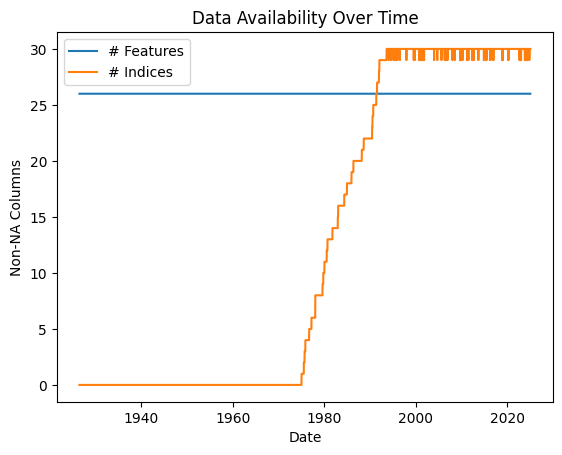

In [4]:
## plot data availability over time
plt.plot((~df_features_raw.isna()).sum(axis=1), label='# Features')
plt.plot((~df_indices_raw.isna()).sum(axis=1), label='# Indices')
plt.xlabel('Date')
plt.ylabel('Non-NA Columns')
plt.title('Data Availability Over Time')
plt.legend()
plt.show()


For the sake of simplicity, cut data at point of first full data availability of Features: 1993-08-02 - 2024-12-31 / 31y and 5m

In [5]:
## cut data to relevant period before running analysis
#df_indices.loc[((~df_indices.isna()).sum(axis=1) == df_indices.shape[1] - 1)]
#cut_date = df_indices.dropna(thresh=df_indices.shape[1] - 1).index[0]
cut_date = df_indices_raw.dropna(thresh=df_indices_raw.shape[1]).index[0]
df_features = df_features_raw.loc[cut_date:]
df_indices = df_indices_raw.loc[cut_date:]
display(df_features)
display(df_indices)


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,...,Feature_17,Feature_18,Feature_19,Feature_20,Feature_21,Feature_22,Feature_23,Feature_24,Feature_25,Feature_26
Date,,,,,,,,,,,,,,,,,,,,,
1993-08-02,0.195414,0.680477,0.476606,0.233545,0.020128,-0.689761,0.275468,-0.995937,-0.005385,0.190145,...,-0.789223,0.256784,-0.121487,0.698411,0.676133,-0.464850,0.297349,0.007257,-0.486917,-0.216796
1993-08-03,0.150761,-0.371939,0.584089,-0.046215,1.033378,-0.530377,0.510667,-0.173845,0.318945,0.358548,...,0.202173,0.828688,0.681172,-1.085725,0.096611,0.678249,0.035687,0.003059,-0.720287,-0.087212
1993-08-04,0.149940,-0.577623,-0.132255,0.604073,0.620716,-0.369269,0.418123,0.237390,0.338582,0.702761,...,-0.319717,0.299270,0.506909,-0.815824,-0.461121,0.040091,-0.360485,0.000530,0.630407,0.623213
1993-08-05,0.422628,0.302836,0.046988,0.568464,-0.175378,-1.119399,-0.235510,-0.459433,0.755395,1.314187,...,-0.440081,-0.600924,0.131727,0.084941,0.994808,-0.040361,0.419962,-0.003864,0.283543,1.239463
1993-08-06,0.530339,0.487798,-0.835210,-0.533059,-1.011130,-0.864007,0.647245,-1.062333,1.379084,1.066676,...,0.263335,0.422344,-0.321520,-0.130820,-0.047656,-0.070561,-1.132429,0.001061,0.051237,0.975052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,1.120932,-1.436859,-0.175410,-0.045046,-0.464391,0.970864,0.000290,0.578114,0.089780,-0.277585,...,0.111907,-0.755242,-0.244757,0.446954,0.442779,-0.693740,-0.456520,-0.006825,-0.282447,0.111905
2024-12-26,0.316729,-0.836088,-0.553824,0.413035,0.499147,0.975832,-0.504313,0.668771,-0.096599,-0.056691,...,0.106591,-0.376037,-1.570717,0.701619,0.604263,-0.203329,-0.826580,-0.010207,-0.775708,0.272806
2024-12-27,0.044196,-0.345337,-0.101089,1.218753,0.686499,0.583500,1.086398,0.436108,-0.741644,0.082207,...,0.231542,-0.211060,-0.424010,-0.495018,-0.631492,-0.776361,-0.967806,-0.010294,1.318508,0.150478


,Food,Beer,Smoke,Games,Books,Hshld,Clths,Hlth,Chems,Txtls,...,Telcm,Servs,BusEq,Paper,Trans,Whlsl,Rtail,Meals,Fin,Other
Date,,,,,,,,,,,,,,,,,,,,,
1993-08-02,-0.642684,0.383427,-1.224334,0.218630,0.198799,0.010001,-0.033246,0.073553,0.073424,0.774519,...,0.315016,0.245076,0.699406,0.230566,0.223141,0.145905,0.470518,0.324912,0.303167,0.587654
1993-08-03,0.164721,-0.244934,-0.855776,0.090658,-0.056085,-0.248241,-0.430844,0.228377,0.166853,0.250041,...,-0.825913,-0.005242,0.369709,0.129716,-0.059807,-0.187234,0.093111,0.115789,0.065748,0.451991
1993-08-04,-0.833300,-1.038643,0.051120,-0.670795,-0.356829,-0.422454,-0.096291,-0.117156,-0.266846,0.628437,...,-0.382097,0.138555,0.617331,-0.310677,0.119056,0.196367,1.028417,-0.168554,0.160884,-0.443456
1993-08-05,-0.564440,0.625753,-1.395137,0.209662,-0.157091,-0.056300,0.228184,-0.954277,-0.153729,-0.643424,...,0.407134,0.336047,0.310191,0.023807,-0.672178,-0.211850,0.231288,-0.113008,-0.033639,0.336719
1993-08-06,0.104902,-0.712048,-0.270956,0.498448,0.231416,1.124936,0.371960,0.197986,-0.072188,-0.007723,...,-0.433709,0.098311,0.566203,0.315936,0.135310,0.155679,0.351263,-0.049768,0.219734,0.093826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,0.796959,0.469047,-0.503095,0.947082,0.597756,0.470192,0.138522,0.362203,0.404982,0.630088,...,0.589826,0.382861,0.755161,0.583556,0.686795,0.441900,1.379881,0.911609,0.866277,0.728905
2024-12-26,-0.127536,-0.258698,0.076338,-0.244977,0.007992,0.338881,0.226344,0.130969,-0.027487,-0.118456,...,0.084804,-0.088973,0.128384,0.164316,0.081112,-0.078422,-0.260679,0.166157,0.219528,0.176504
2024-12-27,0.004378,-0.028861,-0.278826,-0.819008,-0.843820,-0.482413,-0.625715,-0.729164,-0.606214,-0.592691,...,-0.589288,-0.502668,-1.021871,-0.701277,-0.521956,-0.513351,-1.122091,-0.539013,-0.704834,-0.534671


Check for flaws such as NaN Inf or Zeros (as returns are almost certain not 0; features look like differences or returns)

In [6]:
## Short check for obvious data flaws

def check_quality(df):
    """
    Calc NaNs, Infs and Zeros on each column.
    """
    qualityy = pd.DataFrame({
        'NaNs': df.isna().sum(),
        'Infs': df.isin([np.inf, -np.inf]).sum(),
        'Zeros': (df == 0).sum()
    })
    return qualityy.T

# check qualirty 
quality_features = check_quality(df_features)
quality_indices = check_quality(df_indices)
display(quality_features.sort_values(by='Zeros', ascending=False, axis=1))
display(quality_indices.sort_values(by='NaNs', ascending=False, axis=1))
print('Max Number of data "falws" one of the Features')
display(quality_features.max(axis = 1))
print('Max Number of data "falws" one of the Indices')
display(quality_indices.max(axis = 1))

,Feature_24,Feature_1,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_2,...,Feature_17,Feature_14,Feature_18,Feature_19,Feature_21,Feature_20,Feature_22,Feature_23,Feature_25,Feature_26
NaNs,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Infs,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Zeros,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


,Beer,Clths,Meals,Mines,Books,Hshld,Carry,Whlsl,Chems,Trans,...,Food,Paper,Rtail,Txtls,ElcEq,Cnstr,FabPr,Util,BusEq,Fin
NaNs,5,5,5,5,4,4,4,4,4,4,...,2,2,2,1,1,0,0,0,0,0
Infs,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Zeros,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Max Number of data "falws" one of the Features


NaNs     0
Infs     0
Zeros    1
dtype: int64

Max Number of data "falws" one of the Indices


NaNs     5
Infs     0
Zeros    0
dtype: int64

- NaNs in industry index data found 
- All on one date or on single indices, maybe on consective dates?

In [7]:
# NaNs in more than 1 index at same time?! ---> no
df_indices[df_indices.isna().sum(axis=1) > 0]
# Max NaNs per row
print('Sum of NaNs per date:')
display(df_indices.isna().sum(axis=1).sort_values(ascending=False)[:5])

# how many NaNs are consecutive?
max_gaps = df_indices.apply(lambda x: x.isna().astype(int).groupby(x.notna().cumsum()).sum().max())
print('Maximal consecutive NaNs in one Index:')
display(max_gaps.sort_values(ascending=False)[:5])

Sum of NaNs per date:


Date
1995-04-27    1
2008-06-27    1
2005-07-29    1
1997-12-02    1
1994-07-22    1
dtype: int64

Maximal consecutive NaNs in one Index:


Beer     2
Smoke    2
Hshld    2
Games    2
Hlth     2
dtype: int64

In [8]:
# display NaNs
index_na = df_indices[df_indices.isna().sum(axis=1) > 0].index
display(df_indices.loc[index_na])

,Food,Beer,Smoke,Games,Books,Hshld,Clths,Hlth,Chems,Txtls,...,Telcm,Servs,BusEq,Paper,Trans,Whlsl,Rtail,Meals,Fin,Other
Date,,,,,,,,,,,,,,,,,,,,,
1994-01-27,NaN,1.243756,0.441051,-0.122054,0.361558,0.141143,-0.594322,0.366391,0.707245,0.041380,...,1.260537,0.133446,0.349779,0.542886,0.302116,0.238114,1.110532,-0.038774,0.798637,0.777428
1994-07-22,-0.561054,NaN,0.047915,0.147788,0.311611,0.571923,-0.481630,-0.368512,0.077113,-0.906991,...,-0.085283,0.375537,-0.119303,0.253819,0.104055,-0.339452,-0.249025,-2.253243,0.056888,-0.589854
1995-02-02,0.461467,0.457319,0.338364,-0.186936,0.443496,0.685137,0.214313,0.065988,0.209009,0.094832,...,0.010559,0.167711,0.645494,1.078081,-0.157552,NaN,0.485780,1.479647,0.319322,1.126963
1995-02-03,0.934794,1.093704,0.573957,0.891353,0.559724,0.671883,1.132778,0.470049,0.942089,0.722512,...,1.321794,0.582217,0.534211,0.774949,0.518387,NaN,0.861179,0.459706,1.750231,0.492546
1995-04-26,-0.460583,NaN,0.082337,0.155082,-0.980837,0.318616,0.164357,0.147198,0.405789,0.048532,...,0.266681,0.028773,0.873256,0.080401,0.179170,-0.091907,0.145549,0.022595,0.128159,-0.246734
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-02-15,0.850583,0.246841,-0.353157,0.868267,1.153668,0.601769,0.402110,0.814714,1.703600,0.771111,...,0.566259,-0.097851,-0.205905,1.067157,0.722969,0.847079,0.051147,1.069444,1.287044,0.621891
2024-05-01,-0.752184,-0.334532,0.645014,0.114108,0.239605,-0.876458,-1.149527,0.494338,0.217751,0.157947,...,0.317264,0.231354,-1.503849,0.203067,-0.099213,-0.913024,0.543681,-2.186411,0.155253,0.049860
2024-05-02,1.023909,0.193839,0.862402,1.203437,1.496581,0.646997,1.160769,-0.122378,0.768955,0.947031,...,0.543065,0.335973,1.428580,0.230493,1.120177,0.348498,1.916127,0.149200,0.426081,0.606643


- NaNs appear random and are uncritical and likley due to data flaw in the relevant segment 
    - i.e. take market return to to fill gap for simplicity (dropping NaNs in final data could be done as well ~ only loss of 77 data lines)

    - define market return as equally weighted avg over industry returns

In [9]:
# Fill NaNs with market return
df_market = pd.DataFrame(df_indices.mean(axis=1))
df_market.columns = ['ret_t']
df_market['ret_t+1'] = df_market.shift(-1)
df_indices = df_indices.T.fillna(df_market['ret_t']).T
display(df_indices.loc[index_na])

,Food,Beer,Smoke,Games,Books,Hshld,Clths,Hlth,Chems,Txtls,...,Telcm,Servs,BusEq,Paper,Trans,Whlsl,Rtail,Meals,Fin,Other
Date,,,,,,,,,,,,,,,,,,,,,
1994-01-27,0.335835,1.243756,0.441051,-0.122054,0.361558,0.141143,-0.594322,0.366391,0.707245,0.041380,...,1.260537,0.133446,0.349779,0.542886,0.302116,0.238114,1.110532,-0.038774,0.798637,0.777428
1994-07-22,-0.561054,-0.140045,0.047915,0.147788,0.311611,0.571923,-0.481630,-0.368512,0.077113,-0.906991,...,-0.085283,0.375537,-0.119303,0.253819,0.104055,-0.339452,-0.249025,-2.253243,0.056888,-0.589854
1995-02-02,0.461467,0.457319,0.338364,-0.186936,0.443496,0.685137,0.214313,0.065988,0.209009,0.094832,...,0.010559,0.167711,0.645494,1.078081,-0.157552,0.299727,0.485780,1.479647,0.319322,1.126963
1995-02-03,0.934794,1.093704,0.573957,0.891353,0.559724,0.671883,1.132778,0.470049,0.942089,0.722512,...,1.321794,0.582217,0.534211,0.774949,0.518387,0.723880,0.861179,0.459706,1.750231,0.492546
1995-04-26,-0.460583,-0.092909,0.082337,0.155082,-0.980837,0.318616,0.164357,0.147198,0.405789,0.048532,...,0.266681,0.028773,0.873256,0.080401,0.179170,-0.091907,0.145549,0.022595,0.128159,-0.246734
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-02-15,0.850583,0.246841,-0.353157,0.868267,1.153668,0.601769,0.402110,0.814714,1.703600,0.771111,...,0.566259,-0.097851,-0.205905,1.067157,0.722969,0.847079,0.051147,1.069444,1.287044,0.621891
2024-05-01,-0.752184,-0.334532,0.645014,0.114108,0.239605,-0.876458,-1.149527,0.494338,0.217751,0.157947,...,0.317264,0.231354,-1.503849,0.203067,-0.099213,-0.913024,0.543681,-2.186411,0.155253,0.049860
2024-05-02,1.023909,0.193839,0.862402,1.203437,1.496581,0.646997,1.160769,-0.122378,0.768955,0.947031,...,0.543065,0.335973,1.428580,0.230493,1.120177,0.348498,1.916127,0.149200,0.426081,0.606643


Check for data gaps on dates

In [10]:
# This calculates the difference between each date and the one before it
gaps = df_features.index.to_series().diff()

# To see the largest gaps:
print('Most date gaps, missing vals before - 2001-9-17 related to "9/11"')
display(gaps.sort_values(ascending=False).head(10).to_frame().T)

Most date gaps, missing vals before - 2001-9-17 related to "9/11"


Date,2001-09-17,2012-10-31,2007-01-03,2007-02-20,2010-09-07,1995-05-30,1994-05-31,2000-02-22,2018-09-04,2023-02-21
Date,7 days,5 days,5 days,4 days,4 days,4 days,4 days,4 days,4 days,4 days


Section Results:
 - Data was cut to full avaialble level - generous cutting for simplicity (NaN handling or avoidance of industry bias in historic data)
 - NaNs in cutted set were found uncritical and filled with avg market returns

## Statistical Overview

- describe data and add skew, kurt, mean p.a., std p.a. , SR or t-stat for mean vs 0 of features

In [11]:
# Basic descriptive statistics (mean, std, min, max, quartiles)
desc_features = df_features.describe()
desc_indices = df_indices.describe()

trading_days_per_year = 252

print("Summary Statistics")
#display(desc_features.T)
#display(desc_indices.T)

# Calculate and display skewness and kurtosis in one table for indices
skew_kurt_indices = pd.DataFrame({
    'skew': df_indices.skew(),
    'kurtosis': df_indices.kurtosis(), # pandas kurtosis is excess kurtosis
    'ret_pa': df_indices.mean() * trading_days_per_year,
    'vol_pa': df_indices.std() * np.sqrt(trading_days_per_year),
    'SharpeRatio': df_indices.mean() / df_indices.std() * np.sqrt(trading_days_per_year) # w/o risk free rate
})
print("Indices desc + further stats:")
stats_indices = pd.concat([desc_indices.T, skew_kurt_indices], axis=1)
display(stats_indices[:])# .style.background_gradient(cmap='RdYlGn', axis=0))

# Calculate and display skewness and kurtosis in one table for features
skew_kurt_features = pd.DataFrame({
    'skew': df_features.skew(),
    'kurtosis': df_features.kurtosis(),
    'mean_pa': df_features.mean() * trading_days_per_year,
    'std_pa': df_features.std() * np.sqrt(trading_days_per_year),
    't_stat of mean': df_features.mean() / df_features.std() * np.sqrt(len(df_features)) #-test 
})
print("Features desc + further stats:")
stats_features = pd.concat([desc_features.T, skew_kurt_features], axis=1)
display(stats_features[:]) #.style.background_gradient(cmap='RdYlGn', axis=0))


Summary Statistics
Indices desc + further stats:


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,ret_pa,vol_pa,SharpeRatio
Food,7911.0,0.001161,1.070969,-9.973504,-0.531968,0.026068,0.567700,10.723860,-0.084445,8.744511,0.292600,17.001103,0.017211
Beer,7911.0,-0.004655,0.828218,-8.366054,-0.409373,-0.006933,0.403870,7.423077,-0.082709,9.551477,-1.173126,13.147559,-0.089228
Smoke,7911.0,0.008543,1.268407,-11.393414,-0.571730,0.016601,0.608329,12.525259,-0.114583,10.123146,2.152760,20.135330,0.106915
Games,7911.0,0.003957,1.011770,-9.036713,-0.464048,0.015339,0.495720,7.271452,-0.292662,6.428119,0.997284,16.061356,0.062092
Books,7911.0,-0.003511,1.048455,-9.428881,-0.488313,0.010561,0.496278,13.865770,0.130105,11.052047,-0.884871,16.643710,-0.053166
Hshld,7911.0,0.001179,0.945707,-15.698376,-0.454937,0.008346,0.463851,8.936824,-0.584494,16.555382,0.297196,15.012626,0.019796
Clths,7911.0,0.007548,1.290398,-11.681136,-0.632751,0.021683,0.675175,11.500839,-0.086936,6.638956,1.902137,20.484440,0.092858
Hlth,7911.0,0.002853,1.044427,-8.898700,-0.511065,0.021202,0.558878,10.196650,-0.175215,5.991727,0.718907,16.579765,0.043361
Chems,7911.0,0.000233,1.135264,-10.163653,-0.548404,0.015653,0.580395,10.224719,-0.258852,7.302942,0.058623,18.021762,0.003253
Txtls,7911.0,-0.004566,1.345800,-16.662262,-0.608581,-0.003151,0.584265,14.104178,-0.061956,14.265805,-1.150729,21.363913,-0.053863


Features desc + further stats:


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,mean_pa,std_pa,t_stat of mean
Feature_1,7911.0,-0.003315,0.686995,-1.662845,-0.516031,-0.004777,0.504166,1.726352,0.014592,-0.772399,-0.835411,10.905709,-0.429202
Feature_2,7911.0,-0.000811,0.670379,-3.498828,-0.442510,0.009751,0.451090,2.439176,-0.177146,0.494045,-0.204444,10.641942,-0.107639
Feature_3,7911.0,-0.006169,0.614609,-2.997863,-0.411995,0.005292,0.403116,2.269775,-0.072434,0.246015,-1.554699,9.756619,-0.892817
Feature_4,7911.0,0.008906,0.631594,-4.151677,-0.407073,0.021163,0.421226,2.724555,-0.164851,0.794809,2.244387,10.026246,1.254223
Feature_5,7911.0,0.009901,0.652235,-3.217916,-0.424110,0.015344,0.442094,2.318813,-0.112833,0.209109,2.495058,10.353908,1.350180
Feature_6,7911.0,-0.004283,0.685613,-1.614644,-0.514320,-0.007879,0.512526,1.813746,0.005660,-0.796619,-1.079223,10.883762,-0.555581
Feature_7,7911.0,0.018485,0.596495,-2.378459,-0.372794,0.022124,0.418619,2.322746,-0.029490,0.138683,4.658335,9.469067,2.756379
Feature_8,7911.0,0.008310,0.618996,-2.876707,-0.403200,0.015283,0.425940,2.337044,-0.075976,0.228928,2.094033,9.826261,1.194017
Feature_9,7911.0,0.003897,0.633235,-3.231851,-0.411343,0.004543,0.423587,2.183132,-0.071632,0.261847,0.982000,10.052288,0.547346
Feature_10,7911.0,0.000600,0.685638,-1.668439,-0.512304,0.003992,0.521142,1.694841,-0.016348,-0.794529,0.151102,10.884162,0.077784


In [60]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests

# Basic descriptive statistics (mean, std, min, max, quartiles)
desc_features = df_features.describe()
desc_indices = df_indices.describe()

trading_days_per_year = 252

print("Summary Statistics")
#display(desc_features.T)
#display(desc_indices.T)

# --- 1. INDICES STATS ---
# Calculate and display skewness and kurtosis in one table for indices
skew_kurt_indices = pd.DataFrame({
    'skew': df_indices.skew(),
    'kurtosis': df_indices.kurtosis(), # pandas kurtosis is excess kurtosis
    'ret_pa': df_indices.mean() * trading_days_per_year,
    'vol_pa': df_indices.std() * np.sqrt(trading_days_per_year),
    'SharpeRatio': (df_indices.mean() / df_indices.std()) * np.sqrt(trading_days_per_year) # w/o risk free rate
})
print("Indices desc + further stats:")
stats_indices = pd.concat([desc_indices.T, skew_kurt_indices], axis=1)
display(stats_indices)


# --- 2. FEATURES STATS (Mit Multiple Testing Correction) ---
N = len(df_features)

# T-Statistik berechnen
t_stats = df_features.mean() / df_features.std() * np.sqrt(N)

# Rohe P-Werte berechnen (zweiseitiger T-Test auf Mittelwert = 0)
p_values_raw = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=N-1))

# P-Werte adjustieren (Benjamini-Hochberg FDR)
reject_h0, pvals_corrected, _, _ = multipletests(p_values_raw, alpha=0.05, method='fdr_bh')

# Calculate and display stats in one table for features
skew_kurt_features = pd.DataFrame({
    'skew': df_features.skew(),
    'kurtosis': df_features.kurtosis(),
    'mean_pa': df_features.mean() * trading_days_per_year,
    'std_pa': df_features.std() * np.sqrt(trading_days_per_year),
    't_stat of mean': t_stats,
    'p_value_raw': p_values_raw,
    'p_value_adj_FDR': pvals_corrected
    #'Significant (5%)': reject_h0
})

print("\nFeatures desc + further stats (Adjusted for Multiple Testing):")
stats_features = pd.concat([desc_features.T, skew_kurt_features], axis=1)

# 1. Definieren, wie jede Spalte aussehen soll
format_mapping = {
    'mean_pa': '{:.4f}',
    'std_pa': '{:.4f}',
    't_stat of mean': '{:.2f}',  # 2 Nachkommastellen
    
    # Lambda-Funktion: Wenn sehr klein, dann "< 0.001", sonst 4 Nachkommastellen
    'p_value_raw': lambda x: '< 0.001' if x < 0.001 else f'{x:.4f}',
    'p_value_adj_FDR': lambda x: '< 0.001' if x < 0.001 else f'{x:.4f}'
}

# 2. Hilfsfunktion für die grüne Farbe
def highlight_sig(val):
    # Alles unter 5% wird grün markiert
    if isinstance(val, (int, float)) and val < 0.05:
        return 'background-color: #d4edda; color: #155724;' # dezentes Grün
    return ''

# 3. Style anwenden und anzeigen
styled_table = (
    stats_features.sort_values(by = 'p_value_raw').style
    .format(format_mapping) # Zahlen formatieren
    # .map() in neuen Pandas Versionen, .applymap() in älteren. 
    # Wenn .map() einen Fehler wirft, ersetze es durch .applymap()
    .map(highlight_sig, subset=['p_value_adj_FDR']) 
)

display(styled_table)#.sort_values(by = 'p_value_raw'))
#display(stats_features.sort_values(by = 'p_value_raw'))

Summary Statistics
Indices desc + further stats:


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,ret_pa,vol_pa,SharpeRatio
Food,7911.0,0.001161,1.070969,-9.973504,-0.531968,0.026068,0.567700,10.723860,-0.084445,8.744511,0.292600,17.001103,0.017211
Beer,7911.0,-0.004655,0.828218,-8.366054,-0.409373,-0.006933,0.403870,7.423077,-0.082709,9.551477,-1.173126,13.147559,-0.089228
Smoke,7911.0,0.008543,1.268407,-11.393414,-0.571730,0.016601,0.608329,12.525259,-0.114583,10.123146,2.152760,20.135330,0.106915
Games,7911.0,0.003957,1.011770,-9.036713,-0.464048,0.015339,0.495720,7.271452,-0.292662,6.428119,0.997284,16.061356,0.062092
Books,7911.0,-0.003511,1.048455,-9.428881,-0.488313,0.010561,0.496278,13.865770,0.130105,11.052047,-0.884871,16.643710,-0.053166
Hshld,7911.0,0.001179,0.945707,-15.698376,-0.454937,0.008346,0.463851,8.936824,-0.584494,16.555382,0.297196,15.012626,0.019796
Clths,7911.0,0.007548,1.290398,-11.681136,-0.632751,0.021683,0.675175,11.500839,-0.086936,6.638956,1.902137,20.484440,0.092858
Hlth,7911.0,0.002853,1.044427,-8.898700,-0.511065,0.021202,0.558878,10.196650,-0.175215,5.991727,0.718907,16.579765,0.043361
Chems,7911.0,0.000233,1.135264,-10.163653,-0.548404,0.015653,0.580395,10.224719,-0.258852,7.302942,0.058623,18.021762,0.003253
Txtls,7911.0,-0.004566,1.345800,-16.662262,-0.608581,-0.003151,0.584265,14.104178,-0.061956,14.265805,-1.150729,21.363913,-0.053863



Features desc + further stats (Adjusted for Multiple Testing):


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,mean_pa,std_pa,t_stat of mean,p_value_raw,p_value_adj_FDR
Feature_13,7911.000000,0.053947,0.517845,-1.959947,-0.285838,0.045277,0.394937,2.049482,0.020376,0.080129,13.5945,8.2205,9.27,< 0.001,< 0.001
Feature_14,7911.000000,0.049203,0.220672,-2.686859,-0.032939,0.050667,0.132727,2.211768,0.128820,14.777899,12.3991,3.5031,19.83,< 0.001,< 0.001
Feature_22,7911.000000,0.138794,0.804726,-3.098933,-0.395769,0.131586,0.667218,2.941429,0.009841,0.000567,34.9762,12.7746,15.34,< 0.001,< 0.001
Feature_24,7911.000000,0.000971,0.011115,-0.038295,-0.006536,0.000972,0.008522,0.043187,-0.024736,-0.067889,0.2446,0.1764,7.77,< 0.001,< 0.001
Feature_21,7911.000000,0.033870,0.523214,-1.728768,-0.326305,0.038426,0.385612,1.957903,0.023682,-0.106997,8.5353,8.3058,5.76,< 0.001,< 0.001
Feature_19,7911.000000,-0.023479,0.720403,-5.516321,-0.492231,-0.019039,0.451892,3.430297,-0.131483,0.944986,-5.9167,11.4360,-2.90,0.0038,0.0163
Feature_7,7911.000000,0.018485,0.596495,-2.378459,-0.372794,0.022124,0.418619,2.322746,-0.029490,0.138683,4.6583,9.4691,2.76,0.0059,0.0218
Feature_15,7911.000000,0.010114,0.646208,-3.224586,-0.418046,0.019502,0.447372,2.146725,-0.126552,0.252363,2.5486,10.2582,1.39,0.1640,0.4895
Feature_5,7911.000000,0.009901,0.652235,-3.217916,-0.424110,0.015344,0.442094,2.318813,-0.112833,0.209109,2.4951,10.3539,1.35,0.1770,0.4895
Feature_17,7911.000000,0.009582,0.677244,-4.520851,-0.431707,0.007359,0.453350,2.620920,-0.107340,0.509989,2.4146,10.7509,1.26,0.2083,0.4895


identifiy high mean data

In [12]:
stats_features_mean = stats_features.loc[:,'t_stat of mean'].sort_values(ascending=False)
stats_features_mean = stats_features_mean[stats_features_mean.abs() > 2]
print(f'Features that show signifcant mean:')
display(stats_features_mean.to_frame())

Features that show signifcant mean:


,t_stat of mean
Feature_14,19.831551
Feature_22,15.340510
Feature_13,9.265721
Feature_24,7.766862
Feature_21,5.757786
Feature_7,2.756379
Feature_19,-2.898832


Interpretation:
- IMPORTANT Index Returns look way too low for real data... ~ historic mean somehwere between 8-12 % p.a.?

- Feature 14, 22, 13, 24, 21, 7, 19 have significant mean and might create spurious correlation with market indicies --> will be fixed with standardization
- Feature 24 very low scale / in contrast 13, 14, 22 high scale...
- Feature 14 shows extrem tails --> shocks or vol clusters 

--> standardization for these features surely needed

Look at histogram or box plot of standardized features to visually see skew or tails

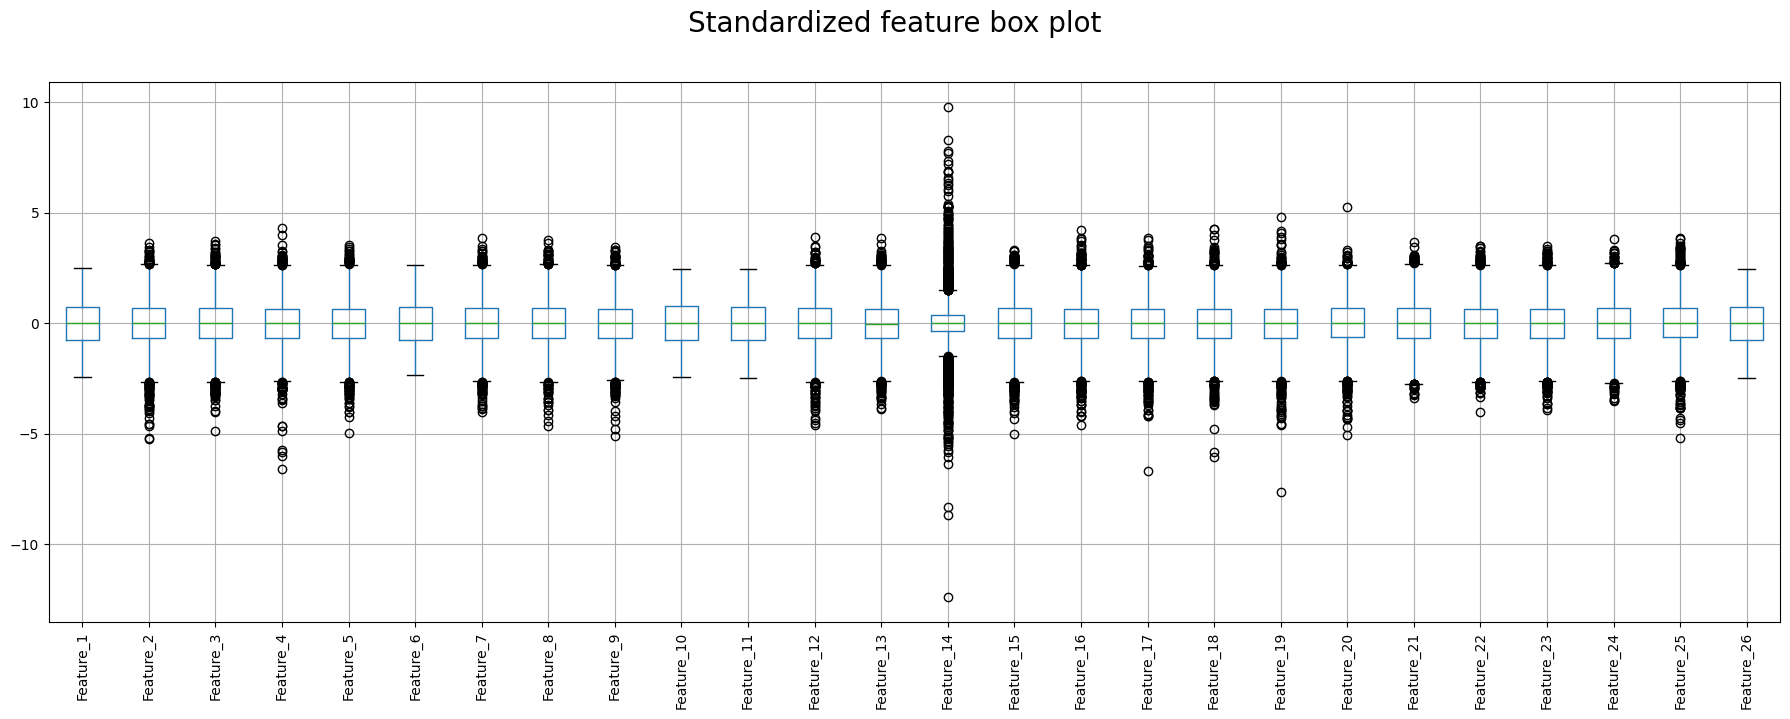

In [13]:
# Histograms for all 26 feature columns; layout (7, 4) fits 26 panels
df_features_z_allsample = (df_features - df_features.mean()) / df_features.std()
#df_features_z_allsample.hist(bins=30, figsize=(18, 22), layout=(7, 4), color='skyblue', edgecolor='black')
#plt.suptitle('Standardized feature histograms', fontsize=20, y=1.02)
plt.figure(figsize=(18, 7))
df_features_z_allsample.boxplot(rot=90)
plt.suptitle('Standardized feature box plot', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

Check Correlations

Correlation of index series are very high
- no real finding, Smoke, Mines, Coal seem to diversify well
- --> no surprise here
- consider model training on relative outperformance instead

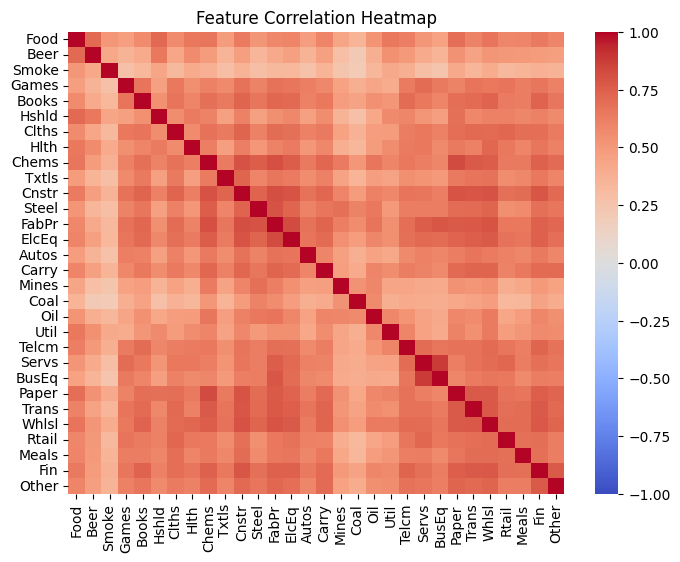

High Correlation Pairs (|corr| > 0.8):
Chems - Cnstr: 0.8000
Chems - FabPr: 0.8058
Chems - Paper: 0.8268
Cnstr - FabPr: 0.8171
Cnstr - Whlsl: 0.8030
FabPr - ElcEq: 0.8224
Servs - BusEq: 0.8793


In [14]:
# Calculate correlation matrix
corr_matrix = df_indices.corr()

# 1. Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap')
plt.show()

# 2. List High Correlation Pairs
print("High Correlation Pairs (|corr| > 0.8):")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            pair_info = f"{corr_matrix.columns[i]} - {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.4f}"
            high_corr_pairs.append(pair_info)

            print(pair_info)

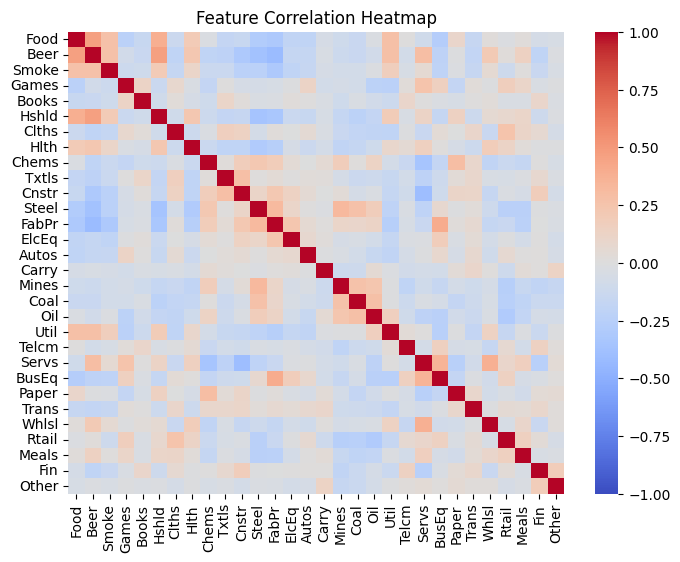

High Correlation Pairs (|corr| > 0.5):


In [15]:
# Calculate correlation matrix
corr_matrix = df_indices.sub(df_market['ret_t'], axis=0).corr()

# 1. Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap')
plt.show()

# 2. List High Correlation Pairs
print("High Correlation Pairs (|corr| > 0.5):")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.5:
            pair_info = f"{corr_matrix.columns[i]} - {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.4f}"
            high_corr_pairs.append(pair_info)
            print(pair_info)

Corr of Features

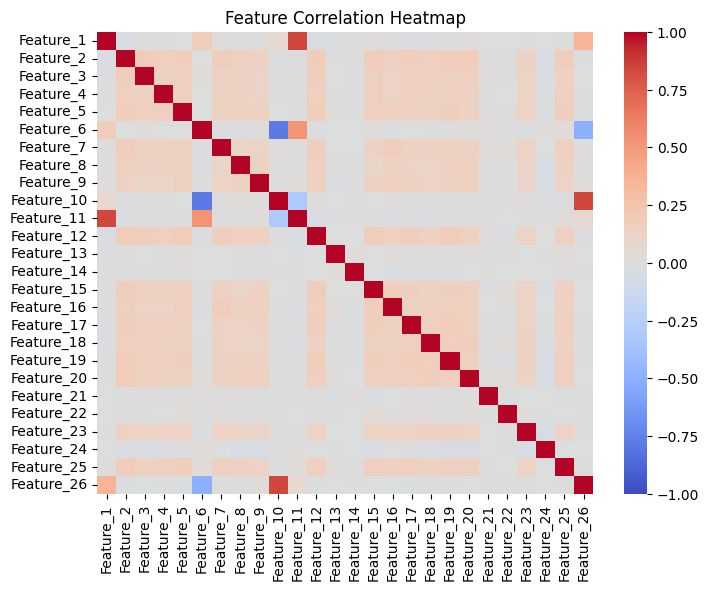

High Correlation Pairs (|corr| > 0.3):
Feature_1 - Feature_11: 0.8369
Feature_1 - Feature_26: 0.3546
Feature_6 - Feature_10: -0.7864
Feature_6 - Feature_11: 0.5276
Feature_6 - Feature_26: -0.5002
Feature_10 - Feature_11: -0.3072
Feature_10 - Feature_26: 0.8424


In [16]:
# Calculate correlation matrix
corr_matrix = df_features.corr()

# 1. Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap')
plt.show()

# 2. List High Correlation Pairs
print("High Correlation Pairs (|corr| > 0.3):")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.3:
            pair_info = f"{corr_matrix.columns[i]} - {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.4f}"
            high_corr_pairs.append(pair_info)
            print(pair_info)

Interpretation of Feature Correlations
- Some Corr Pairs seem fairly high - could think about combining Features 1 and 11 / 6 with 10 / 10 with Feature 26; or dismiss  on of the pairs?
- In general, Input Features seem well behaving for ML models

Check Dimension reduction of standarfized Features to check if data could be reduced before feeding to models

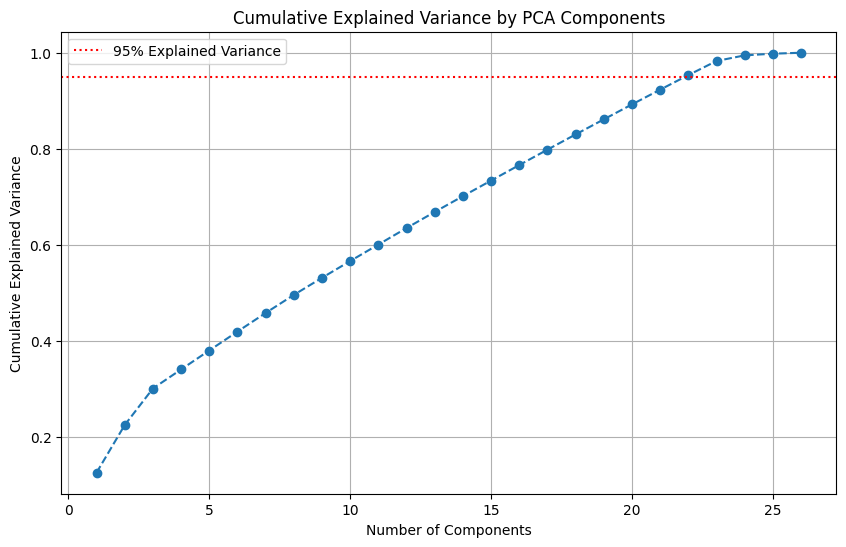

Explained Variance Ratio (First 5 components): [0.12526747 0.09922442 0.07610527 0.03970796 0.03950788]


In [17]:
# # Standardize the data (PCA is sensitive to scale)
# scaler = StandardScaler()
# df_scaled = scaler.fit_transform(df_features)


# Fit PCA
pca = PCA()
pca.fit(df_features_z_allsample)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

# Plot Cumulative Explained Variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.95, color='r', linestyle=':', label='95% Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

print("Explained Variance Ratio (First 5 components):", explained_variance[:5])

Interpretation:
- No real dimensionality reduction possible (data is high dimensional)...
- Multicollinearity likly no issue in regression analysis

Section Take away:
- data seems well behaved
- Return of industry index is odd? --> did not investigate further from here on
- Features are mostly low corr, high dimensional, some show signifcant mean

## Stationarity - Trend analysis

- Visual analysis

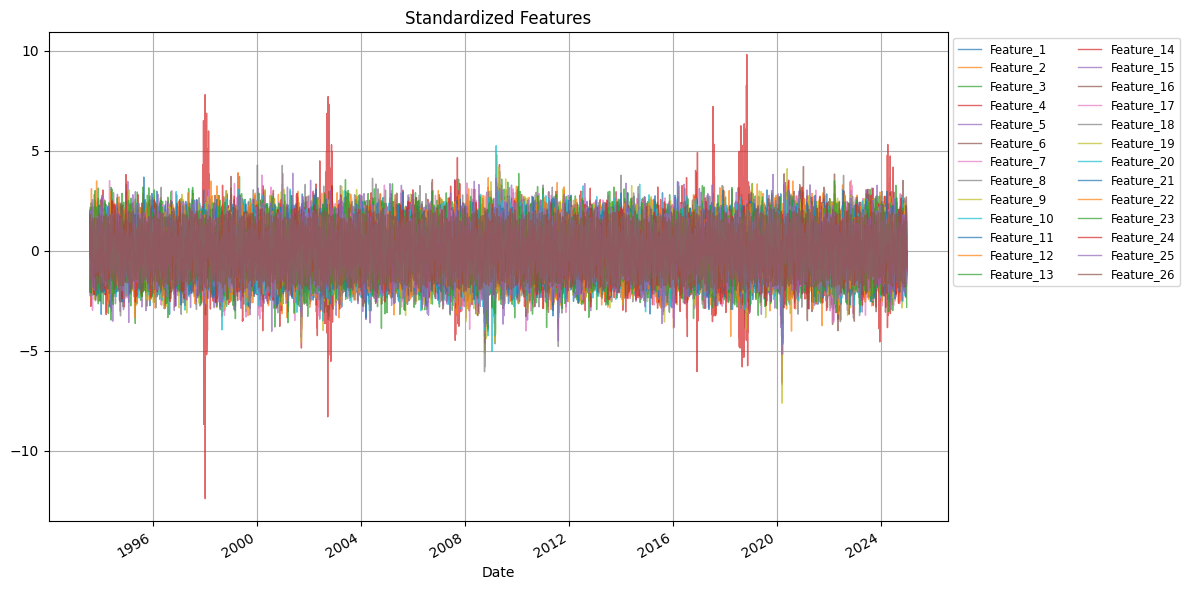

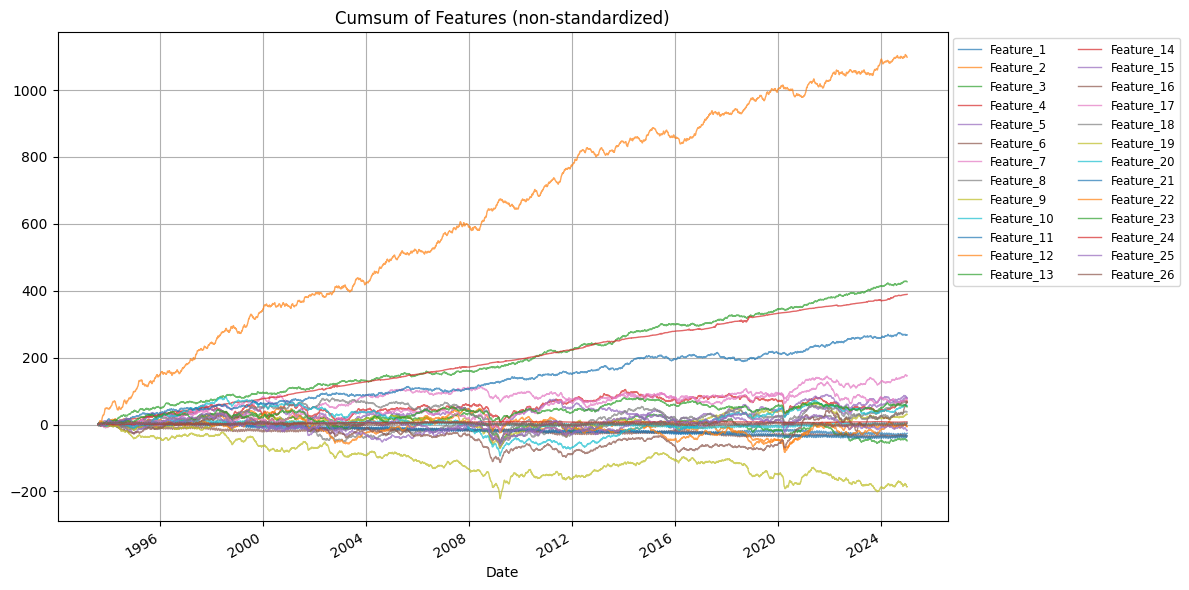

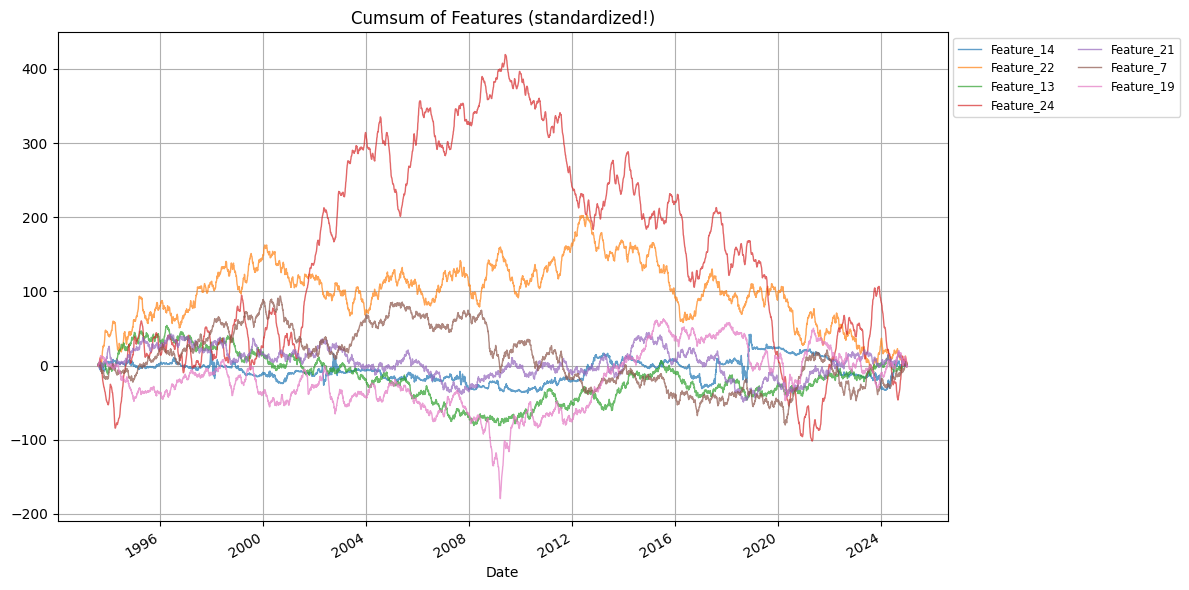

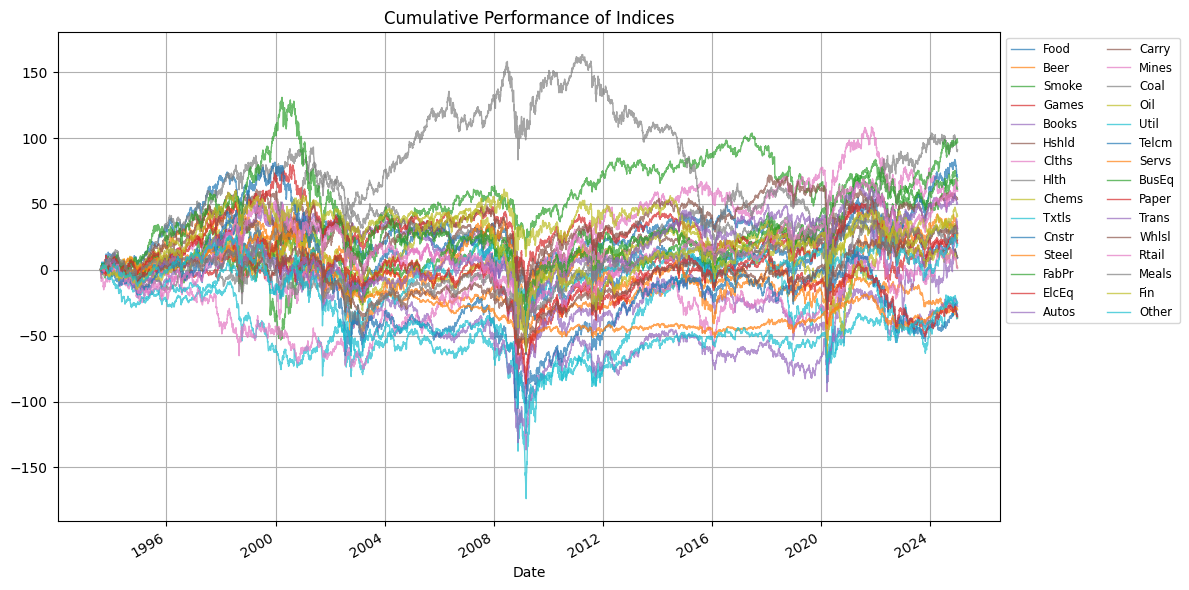

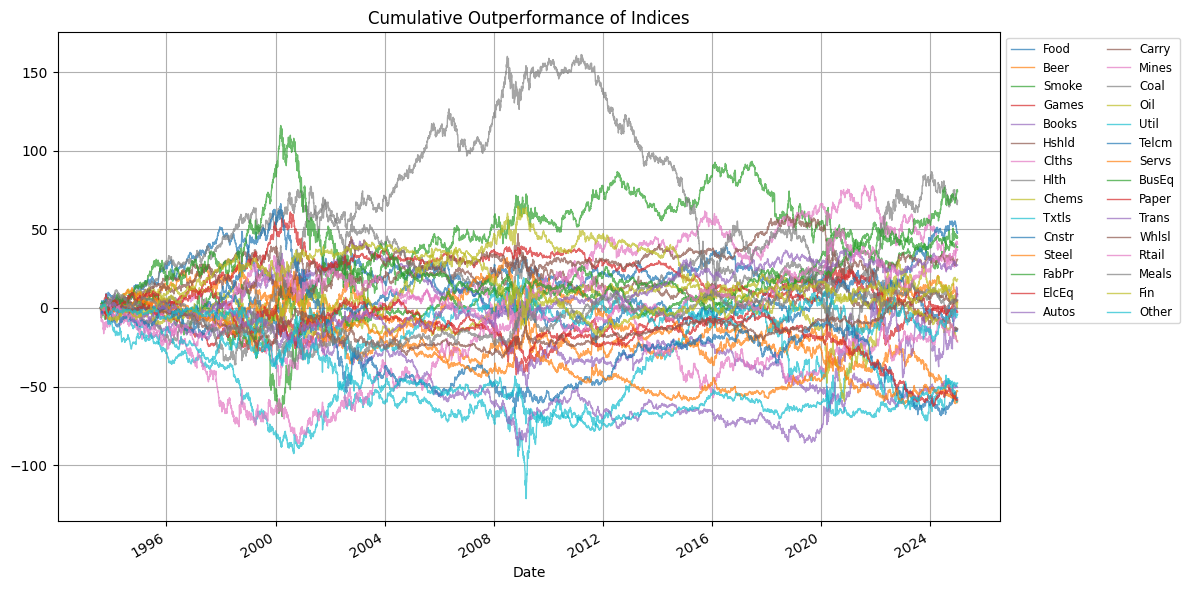

In [18]:
# Calculate outperformance
df_indices_out = df_indices.sub(df_market['ret_t'], axis=0)

# Helper function to avoid repeating layout code
def plot_data(df, title):
    ax = df.plot(figsize=(12, 6), alpha=0.7, lw=1, grid=True, title=title)
    ax.legend(bbox_to_anchor=(1, 1), loc='upper left', ncol=2, fontsize='small')
    plt.tight_layout()
    plt.show()

# Run for both
plot_data(df_features_z_allsample, 'Standardized Features')
plot_data(df_features.cumsum(), 'Cumsum of Features (non-standardized)')
plot_data((df_features_z_allsample.loc[:,stats_features_mean.index]).cumsum(), 'Cumsum of Features (standardized!)')
plot_data(df_indices.cumsum(), 'Cumulative Performance of Indices')
plot_data(df_indices_out.cumsum(), 'Cumulative Outperformance of Indices')
#plot_data(df_indices_out['2008':'2009'].cumsum(), 'Cumulative Outperformance GFC')


- Cumulative std-Features show that Mean of Feature 24 is not constant over time (Financial crisis 2008) --> this could reverse feature effect from training to valuation data set...

Does ADF-test reveal any non-stationary behaviour

In [19]:
# Select features to test (testing all takes time, here we test a subset of distinct features)
# You can change this to df.columns to test all
features_to_test = stats_features_mean.index # ['Feature_19', 'Feature_3', 'Feature_14', 'Feature_22', 'Feature_13'] # ['Feature_1', 'Feature_2', 'Feature_14', 'Feature_22', 'Feature_24']

print("Augmented Dickey-Fuller (ADF) Test Results:")
print("-" * 50)
print(f"{'Feature':<15} | {'p-value':<10} | {'Stationary?'}")
print("-" * 50)

for col in features_to_test: # df_features.columns: # features_to_test:
    # Drop NA just in case (though data is clean)
    result = adfuller(df_features[col].dropna())
    p_value = result[1]
    is_stationary = p_value < 0.05
    print(f"{col:<15} | {p_value:.4f}     | {'Yes' if is_stationary else 'No'}")

Augmented Dickey-Fuller (ADF) Test Results:
--------------------------------------------------
Feature         | p-value    | Stationary?
--------------------------------------------------
Feature_14      | 0.0000     | Yes
Feature_22      | 0.0000     | Yes
Feature_13      | 0.0000     | Yes
Feature_24      | 0.0000     | Yes
Feature_21      | 0.0000     | Yes
Feature_7       | 0.0000     | Yes
Feature_19      | 0.0000     | Yes


--> ADF test indentifies mean reversion --> level stationary

--- Top 5 Features by Trend Significance (T-Stat) ---


,slope,t_stat,p_value
Feature_24,-0.000029,-5.921092,3.331697e-09
Feature_22,-0.000019,-3.854145,1.170540e-04
Feature_16,0.000018,3.671436,2.427806e-04
Feature_8,0.000011,2.332389,1.970522e-02
Feature_15,0.000010,2.011203,4.433789e-02
Feature_3,-0.000008,-1.710528,8.720751e-02
Feature_4,-0.000005,-1.036938,2.997964e-01
Feature_20,0.000004,0.857751,3.910561e-01
Feature_23,-0.000004,-0.850980,3.948060e-01
Feature_19,0.000004,0.777073,4.371392e-01


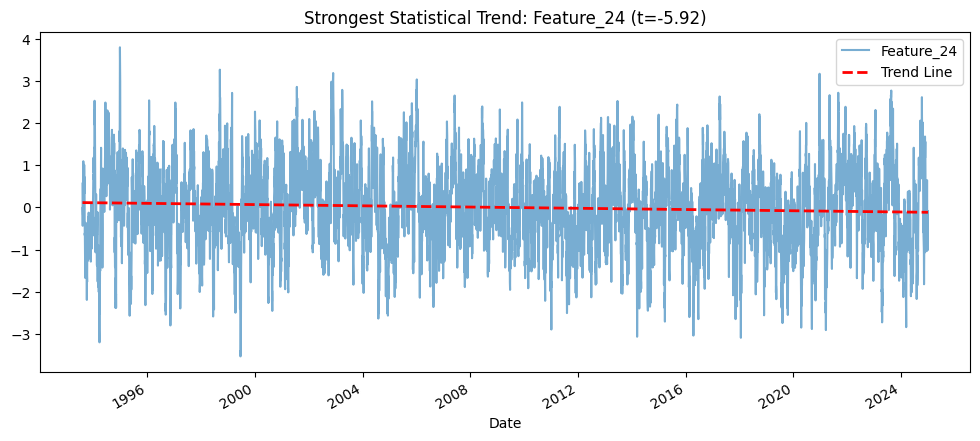

In [20]:
# 2. Calculate Regression Stats (List Comprehension)
# We map linregress over all columns against a time index (0..N)
x = np.arange(len(df_features_z_allsample))
stats_list = [linregress(x, df_features_z_allsample[col]) for col in df_features_z_allsample.columns]

# 3. Create Results DataFrame
results = pd.DataFrame(stats_list, index=df_features_z_allsample.columns)
results.columns = ['slope', 'intercept', 'r_value', 'p_value', 'stderr']

# Calculate T-Statistic manually (Slope / Standard Error)
results['t_stat'] = results['slope'] / results['stderr']

# 4. Display Top Trends (Sorted by absolute T-Statistic)
print("--- Top 5 Features by Trend Significance (T-Stat) ---")
display_cols = ['slope', 't_stat', 'p_value']
display(results[display_cols].reindex(results['t_stat'].abs().sort_values(ascending=False).index).head(10))

# 5. Plot the Strongest Trend
best_feat = results['t_stat'].abs().idxmax()
slope, intercept, t_val = results.loc[best_feat, ['slope', 'intercept', 't_stat']]

ax = df_features_z_allsample[best_feat].plot(figsize=(12, 5), title=f"Strongest Statistical Trend: {best_feat} (t={t_val:.2f})", alpha=0.6)
# Overlay Trend Line
trend_series = pd.Series(slope * x + intercept, index=df_features_z_allsample.index)
trend_series.plot(ax=ax, color='red', style='--', label='Trend Line', linewidth=2)

plt.legend()
plt.show()

- Regression on trend variable shows t_stat significance... still very low and almost stationary

Section Results:
- Mean of Feature 24 changes after 2008
- will apply rolling z-scores on Features anyways for scaling and consistence
- Hence, no relevant adverse impact to be expected 

# Data Preparation

## Feature Extension

Extend macro Features with technical index specific data:
- 3d rolling return as sum
- 7d rolling return as sum
- 21d rolling return as sum
- 21d volatility (std of rets)
- 14d rsi

- 2 data sets: df_indizes and df_indizes_out which are relative returns to market mean

RSI Function

In [21]:
# rsi helper function
def calculate_rsi_simple(returns, window=14):
    """
    RSI based on: avg_up / (avg_up + avg_down).
    Input: Returns!
    Output: RSI as float
    """
    # Get pos and neg returns
    up = returns.clip(lower=0)
    down = -returns.clip(upper=0)

    # moving avg
    avg_up = up.rolling(window=window).mean()
    avg_down = down.rolling(window=window).mean()

    # Calc RSI
    rsi = avg_up / (avg_up + avg_down + 1e-10)
    
    return rsi

- Calculate technical features

In [22]:
## All based on returns
# Calc xday returns for indices
df_indices_3dret = df_indices.rolling(window=3).sum()
df_indices_7dret = df_indices.rolling(window=7).sum()
df_indices_21dret = df_indices.rolling(window=21).sum()
# get historic vol
df_indices_21dvol = df_indices.rolling(window=21).std() * np.sqrt(252)
df_indices_14drsi = calculate_rsi_simple(df_indices)

## All based on outperformance
df_indices_out_3dret = df_indices_out.rolling(window=3).sum()
df_indices_out_7dret = df_indices_out.rolling(window=7).sum()
df_indices_out_21dret = df_indices_out.rolling(window=21).sum()
df_indices_out_21dvol = df_indices_out.rolling(window=21).std() * np.sqrt(252)
df_indices_out_14drsi = calculate_rsi_simple(df_indices_out)


- Concat Features to existing data set

In [23]:
# Pack DFs to dict
frames = {
    '1dret': df_indices,
    '3dret': df_indices_3dret,
    '7dret': df_indices_7dret,
    '21dret': df_indices_21dret,
    'vol': df_indices_21dvol,
    'rsi': df_indices_14drsi
}
# Concatenate along keys
df_indices_all = pd.concat(frames, axis=1)
# Swap keys with names
df_indices_all = df_indices_all.swaplevel(0, 1, axis=1).sort_index(axis=1)
df_indices_all.columns.names = ['Industry', 'Feature']
#df_indices_all.head()

# Concatenate with outperform features
frames_outperform = {
    '1dret': df_indices_out,
    '3dret': df_indices_out_3dret,
    '7dret': df_indices_out_7dret,
    '21dret': df_indices_out_21dret,
    'vol': df_indices_out_21dvol,
    'rsi': df_indices_out_14drsi
}
df_indices_out_all = pd.concat(frames_outperform, axis=1)
df_indices_out_all = df_indices_out_all.swaplevel(0, 1, axis=1).sort_index(axis=1)
df_indices_out_all.columns.names = ['Industry', 'Feature']
display(df_indices_out_all)



Industry       Autos                                                      \
Feature        1dret     21dret     3dret     7dret       rsi        vol   
Date                                                                       
1993-08-02  0.879288        NaN       NaN       NaN       NaN        NaN   
1993-08-03 -0.209408        NaN       NaN       NaN       NaN        NaN   
1993-08-04 -0.315835        NaN  0.354046       NaN       NaN        NaN   
1993-08-05 -0.396921        NaN -0.922163       NaN       NaN        NaN   
1993-08-06 -0.893587        NaN -1.606342       NaN       NaN        NaN   
...              ...        ...       ...       ...       ...        ...   
2024-12-24  3.188762  16.505777  1.983591  4.684461  0.799382  28.416327   
2024-12-26 -0.893798  17.829359  3.307175  0.554942  0.759080  26.987681   
2024-12-27 -1.960652  16.170226  0.334311 -3.554391  0.674290  28.451216   
2024-12-30 -1.050603  15.737206 -3.905054 -2.102560  0.641780  28.755231   
2024-12-31 -1.683651  12.592027 -4.694907 -3.605115  0.575760  29.818219   

Industry        Beer                                ...      Util            \
Feature        1dret    21dret     3dret     7dret  ...     3dret     7dret   
Date                                                ...                       
1993-08-02  0.159648       NaN       NaN       NaN  ...       NaN       NaN   
1993-08-03 -0.203811       NaN       NaN       NaN  ...       NaN       NaN   
1993-08-04 -0.919159       NaN -0.963322       NaN  ...  0.383552       NaN   
1993-08-05  0.827656       NaN -0.295314       NaN  ...  0.691465       NaN   
1993-08-06 -0.777693       NaN -0.869197       NaN  ...  0.185488       NaN   
...              ...       ...       ...       ...  ...       ...       ...   
2024-12-24 -0.167306 -0.145624 -1.084905 -1.143194  ...  1.037940  0.980565   
2024-12-26 -0.262209 -0.364716 -1.216861 -0.522486  ... -0.097762  1.207440   
2024-12-27  0.611392  0.802083  0.181877 -0.245195  ... -0.060151  1.481029   
2024-12-30  0.022122  0.495546  0.371305 -1.328727  ...  0.579851  2.411537   
2024-12-31  0.219659  0.599848  0.853173 -0.493941  ...  0.795063  1.496492   

Industry                            Whlsl                                \
Feature          rsi        vol     1dret    21dret     3dret     7dret   
Date                                                                      
1993-08-02       NaN        NaN -0.077874       NaN       NaN       NaN   
1993-08-03       NaN        NaN -0.146111       NaN       NaN       NaN   
1993-08-04       NaN        NaN  0.315851       NaN  0.091866       NaN   
1993-08-05       NaN        NaN -0.009947       NaN  0.159793       NaN   
1993-08-06       NaN        NaN  0.090033       NaN  0.395937       NaN   
...              ...        ...       ...       ...       ...       ...   
2024-12-24  0.446216  11.745420 -0.194453 -0.636655 -0.669985 -0.220206   
2024-12-26  0.369514  11.482333 -0.081933 -0.945097 -0.503866 -0.182629   
2024-12-27  0.471143  10.230135  0.126902 -0.876739 -0.149484  0.272579   
2024-12-30  0.635730  10.534720  0.117318 -0.736250  0.162287 -0.385991   
2024-12-31  0.655586  10.528156  0.049337 -0.433461  0.293557 -0.458361   

Industry                        
Feature          rsi       vol  
Date                            
1993-08-02       NaN       NaN  
1993-08-03       NaN       NaN  
1993-08-04       NaN       NaN  
1993-08-05       NaN       NaN  
1993-08-06       NaN       NaN  
...              ...       ...  
2024-12-24  0.302807  4.462086  
2024-12-26  0.325177  4.365273  
2024-12-27  0.367265  4.392045  
2024-12-30  0.395097  4.426362  
2024-12-31  0.428862  4.361933  

[7911 rows x 180 columns]

In [24]:
display(df_features)
display(df_indices_all)
display(df_indices_out_all)


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,...,Feature_17,Feature_18,Feature_19,Feature_20,Feature_21,Feature_22,Feature_23,Feature_24,Feature_25,Feature_26
Date,,,,,,,,,,,,,,,,,,,,,
1993-08-02,0.195414,0.680477,0.476606,0.233545,0.020128,-0.689761,0.275468,-0.995937,-0.005385,0.190145,...,-0.789223,0.256784,-0.121487,0.698411,0.676133,-0.464850,0.297349,0.007257,-0.486917,-0.216796
1993-08-03,0.150761,-0.371939,0.584089,-0.046215,1.033378,-0.530377,0.510667,-0.173845,0.318945,0.358548,...,0.202173,0.828688,0.681172,-1.085725,0.096611,0.678249,0.035687,0.003059,-0.720287,-0.087212
1993-08-04,0.149940,-0.577623,-0.132255,0.604073,0.620716,-0.369269,0.418123,0.237390,0.338582,0.702761,...,-0.319717,0.299270,0.506909,-0.815824,-0.461121,0.040091,-0.360485,0.000530,0.630407,0.623213
1993-08-05,0.422628,0.302836,0.046988,0.568464,-0.175378,-1.119399,-0.235510,-0.459433,0.755395,1.314187,...,-0.440081,-0.600924,0.131727,0.084941,0.994808,-0.040361,0.419962,-0.003864,0.283543,1.239463
1993-08-06,0.530339,0.487798,-0.835210,-0.533059,-1.011130,-0.864007,0.647245,-1.062333,1.379084,1.066676,...,0.263335,0.422344,-0.321520,-0.130820,-0.047656,-0.070561,-1.132429,0.001061,0.051237,0.975052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,1.120932,-1.436859,-0.175410,-0.045046,-0.464391,0.970864,0.000290,0.578114,0.089780,-0.277585,...,0.111907,-0.755242,-0.244757,0.446954,0.442779,-0.693740,-0.456520,-0.006825,-0.282447,0.111905
2024-12-26,0.316729,-0.836088,-0.553824,0.413035,0.499147,0.975832,-0.504313,0.668771,-0.096599,-0.056691,...,0.106591,-0.376037,-1.570717,0.701619,0.604263,-0.203329,-0.826580,-0.010207,-0.775708,0.272806
2024-12-27,0.044196,-0.345337,-0.101089,1.218753,0.686499,0.583500,1.086398,0.436108,-0.741644,0.082207,...,0.231542,-0.211060,-0.424010,-0.495018,-0.631492,-0.776361,-0.967806,-0.010294,1.318508,0.150478


Industry       Autos                                                      \
Feature        1dret     21dret     3dret     7dret       rsi        vol   
Date                                                                       
1993-08-02  1.103068        NaN       NaN       NaN       NaN        NaN   
1993-08-03 -0.250530        NaN       NaN       NaN       NaN        NaN   
1993-08-04 -0.435319        NaN  0.417218       NaN       NaN        NaN   
1993-08-05 -0.598824        NaN -1.284673       NaN       NaN        NaN   
1993-08-06 -0.827941        NaN -1.862084       NaN       NaN        NaN   
...              ...        ...       ...       ...       ...        ...   
2024-12-24  3.825115  12.847076  3.264284  2.759929  0.724817  31.830298   
2024-12-26 -0.890288  13.640238  4.057755 -1.130734  0.686407  31.222446   
2024-12-27 -2.600905  11.580592  0.333923 -5.387310  0.590716  32.978064   
2024-12-30 -1.798891  10.538817 -5.290084 -2.523344  0.553279  33.688720   
2024-12-31 -1.665112   7.101019 -6.064908 -3.690912  0.500715  34.156339   

Industry        Beer                                ...      Util            \
Feature        1dret    21dret     3dret     7dret  ...     3dret     7dret   
Date                                                ...                       
1993-08-02  0.383427       NaN       NaN       NaN  ...       NaN       NaN   
1993-08-03 -0.244934       NaN       NaN       NaN  ...       NaN       NaN   
1993-08-04 -1.038643       NaN -0.900150       NaN  ...  0.446725       NaN   
1993-08-05  0.625753       NaN -0.657824       NaN  ...  0.328955       NaN   
1993-08-06 -0.712048       NaN -1.124938       NaN  ... -0.070254       NaN   
...              ...       ...       ...       ...  ...       ...       ...   
2024-12-24  0.469047 -3.804324  0.195788 -3.067727  ...  2.318634 -0.943967   
2024-12-26 -0.258698 -4.553838 -0.466281 -2.208162  ...  0.652818 -0.478236   
2024-12-27 -0.028861 -3.787551  0.181488 -2.078114  ... -0.060540 -0.351890   
2024-12-30 -0.726165 -4.702843 -1.013724 -1.749511  ... -0.805179  1.990753   
2024-12-31  0.238198 -4.891160 -0.516828 -0.579738  ... -0.574938  1.410695   

Industry                            Whlsl                                \
Feature          rsi        vol     1dret    21dret     3dret     7dret   
Date                                                                      
1993-08-02       NaN        NaN  0.145905       NaN       NaN       NaN   
1993-08-03       NaN        NaN -0.187234       NaN       NaN       NaN   
1993-08-04       NaN        NaN  0.196367       NaN  0.155038       NaN   
1993-08-05       NaN        NaN -0.211850       NaN -0.202717       NaN   
1993-08-06       NaN        NaN  0.155679       NaN  0.140196       NaN   
...              ...        ...       ...       ...       ...       ...   
2024-12-24  0.301511  15.029845  0.441900 -4.295356  0.610709 -2.144739   
2024-12-26  0.264894  15.030329 -0.078422 -5.134218  0.246715 -1.868305   
2024-12-27  0.285889  14.046449 -0.513351 -5.466373 -0.149873 -1.560339   
2024-12-30  0.330782  14.041751 -0.630970 -5.934640 -1.222743 -0.806775   
2024-12-31  0.353174  13.979320  0.067876 -5.924469 -1.076444 -0.544158   

Industry                        
Feature          rsi       vol  
Date                            
1993-08-02       NaN       NaN  
1993-08-03       NaN       NaN  
1993-08-04       NaN       NaN  
1993-08-05       NaN       NaN  
1993-08-06       NaN       NaN  
...              ...       ...  
2024-12-24  0.118644  7.097294  
2024-12-26  0.127089  6.198131  
2024-12-27  0.120138  6.261868  
2024-12-30  0.115169  6.378915  
2024-12-31  0.135706  6.385845  

[7911 rows x 180 columns]

Industry       Autos                                                      \
Feature        1dret     21dret     3dret     7dret       rsi        vol   
Date                                                                       
1993-08-02  0.879288        NaN       NaN       NaN       NaN        NaN   
1993-08-03 -0.209408        NaN       NaN       NaN       NaN        NaN   
1993-08-04 -0.315835        NaN  0.354046       NaN       NaN        NaN   
1993-08-05 -0.396921        NaN -0.922163       NaN       NaN        NaN   
1993-08-06 -0.893587        NaN -1.606342       NaN       NaN        NaN   
...              ...        ...       ...       ...       ...        ...   
2024-12-24  3.188762  16.505777  1.983591  4.684461  0.799382  28.416327   
2024-12-26 -0.893798  17.829359  3.307175  0.554942  0.759080  26.987681   
2024-12-27 -1.960652  16.170226  0.334311 -3.554391  0.674290  28.451216   
2024-12-30 -1.050603  15.737206 -3.905054 -2.102560  0.641780  28.755231   
2024-12-31 -1.683651  12.592027 -4.694907 -3.605115  0.575760  29.818219   

Industry        Beer                                ...      Util            \
Feature        1dret    21dret     3dret     7dret  ...     3dret     7dret   
Date                                                ...                       
1993-08-02  0.159648       NaN       NaN       NaN  ...       NaN       NaN   
1993-08-03 -0.203811       NaN       NaN       NaN  ...       NaN       NaN   
1993-08-04 -0.919159       NaN -0.963322       NaN  ...  0.383552       NaN   
1993-08-05  0.827656       NaN -0.295314       NaN  ...  0.691465       NaN   
1993-08-06 -0.777693       NaN -0.869197       NaN  ...  0.185488       NaN   
...              ...       ...       ...       ...  ...       ...       ...   
2024-12-24 -0.167306 -0.145624 -1.084905 -1.143194  ...  1.037940  0.980565   
2024-12-26 -0.262209 -0.364716 -1.216861 -0.522486  ... -0.097762  1.207440   
2024-12-27  0.611392  0.802083  0.181877 -0.245195  ... -0.060151  1.481029   
2024-12-30  0.022122  0.495546  0.371305 -1.328727  ...  0.579851  2.411537   
2024-12-31  0.219659  0.599848  0.853173 -0.493941  ...  0.795063  1.496492   

Industry                            Whlsl                                \
Feature          rsi        vol     1dret    21dret     3dret     7dret   
Date                                                                      
1993-08-02       NaN        NaN -0.077874       NaN       NaN       NaN   
1993-08-03       NaN        NaN -0.146111       NaN       NaN       NaN   
1993-08-04       NaN        NaN  0.315851       NaN  0.091866       NaN   
1993-08-05       NaN        NaN -0.009947       NaN  0.159793       NaN   
1993-08-06       NaN        NaN  0.090033       NaN  0.395937       NaN   
...              ...        ...       ...       ...       ...       ...   
2024-12-24  0.446216  11.745420 -0.194453 -0.636655 -0.669985 -0.220206   
2024-12-26  0.369514  11.482333 -0.081933 -0.945097 -0.503866 -0.182629   
2024-12-27  0.471143  10.230135  0.126902 -0.876739 -0.149484  0.272579   
2024-12-30  0.635730  10.534720  0.117318 -0.736250  0.162287 -0.385991   
2024-12-31  0.655586  10.528156  0.049337 -0.433461  0.293557 -0.458361   

Industry                        
Feature          rsi       vol  
Date                            
1993-08-02       NaN       NaN  
1993-08-03       NaN       NaN  
1993-08-04       NaN       NaN  
1993-08-05       NaN       NaN  
1993-08-06       NaN       NaN  
...              ...       ...  
2024-12-24  0.302807  4.462086  
2024-12-26  0.325177  4.365273  
2024-12-27  0.367265  4.392045  
2024-12-30  0.395097  4.426362  
2024-12-31  0.428862  4.361933  

[7911 rows x 180 columns]

Switch form wide to long format to make data ready for ML methods (Panel data set)

In [25]:
# Stack data with industires on index
df_stock_feats = df_indices_all.stack(level=0, future_stack=True)
df_stock_feats_out = df_indices_out_all.stack(level=0, future_stack=True)
# rename outperf technical features to "_out"
df_stock_feats_out = df_stock_feats_out.add_suffix('_out')

# 2. Concat DFs - Pandas handels df_feature extension ~ broadcasting
df_X_data_raw = pd.concat([df_stock_feats, df_stock_feats_out], axis=1)
df_X_data_raw = df_X_data_raw.join(df_features)
df_X_data_raw = df_X_data_raw.sort_index()

# # name index and columns
df_X_data_raw.columns.names = ['Feature']

# Check the result
display(df_X_data_raw)
#print("Shape:", df_X_data_raw.shape)

Feature                 1dret    21dret     3dret     7dret       rsi  \
Date       Industry                                                     
1993-08-02 Autos     1.103068       NaN       NaN       NaN       NaN   
           Beer      0.383427       NaN       NaN       NaN       NaN   
           Books     0.198799       NaN       NaN       NaN       NaN   
           BusEq     0.699406       NaN       NaN       NaN       NaN   
           Carry     0.456227       NaN       NaN       NaN       NaN   
...                       ...       ...       ...       ...       ...   
2024-12-31 Telcm     0.349762 -8.569417 -1.275237  0.103615  0.251193   
           Trans    -0.129917 -7.061884 -1.258634  0.392616  0.227145   
           Txtls     0.271515 -8.639930 -0.676445  1.152642  0.234079   
           Util     -0.102759 -7.949513 -0.574938  1.410695  0.353174   
           Whlsl     0.067876 -5.924469 -1.076444 -0.544158  0.135706   

Feature                    vol  1dret_out  21dret_out  3dret_out  7dret_out  \
Date       Industry                                                           
1993-08-02 Autos           NaN   0.879288         NaN        NaN        NaN   
           Beer            NaN   0.159648         NaN        NaN        NaN   
           Books           NaN  -0.024981         NaN        NaN        NaN   
           BusEq           NaN   0.475626         NaN        NaN        NaN   
           Carry           NaN   0.232447         NaN        NaN        NaN   
...                        ...        ...         ...        ...        ...   
2024-12-31 Telcm     17.471027   0.331223   -3.078410   0.094764   0.189412   
           Trans      9.960491  -0.148456   -1.570877   0.111367   0.478413   
           Txtls     14.813178   0.252976   -3.148923   0.693556   1.238439   
           Util      13.979320  -0.121299   -2.458505   0.795063   1.496492   
           Whlsl      6.385845   0.049337   -0.433461   0.293557  -0.458361   

Feature              ...  Feature_17  Feature_18  Feature_19  Feature_20  \
Date       Industry  ...                                                   
1993-08-02 Autos     ...   -0.789223    0.256784   -0.121487    0.698411   
           Beer      ...   -0.789223    0.256784   -0.121487    0.698411   
           Books     ...   -0.789223    0.256784   -0.121487    0.698411   
           BusEq     ...   -0.789223    0.256784   -0.121487    0.698411   
           Carry     ...   -0.789223    0.256784   -0.121487    0.698411   
...                  ...         ...         ...         ...         ...   
2024-12-31 Telcm     ...   -0.535794   -0.147895    0.894888    0.344443   
           Trans     ...   -0.535794   -0.147895    0.894888    0.344443   
           Txtls     ...   -0.535794   -0.147895    0.894888    0.344443   
           Util      ...   -0.535794   -0.147895    0.894888    0.344443   
           Whlsl     ...   -0.535794   -0.147895    0.894888    0.344443   

Feature              Feature_21  Feature_22  Feature_23  Feature_24  \
Date       Industry                                                   
1993-08-02 Autos       0.676133   -0.464850    0.297349    0.007257   
           Beer        0.676133   -0.464850    0.297349    0.007257   
           Books       0.676133   -0.464850    0.297349    0.007257   
           BusEq       0.676133   -0.464850    0.297349    0.007257   
           Carry       0.676133   -0.464850    0.297349    0.007257   
...                         ...         ...         ...         ...   
2024-12-31 Telcm      -0.128425   -1.162818    0.441155    0.000000   
           Trans      -0.128425   -1.162818    0.441155    0.000000   
           Txtls      -0.128425   -1.162818    0.441155    0.000000   
           Util       -0.128425   -1.162818    0.441155    0.000000   
           Whlsl      -0.128425   -1.162818    0.441155    0.000000   

Feature              Feature_25  Feature_26  
Date       Industry                          
1993-08-02 Autos 

## Preparation of y data + std data

- y target (label data) as shifted return_t+1

In [26]:
# 1day return shift as prediction target
df_y_label = df_indices.shift(-1).stack(level=0)
df_y_label.index.names = ['Date', 'Industry']
df_y_label.name = 'ret_t+1'
df_y_label_outperform = df_indices_out.shift(-1).stack(level=0)
df_y_label_outperform.index.names = ['Date', 'Industry']
df_y_label_outperform.name = 'ret_t+1_out'

# Combine the two Series into a single DataFrame
df_y_combined = pd.concat([df_y_label, df_y_label_outperform], axis=1)
df_y_combined.columns.names = ['Feature']
df_y_combined

# merge with ml-ready df
df_all_raw = df_X_data_raw.join(df_y_combined)
display(df_all_raw)


Feature                 1dret    21dret     3dret     7dret       rsi  \
Date       Industry                                                     
1993-08-02 Autos     1.103068       NaN       NaN       NaN       NaN   
           Beer      0.383427       NaN       NaN       NaN       NaN   
           Books     0.198799       NaN       NaN       NaN       NaN   
           BusEq     0.699406       NaN       NaN       NaN       NaN   
           Carry     0.456227       NaN       NaN       NaN       NaN   
...                       ...       ...       ...       ...       ...   
2024-12-31 Telcm     0.349762 -8.569417 -1.275237  0.103615  0.251193   
           Trans    -0.129917 -7.061884 -1.258634  0.392616  0.227145   
           Txtls     0.271515 -8.639930 -0.676445  1.152642  0.234079   
           Util     -0.102759 -7.949513 -0.574938  1.410695  0.353174   
           Whlsl     0.067876 -5.924469 -1.076444 -0.544158  0.135706   

Feature                    vol  1dret_out  21dret_out  3dret_out  7dret_out  \
Date       Industry                                                           
1993-08-02 Autos           NaN   0.879288         NaN        NaN        NaN   
           Beer            NaN   0.159648         NaN        NaN        NaN   
           Books           NaN  -0.024981         NaN        NaN        NaN   
           BusEq           NaN   0.475626         NaN        NaN        NaN   
           Carry           NaN   0.232447         NaN        NaN        NaN   
...                        ...        ...         ...        ...        ...   
2024-12-31 Telcm     17.471027   0.331223   -3.078410   0.094764   0.189412   
           Trans      9.960491  -0.148456   -1.570877   0.111367   0.478413   
           Txtls     14.813178   0.252976   -3.148923   0.693556   1.238439   
           Util      13.979320  -0.121299   -2.458505   0.795063   1.496492   
           Whlsl      6.385845   0.049337   -0.433461   0.293557  -0.458361   

Feature              ...  Feature_19  Feature_20  Feature_21  Feature_22  \
Date       Industry  ...                                                   
1993-08-02 Autos     ...   -0.121487    0.698411    0.676133   -0.464850   
           Beer      ...   -0.121487    0.698411    0.676133   -0.464850   
           Books     ...   -0.121487    0.698411    0.676133   -0.464850   
           BusEq     ...   -0.121487    0.698411    0.676133   -0.464850   
           Carry     ...   -0.121487    0.698411    0.676133   -0.464850   
...                  ...         ...         ...         ...         ...   
2024-12-31 Telcm     ...    0.894888    0.344443   -0.128425   -1.162818   
           Trans     ...    0.894888    0.344443   -0.128425   -1.162818   
           Txtls     ...    0.894888    0.344443   -0.128425   -1.162818   
           Util      ...    0.894888    0.344443   -0.128425   -1.162818   
           Whlsl     ...    0.894888    0.344443   -0.128425   -1.162818   

Feature              Feature_23  Feature_24  Feature_25  Feature_26   ret_t+1  \
Date       Industry                                                             
1993-08-02 Autos       0.297349    0.007257   -0.486917   -0.216796 -0.250530   
           Beer        0.297349    0.007257   -0.486917   -0.216796 -0.244934   
           Books       0.297349    0.007257   -0.486917   -0.216796 -0.056085   
           BusEq       0.297349    0.007257   -0.486917   -0.216796  0.369709   
           Carry       0.297349    0.007257   -0.486917   -0.216796  0.152638   
...                         ...         ...         ...         ...       ...   
2024-12-31 Telcm       0.441155    0.000000    0.218135   -0.578937       NaN   
           Trans       0.441155    0.000000    0.218135   -0.578937       NaN   
           Txtls       0.441155    0.000000    0.218135   -0.578937       NaN   
           Util        0.441155    0.000000    0.218135   -0.578937       NaN   
           Whlsl       0.441155    0.000000    0.218135   -0.

rolling standardization on 6m panel data history // heuristic choice --> sensitivity study required

In [27]:
## implement rolling standardization across market industries to preserve charactersitics for market model
numb_industry = len(df_all_raw.index.get_level_values(1).drop_duplicates())
print(f'Number of industries: {numb_industry}')
# get mean and std
rolling_window = numb_industry * 21 * 6

df_all_raw_mean = df_all_raw.rolling(rolling_window).mean() # #industry x days per month x months
df_all_raw_std = df_all_raw.rolling(rolling_window).std()
# z-score on all data 
df_all_raw_z = (df_all_raw - df_all_raw_mean) / df_all_raw_std
# get original ret_t+1 and ret_t+1_out
df_all_raw_z[['ret_t+1', 'ret_t+1_out']] = df_all_raw[['ret_t+1', 'ret_t+1_out']]
df_all_raw_z

Number of industries: 30


Feature                 1dret    21dret     3dret     7dret       rsi  \
Date       Industry                                                     
1993-08-02 Autos          NaN       NaN       NaN       NaN       NaN   
           Beer           NaN       NaN       NaN       NaN       NaN   
           Books          NaN       NaN       NaN       NaN       NaN   
           BusEq          NaN       NaN       NaN       NaN       NaN   
           Carry          NaN       NaN       NaN       NaN       NaN   
...                       ...       ...       ...       ...       ...   
2024-12-31 Telcm     0.334431 -2.102862 -0.716255  0.001332 -1.457563   
           Trans    -0.138396 -1.755611 -0.706993  0.103361 -1.592021   
           Txtls     0.257351 -2.116962 -0.389837  0.371540 -1.552189   
           Util     -0.111518 -1.957829 -0.334642  0.462446 -0.882005   
           Whlsl     0.056787 -1.492862 -0.607610 -0.228162 -2.104455   

Feature                   vol  1dret_out  21dret_out  3dret_out  7dret_out  \
Date       Industry                                                          
1993-08-02 Autos          NaN        NaN         NaN        NaN        NaN   
           Beer           NaN        NaN         NaN        NaN        NaN   
           Books          NaN        NaN         NaN        NaN        NaN   
           BusEq          NaN        NaN         NaN        NaN        NaN   
           Carry          NaN        NaN         NaN        NaN        NaN   
...                       ...        ...         ...        ...        ...   
2024-12-31 Telcm     0.411790   0.412288   -0.787220   0.066985   0.085118   
           Trans    -0.735448  -0.184681   -0.401467   0.078656   0.213886   
           Txtls     0.006146   0.314782   -0.805234   0.487619   0.552271   
           Util     -0.121420  -0.150953   -0.628782   0.558627   0.666973   
           Whlsl    -1.281556   0.061396   -0.110869   0.206214  -0.204256   

Feature              ...  Feature_19  Feature_20  Feature_21  Feature_22  \
Date       Industry  ...                                                   
1993-08-02 Autos     ...         NaN         NaN         NaN         NaN   
           Beer      ...         NaN         NaN         NaN         NaN   
           Books     ...         NaN         NaN         NaN         NaN   
           BusEq     ...         NaN         NaN         NaN         NaN   
           Carry     ...         NaN         NaN         NaN         NaN   
...                  ...         ...         ...         ...         ...   
2024-12-31 Telcm     ...    1.094036    0.369901   -0.288495   -1.664381   
           Trans     ...    1.093517    0.370942   -0.288334   -1.663258   
           Txtls     ...    1.092999    0.371987   -0.288173   -1.662136   
           Util      ...    1.092481    0.373034   -0.288012   -1.661016   
           Whlsl     ...    1.091963    0.374084   -0.287852   -1.659897   

Feature              Feature_23  Feature_24  Feature_25  Feature_26   ret_t+1  \
Date       Industry                                                             
1993-08-02 Autos            NaN         NaN         NaN         NaN -0.250530   
           Beer             NaN         NaN         NaN         NaN -0.244934   
           Books            NaN         NaN         NaN         NaN -0.056085   
           BusEq            NaN         NaN         NaN         NaN  0.369709   
           Carry            NaN         NaN         NaN         NaN  0.152638   
...                         ...         ...         ...         ...       ...   
2024-12-31 Telcm       0.890623   -0.226591    0.415193   -0.896434       NaN   
           Trans       0.890147   -0.226685    0.415103   -0.896384       NaN   
           Txtls       0.889672   -0.226779    0.415013   -0.896334       NaN   
           Util        0.889197   -0.226873    0.414923   -0.896284       NaN   
           Whlsl       0.888722   -0.226967    0.414834   -0.896233       

Drop NaN Values from technical features generation and 6m rolling for z-scoring

In [28]:
# Drop NaNs from both DFs and print how many rows and percentage dropped

# For df_all_raw
before_rows = len(df_all_raw)
df_all_ready = df_all_raw.dropna()
after_rows = len(df_all_ready)
print(f"df_all_raw: Dropped {before_rows - after_rows} rows ({(before_rows - after_rows)/before_rows:.2%})")

# For df_all_raw_z
before_rows_z = len(df_all_raw_z)
df_all_ready_z = df_all_raw_z.dropna()
# cut off for first full industry date:
start_pos = (df_all_ready_z.index.get_level_values('Industry') == 'Autos').argmax() # argmax on bools
df_all_ready_z = df_all_ready_z.iloc[start_pos:]
after_rows_z = len(df_all_ready_z)
print(f"df_all_raw_z: Dropped {before_rows_z - after_rows_z} rows ({(before_rows_z - after_rows_z)/before_rows_z:.2%})")

df_all_raw: Dropped 630 rows (0.27%)
df_all_raw_z: Dropped 4410 rows (1.86%)


2 Data sets, each 12 technical and 26 original Features + 2 target variables as next day return or next day outperf return

In [29]:
display(df_all_ready)
display(df_all_ready_z)

Feature                 1dret    21dret     3dret     7dret       rsi  \
Date       Industry                                                     
1993-08-30 Autos    -0.171826 -1.228198  0.201670  0.801144  0.447138   
           Beer      0.127515  0.169337  0.116385 -1.383863  0.538506   
           Books    -0.146361  1.535059  0.436869  1.018481  0.722000   
           BusEq     0.126547  3.918605 -0.239238 -0.216546  0.613177   
           Carry     0.130178  1.021747 -0.491095 -0.656331  0.501408   
...                       ...       ...       ...       ...       ...   
2024-12-30 Telcm    -1.035711 -8.637481 -1.540195 -0.863982  0.279667   
           Trans    -0.606761 -6.837478 -1.047605  0.193781  0.269415   
           Txtls    -0.355269 -8.951712 -1.066416  0.439958  0.194672   
           Util     -0.162609 -7.759885 -0.805179  1.990753  0.330782   
           Whlsl    -0.630970 -5.934640 -1.222743 -0.806775  0.115169   

Feature                    vol  1dret_out  21dret_out  3dret_out  7dret_out  \
Date       Industry                                                           
1993-08-30 Autos     11.853872  -0.288823   -2.709658   0.340629   0.555489   
           Beer      14.095500   0.010517   -1.312122   0.255343  -1.629518   
           Books      4.215471  -0.263359    0.053600   0.575828   0.772826   
           BusEq      6.211449   0.009549    2.437145  -0.100279  -0.462201   
           Carry      5.326440   0.013181   -0.459713  -0.352136  -0.901985   
...                        ...        ...         ...        ...        ...   
2024-12-30 Telcm     17.435381  -0.287423   -3.439092  -0.155166  -0.443198   
           Trans     10.049014   0.141526   -1.639089   0.337425   0.614565   
           Txtls     14.670751   0.393019   -3.753323   0.318613   0.860741   
           Util      14.041751   0.585678   -2.561496   0.579851   2.411537   
           Whlsl      6.378915   0.117318   -0.736250   0.162287  -0.385991   

Feature              ...  Feature_19  Feature_20  Feature_21  Feature_22  \
Date       Industry  ...                                                   
1993-08-30 Autos     ...   -0.156980    0.381062   -0.194932    0.729824   
           Beer      ...   -0.156980    0.381062   -0.194932    0.729824   
           Books     ...   -0.156980    0.381062   -0.194932    0.729824   
           BusEq     ...   -0.156980    0.381062   -0.194932    0.729824   
           Carry     ...   -0.156980    0.381062   -0.194932    0.729824   
...                  ...         ...         ...         ...         ...   
2024-12-30 Telcm     ...    0.355397   -0.146537    0.069078   -1.198498   
           Trans     ...    0.355397   -0.146537    0.069078   -1.198498   
           Txtls     ...    0.355397   -0.146537    0.069078   -1.198498   
           Util      ...    0.355397   -0.146537    0.069078   -1.198498   
           Whlsl     ...    0.355397   -0.146537    0.069078   -1.198498   

Feature              Feature_23  Feature_24  Feature_25  Feature_26   ret_t+1  \
Date       Industry                                                             
1993-08-30 Autos      -0.312605    0.008977    0.242327   -0.233971 -0.132253   
           Beer       -0.312605    0.008977    0.242327   -0.233971  0.388495   
           Books      -0.312605    0.008977    0.242327   -0.233971  0.067517   
           BusEq      -0.312605    0.008977    0.242327   -0.233971  0.470687   
           Carry      -0.312605    0.008977    0.242327   -0.233971  0.283757   
...                         ...         ...         ...         ...       ...   
2024-12-30 Telcm      -0.438389   -0.009218    0.135270   -0.315063  0.349762   
           Trans      -0.438389   -0.009218    0.135270   -0.315063 -0.129917   
           Txtls      -0.438389   -0.009218    0.135270   -0.315063  0.271515   
           Util       -0.438389   -0.009218    0.135270   -0.315063 -0.102759   
           Whlsl      -0.438389   -0.009218    0.135270   -0.

Feature                 1dret    21dret     3dret     7dret       rsi  \
Date       Industry                                                     
1994-02-28 Autos     0.644341 -1.255395 -1.045799 -1.611641 -1.731250   
           Beer      1.309355 -0.080974 -0.066325  0.627922  0.948630   
           Books     1.141676 -0.967803  0.129944 -0.319479 -0.500288   
           BusEq     0.647050  0.349209 -0.267814 -0.156553  0.724822   
           Carry    -0.035192  0.469255 -0.458353 -0.797522  0.927005   
...                       ...       ...       ...       ...       ...   
2024-12-30 Telcm    -1.029865 -2.141454 -0.862349 -0.337876 -1.312490   
           Trans    -0.608343 -1.724171 -0.594995  0.033900 -1.369824   
           Txtls    -0.361811 -2.211515 -0.604914  0.120294 -1.791759   
           Util     -0.172448 -1.935269 -0.463257  0.665044 -1.022154   
           Whlsl    -0.633133 -1.513192 -0.689826 -0.318477 -2.240108   

Feature                   vol  1dret_out  21dret_out  3dret_out  7dret_out  \
Date       Industry                                                          
1994-02-28 Autos     0.617528   0.301268   -0.654689  -0.776987  -1.030829   
           Beer      0.443781   1.094854    0.592872   0.385426   1.473318   
           Books    -0.216700   0.895036   -0.349773   0.618292   0.413786   
           BusEq     0.840029   0.304978    1.049319   0.146152   0.595711   
           Carry     0.079296  -0.508984    1.176375  -0.080055  -0.121224   
...                       ...        ...         ...        ...        ...   
2024-12-30 Telcm     0.406395  -0.354865   -0.879386  -0.107725  -0.195346   
           Trans    -0.719692   0.176682   -0.418945   0.234879   0.272573   
           Txtls    -0.014702   0.488067   -0.959542   0.222026   0.381327   
           Util     -0.110715   0.726752   -0.654876   0.403550   1.066786   
           Whlsl    -1.279148   0.145545   -0.188240   0.112899  -0.170737   

Feature              ...  Feature_19  Feature_20  Feature_21  Feature_22  \
Date       Industry  ...                                                   
1994-02-28 Autos     ...    1.006226   -0.177355   -0.734335    0.062617   
           Beer      ...    1.005797   -0.177163   -0.734207    0.062697   
           Books     ...    1.005368   -0.176971   -0.734080    0.062777   
           BusEq     ...    1.004939   -0.176780   -0.733953    0.062857   
           Carry     ...    1.004511   -0.176588   -0.733826    0.062937   
...                  ...         ...         ...         ...         ...   
2024-12-30 Telcm     ...    0.448591   -0.554622    0.098436   -1.749768   
           Trans     ...    0.448374   -0.554421    0.098234   -1.748670   
           Txtls     ...    0.448157   -0.554220    0.098032   -1.747574   
           Util      ...    0.447940   -0.554019    0.097829   -1.746479   
           Whlsl     ...    0.447723   -0.553819    0.097627   -1.745386   

Feature              Feature_23  Feature_24  Feature_25  Feature_26   ret_t+1  \
Date       Industry                                                             
1994-02-28 Autos      -0.216219   -0.890468   -1.252020   -1.582469 -0.258200   
           Beer       -0.216370   -0.889991   -1.251356   -1.581678 -0.297527   
           Books      -0.216521   -0.889514   -1.250692   -1.580887 -0.310321   
           BusEq      -0.216672   -0.889038   -1.250029   -1.580097 -0.177474   
           Carry      -0.216823   -0.888562   -1.249367   -1.579308 -0.477530   
...                         ...         ...         ...         ...       ...   
2024-12-30 Telcm      -0.722812   -0.967948    0.285235   -0.509260  0.349762   
           Trans      -0.722431   -0.967586    0.285332   -0.509280 -0.129917   
           Txtls      -0.722050   -0.967225    0.285429   -0.509300  0.271515   
           Util       -0.721669   -0.966865    0.285526   -0.509320 -0.102759   
           Whlsl      -0.721289   -0.966504    0.285622   -0.509340  0.067

Section Result and Thoughts
- z-scoring very important for inputs to: Lass, Ridge, NN Models; it is kept for all models as input! 
- before, data contained (macro-economic) data, which might or might not be industry-specific
- technical data will be industry-specific 
- the mix of global and specific features should help to identify distinguishing characteristics for L/S strategy!

- IMPORTANT FOR PANEL DATA: 
    - using all data for data-hungry methods, trees, or NNs, makes the mix of micro and macro data crucial
    - these methods can also learn highly nonlinear and complex input variable interdependencies to identify target patterns
    - linear regression on panel data with global features will show no distinguishing element!
    - also, normal multivariate regression is not able to take interaction of vars into account (unless mixed variables like beta x (F1 x F2)
    
- why use outperformance instead of raw returns?
    - bc L/S strategy requires relative perf differences not market performance
    - this can be used as input (historic) and target y-variable!

# Model Building

With 38 Features available I am trying to separate the useful from the rather useless features

- from here data before 2020 is used as train/valid set; data after 2020 will be used for test set on final model choice

In [30]:
# chose data for train/valid and test set
df_all_ready_z_valid = df_all_ready_z.loc[:'2020']
df_all_ready_z_test = df_all_ready_z.loc['2020':]

## X-vars pre-selection

Pre-selection idea is to run univariate regression from every single industry outperf returns on each feature i.e. 30 x 38 regressions

In [31]:
# function to run univariate regression
def run_industry_univariate_regressions(df, target_col='ret_t+1_out'):
    """
    Runs univariate regressions for each industry separately (Time-Series Approach).
    
    Returns:
    - t_stat_matrix: DataFrame (Index=Feature, Columns=Industry) containing T-Stats.
    - beta_matrix:   DataFrame (Index=Feature, Columns=Industry) containing Betas (Sensitivities).
    """
    
    # Identify features (everything except target and returns)
    feature_cols = [c for c in df.columns if c != target_col and 'ret_t+1' not in c]
    
    # Result containers
    t_stats = {}
    betas = {}
    
    # Find all industries in the index
    industries = df.index.get_level_values('Industry').unique()
    
    print(f"Start Industry-Level Regression for {len(industries)} Industries & {len(feature_cols)} Features...")
    
    # 1. Loop over each industry
    for ind in tqdm(industries):
        try:
            # Isolate data for this industry (Cross-Section -> Time-Series)
            df_ind = df.xs(ind, level='Industry')
            
            ind_t_stats = {}
            ind_betas = {}
            
            y = df_ind[target_col]
            
            # 2. Loop over each feature
            for feature in feature_cols:
                X = df_ind[feature]
                
                # Check for NaNs or constants (common with micro-data in small samples)
                if X.std() == 0 or X.isna().all():
                    ind_t_stats[feature] = 0
                    ind_betas[feature] = 0
                    continue
                
                # OLS
                X = sm.add_constant(X)
                try:
                    model = sm.OLS(y, X, missing='drop').fit()
                    ind_t_stats[feature] = model.tvalues[feature]
                    ind_betas[feature] = model.params[feature]
                except:
                    ind_t_stats[feature] = 0
                    ind_betas[feature] = 0
            
            # Save
            t_stats[ind] = ind_t_stats
            betas[ind] = ind_betas
            
        except Exception as e:
            print(f"Fehler bei Industrie {ind}: {e}")
            continue

    # 3. Convert to DataFrames (Matrix form)
    df_t_matrix = pd.DataFrame(t_stats)
    df_b_matrix = pd.DataFrame(betas)
    
    return df_t_matrix, df_b_matrix

# --- EXECUTION ---

# Testing on Z-Scored data (better comparability)
print(f"Running Industry Analysis until end of validation set: {df_all_ready_z.index.get_level_values('Date')[-1]}")
df_t_stats_ind, df_betas_ind = run_industry_univariate_regressions(
    df_all_ready_z_valid, 
    target_col='ret_t+1_out'
)

# --- VISUALIZATION OF RESULTS ---

# 1. Heatmap of T-Stats (Where is significance?)
# Show only features that were strong in at least one industry (|t| > 3)
strong_features = df_t_stats_ind[(df_t_stats_ind.abs() > 3).any(axis=1)].index

print("\n--- T-Stat Heatmap (Top Features, i.e. at least 1 |t-stat| > 3) ---")
# Styling: Red = Significantly Negative, Green = Significantly Positive
display(df_t_stats_ind.loc[strong_features].style.background_gradient(cmap='RdYlGn', vmin=-3, vmax=3).format("{:.2f}"))

# 2. Summary: Which features work for MOST industries?
# Count how often a feature was significant (|t| > 2)
significance_count = (df_t_stats_ind.abs() > 2).sum(axis=1).sort_values(ascending=False)
regression_selection_top13 = significance_count.head(13).index

print("\n--- Consistency Check: Feature is how often significant? ---")
display(significance_count.head(15).to_frame("# of Industries (Significant)").T)

Running Industry Analysis until end of validation set: 2024-12-30 00:00:00
Start Industry-Level Regression for 30 Industries & 38 Features...


  0%|          | 0/30 [00:00<?, ?it/s]

100%|██████████| 30/30 [00:02<00:00, 13.22it/s]


--- T-Stat Heatmap (Top Features, i.e. at least 1 |t-stat| > 3) ---


,Autos,Beer,Books,BusEq,Carry,Chems,Clths,Cnstr,Coal,ElcEq,FabPr,Fin,Food,Games,Hlth,Hshld,Meals,Mines,Oil,Other,Paper,Rtail,Servs,Smoke,Steel,Telcm,Trans,Txtls,Util,Whlsl
1dret,2.59,-2.25,3.38,2.53,1.83,1.56,1.28,3.57,2.73,0.81,2.97,-3.62,-3.54,5.31,2.64,-2.30,0.54,2.19,-1.14,0.95,-0.06,0.10,1.63,-1.20,3.81,1.28,1.00,2.06,0.83,3.63
21dret,1.51,-1.93,0.54,-0.19,0.44,-1.86,-0.13,-0.12,1.03,-2.62,1.34,-3.32,-2.10,1.65,-1.80,-2.84,-1.23,0.50,-1.72,-0.85,-0.29,-1.96,1.09,-0.56,0.44,-0.40,-1.61,2.51,-0.29,2.44
3dret,1.74,-1.75,2.80,-1.18,0.08,-0.05,-1.91,0.67,2.21,-1.81,1.20,-3.41,-3.69,2.89,-2.05,-2.89,-2.58,0.68,-3.10,0.22,0.48,-3.00,0.99,-1.06,1.90,-0.61,-0.15,1.42,0.81,2.93
7dret,1.03,-0.72,1.38,-0.94,-0.72,-2.17,-2.23,-1.01,0.82,-2.65,0.46,-4.55,-2.94,1.41,-1.86,-3.81,-2.39,0.03,-3.37,-0.10,-0.77,-3.28,2.49,0.24,1.12,-1.12,-1.02,2.07,0.93,4.86
rsi,1.67,-1.44,0.61,0.97,1.63,-1.14,-0.89,0.05,1.25,-1.75,1.95,-1.90,-1.92,1.57,-0.35,-2.70,-2.44,0.23,-1.06,0.04,-0.02,-2.21,1.73,0.56,1.27,-0.41,-1.29,3.16,0.93,2.80
1dret_out,0.64,2.28,1.13,4.95,0.38,0.73,2.01,2.13,1.48,1.16,3.13,-3.56,1.65,-1.23,5.40,2.73,0.78,-0.17,-0.30,1.77,-1.49,2.97,2.32,0.54,2.26,3.46,-1.32,1.33,4.78,0.08
3dret_out,0.79,0.59,-0.09,-0.33,-1.82,-0.54,-0.60,-0.10,1.07,-2.21,0.90,-2.85,-0.67,-1.18,-0.19,0.81,-2.46,-2.09,-3.30,-0.59,-0.26,-0.38,0.81,-0.61,0.23,-0.05,-2.45,-0.04,2.66,-0.67
7dret_out,0.07,-0.51,-2.16,-0.97,-2.38,-1.69,-1.26,-0.61,-0.09,-2.79,0.09,-4.83,-0.29,-3.45,-0.32,-1.60,-3.63,-2.03,-3.34,-0.83,-1.26,-1.81,-1.24,0.30,0.03,-1.35,-1.91,0.96,2.12,-0.53
Feature_4,0.04,0.40,1.70,-0.21,-0.55,0.03,-2.28,-1.67,3.05,-0.03,0.68,-0.44,-1.26,1.69,-0.25,-0.90,-1.51,0.08,1.37,0.40,-0.84,-2.12,-0.61,1.34,0.30,-0.41,-1.93,0.28,-0.42,0.53
Feature_6,-0.38,-2.10,0.90,1.50,2.00,-2.43,2.40,1.85,-0.88,-1.42,2.46,-0.90,2.14,0.07,-3.26,0.04,0.01,0.47,-0.05,1.07,-1.39,0.25,-2.23,-1.26,0.43,-0.61,-1.59,0.07,1.78,1.95



--- Consistency Check: Feature is how often significant? ---


,1dret,1dret_out,7dret,3dret,Feature_14,Feature_10,7dret_out,Feature_26,Feature_6,3dret_out,Feature_24,Feature_9,21dret,rsi,rsi_out
# of Industries (Significant),16,13,12,11,10,9,9,8,8,7,6,6,6,5,5


Top 13 features are selected i.e. features appear 6x or more often to be significant

Final Correlation Check

Feature selection for outperf y-label Index(['1dret', '1dret_out', '7dret', '3dret', 'Feature_14', 'Feature_10',
       '7dret_out', 'Feature_26', 'Feature_6', '3dret_out', 'Feature_24',
       'Feature_9', '21dret'],
      dtype='object')
Feature_10 - Feature_26: 0.8420
Feature_10 - Feature_6: -0.7876


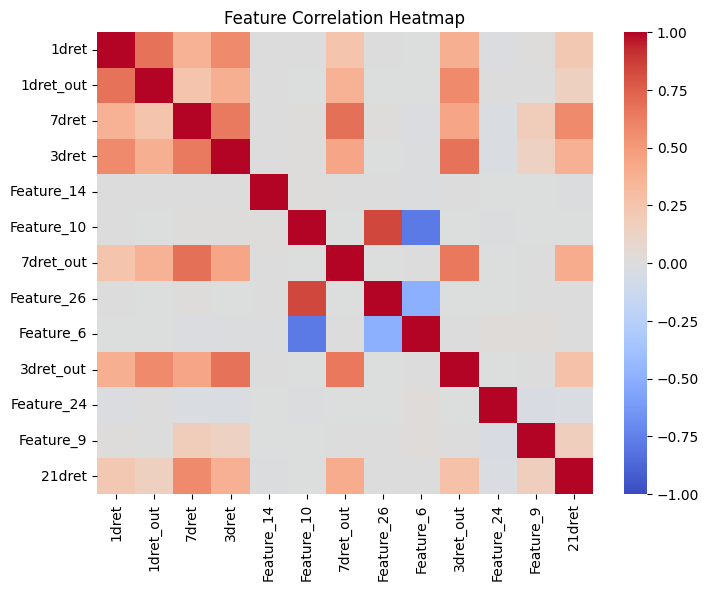

In [32]:
corr_matrix = df_all_ready_z_valid.loc[:,regression_selection_top13].corr()

# 1. Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap')

# print feature selection:
#print(f'Feature selection for standard y-label {regression_selection_top13}')
print(f'Feature selection for outperf y-label {regression_selection_top13}')
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            pair_info = f"{corr_matrix.columns[i]} - {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.4f}"
            high_corr_pairs.append(pair_info)
            print(pair_info)

Dismiss Feature 10

In [33]:
regression_selection_final = [feature for feature in regression_selection_top13 if feature != 'Feature_10']
print(f'Final Feature Selection: {regression_selection_final}')

Final Feature Selection: ['1dret', '1dret_out', '7dret', '3dret', 'Feature_14', '7dret_out', 'Feature_26', 'Feature_6', '3dret_out', 'Feature_24', 'Feature_9', '21dret']


Section Result:
- Univariate regression was used to identify single feature candidates
- Corr matrix was used to exlude feature 10 as it is highly correlated with 2 other features

## Model Training & Prediction

Approach for train/validation set model selection:

- Train models on rolling window and calculate out of sample predictions in one run


In [34]:
# function to run rolling model
def run_rolling_model(df, features, target, model_type='ridge', train_window=756, retrain_period=21, **kwargs):
    """
    Runs rolling model training and predictions on:
    - Linear Regression
    - Lasso
    - Ridge
    - Logistic Regression
    - Random Forest
    - Gradient Boosting
    - MLP Regression
    - MLP Classification
    """
    
    # 1. Model Mapping
    model_map = {
        'linear': LinearRegression,
        'lasso': Lasso,
        'ridge': Ridge,
        'logit': LogisticRegression,
        'rf': RandomForestRegressor,
        'gbr': GradientBoostingRegressor,
        'mlp_reg': MLPRegressor,   # Neural Net Regression
        'mlp_logit': MLPClassifier # Neural Net Classification
    }
    
    if model_type.lower() not in model_map:
        raise ValueError(f"Model '{model_type}' nicht unterstützt. Wähle aus {list(model_map.keys())}")
    
    ModelClass = model_map[model_type.lower()]
    
    # Classification: check if model is classifier (Logit or MLP Logit)
    is_classifier = model_type.lower() in ['logit', 'mlp_logit']
    
    if is_classifier:
        # Binarize target to 0/1
        target_data = (df[target] > 0).astype(int)
    else:
        target_data = df[target]
    # --------------------------------
    
    # 2. Setup
    unique_dates = df.index.get_level_values('Date').unique().sort_values()
    predictions = []
    coefficients = []
    
    print(f"Starte Rolling {ModelClass.__name__} (Retrain alle {retrain_period} Tage)...")
    
    # 3. Rolling Loop
    for i in tqdm(range(train_window, len(unique_dates), retrain_period)):
        train_dates = unique_dates[i - train_window : i]
        test_dates = unique_dates[i : min(i + retrain_period, len(unique_dates))]
        
        if len(test_dates) == 0:
            break
            
        X_train = df.loc[train_dates, features]
        y_train = target_data.loc[train_dates]
        X_test = df.loc[test_dates, features]
        
        # Fit model
        model = ModelClass(**kwargs)
        
        # MLPs may raise convergence warnings in small windows
        try:
            model.fit(X_train, y_train)
        except Exception as e:
            print(f"Fit error at {train_dates[-1]}: {e}")
            continue
        
        # Predict
        if is_classifier:
            # Probability of class 1 (positive return)
            y_pred = model.predict_proba(X_test)[:, 1]
        else:
            # Continuous value
            y_pred = model.predict(X_test)
            
        pred_df = pd.DataFrame(y_pred, index=X_test.index, columns=['pred_ret'])
        predictions.append(pred_df)
        
        # Feature importance / coefficients
        stats_entry = {'Date': train_dates[-1]}
        
        if hasattr(model, 'coef_'):
            # Store coefs only for linear models (not MLP)
            if model_type not in ['mlp_reg', 'mlp_logit']: 
                intercept = model.intercept_
                coefs = model.coef_
                if is_classifier:
                     intercept = intercept[0] if isinstance(intercept, (np.ndarray, list)) else intercept
                     coefs = coefs[0] if coefs.ndim > 1 else coefs
                
                stats_entry['Intercept'] = intercept
                stats_entry.update(dict(zip(features, coefs)))
        
        # Tree models
        elif hasattr(model, 'feature_importances_'):
            stats_entry.update(dict(zip(features, model.feature_importances_)))
            
        coefficients.append(stats_entry)

    # 4. Zusammenfügen
    df_preds = pd.concat(predictions).sort_index()
    
    # Target anfügen
    target_name = f"{target}_binary" if is_classifier else target
    target_to_join = target_data.rename(target_name)
    df_preds = df_preds.join(target_to_join, how='left')
    
    # Stats DataFrame
    df_stats = pd.DataFrame(coefficients).set_index('Date') if coefficients else pd.DataFrame()
    
    return df_preds, df_stats

In [35]:
# function to run rolling model per industry
def run_rolling_model_per_industry(df, features, target, model_type='ridge', train_window=756, retrain_period=21, **kwargs):
    """
    Runs rolling model training and predictions on INDUSTRY INDUSTRY LEVEL:
    - Linear Regression
    - Lasso
    - Ridge
    - Logistic Regression
    - Random Forest
    - Gradient Boosting
    - MLP Regression
    - MLP Classification
    """
    
    # 1. Model Mapping
    model_map = {
        'linear': LinearRegression,
        'lasso': Lasso,
        'ridge': Ridge,
        'logit': LogisticRegression,
        'rf': RandomForestRegressor,
        'gbr': GradientBoostingRegressor,
        'mlp_reg': MLPRegressor,
        'mlp_logit': MLPClassifier
    }
    
    if model_type.lower() not in model_map:
        raise ValueError(f"Model '{model_type}' not supported.")
    
    ModelClass = model_map[model_type.lower()]
    is_classifier = model_type.lower() in ['logit', 'mlp_logit']

    # Prepare Target (Global preparation is faster)
    if is_classifier:
        target_data_all = (df[target] > 0).astype(int)
    else:
        target_data_all = df[target]

    # Containers for results
    all_predictions = []
    all_stats = []
    
    # Get list of industries from the MultiIndex
    industries = df.index.get_level_values('Industry').unique().sort_values()
    
    print(f"Starting Industry-Specific Rolling {ModelClass.__name__}...")
    print(f"Industries: {len(industries)} | Window: {train_window} | Step: {retrain_period}")

    # --- OUTER LOOP: INDUSTRIES ---
    for industry in tqdm(industries, desc="Processing Industries"):
        
        # 1. Isolate Data for this Industry (Time Series)
        try:
            # xs drops the 'Industry' level, leaving just 'Date' index
            df_ind = df.xs(industry, level='Industry')
            y_ind = target_data_all.xs(industry, level='Industry')
        except KeyError:
            continue
            
        unique_dates = df_ind.index.sort_values()
        
        # 2. INNER LOOP: ROLLING WINDOW (Time)
        # We iterate through time for THIS specific industry
        for i in range(train_window, len(unique_dates), retrain_period):
            train_dates = unique_dates[i - train_window : i]
            test_dates = unique_dates[i : min(i + retrain_period, len(unique_dates))]
            
            if len(test_dates) == 0:
                break
                
            X_train = df_ind.loc[train_dates, features]
            y_train = y_ind.loc[train_dates]
            X_test = df_ind.loc[test_dates, features]
            
            # Skip if not enough data
            if len(X_train) < 50: 
                continue

            # Train Model
            model = ModelClass(**kwargs)
            try:
                model.fit(X_train, y_train)
            except Exception:
                continue
            
            # Predict
            if is_classifier:
                pred = model.predict_proba(X_test)[:, 1]
            else:
                pred = model.predict(X_test)
                
            # Store Prediction
            # Important: We must restore the 'Industry' information for the final merge
            pred_df = pd.DataFrame(pred, index=X_test.index, columns=['pred_ret'])
            pred_df['Industry'] = industry # Add column to set index later
            all_predictions.append(pred_df)
            
            # Store Coefficients / Feature Importance
            stats_entry = {'Date': train_dates[-1], 'Industry': industry}
            
            if hasattr(model, 'coef_'):
                if model_type not in ['mlp_reg', 'mlp_logit']:
                    intercept = model.intercept_
                    coefs = model.coef_
                    if is_classifier:
                        intercept = intercept[0] if isinstance(intercept, (np.ndarray, list)) else intercept
                        coefs = coefs[0] if coefs.ndim > 1 else coefs
                    
                    stats_entry['Intercept'] = intercept
                    stats_entry.update(dict(zip(features, coefs)))
            
            elif hasattr(model, 'feature_importances_'):
                stats_entry.update(dict(zip(features, model.feature_importances_)))
                
            all_stats.append(stats_entry)

    # --- 3. REASSEMBLE ---
    
    # Concatenate Predictions
    if all_predictions:
        df_preds = pd.concat(all_predictions)
        # Restore MultiIndex (Date, Industry)
        df_preds = df_preds.reset_index().set_index(['Date', 'Industry']).sort_index()
        
        # Join original target for reference
        target_name = f"{target}_binary" if is_classifier else target
        target_to_join = target_data_all.rename(target_name)
        df_preds = df_preds.join(target_to_join, how='left')
    else:
        df_preds = pd.DataFrame()

    # Concatenate Stats
    if all_stats:
        df_stats = pd.DataFrame(all_stats)
        # Stats now indexed by Date AND Industry
        df_stats = df_stats.set_index(['Date', 'Industry']).sort_index()
    else:
        df_stats = pd.DataFrame()
        
    return df_preds, df_stats

In [36]:
# function to evaluate predictions
def evaluate_predictions(df, pred_col='pred_ret', target_col='ret_t+1_out', is_ensamble=False):
    """
    Calculates metrics for regression AND classification (probabilities).
    Automatically detects if dealing with probabilities.
    """
    # 1. Cleanup
    df_clean = df.dropna(subset=[pred_col, target_col]).copy()
    
    if len(df_clean) == 0:
        return {'IC': np.nan, 'Rank_IC': np.nan, 'Hit_Rate': np.nan}

    y_true = df_clean[target_col]
    y_pred = df_clean[pred_col]

    # 2. Check: Is it probabilities? (Logit / MLP Classifier)
    # Assumption: Values are between 0 and 1 AND no negative values exist.
    is_probability = (y_pred.min() >= 0) and (y_pred.max() <= 1)

    # ---------------------------------------------------------
    # METRIC 1: Information Coefficient (IC) - The most important test
    # ---------------------------------------------------------
    # Measures: Does my signal (score/return) correlate with the real return?
    # Works equally well for BOTH (Regression & Classification).
    ic_pearson, _ = pearsonr(y_pred, y_true)
    ic_spearman, _ = spearmanr(y_pred, y_true) # Rank IC

    # ---------------------------------------------------------
    # METRIC 2: Hit Rate (Sign correctness)
    # ---------------------------------------------------------
    if is_probability:
        # Classification: Probability > 50% means "Positive return expected"
        # We compare this with: Was the real return > 0?
        hits = (y_pred > 0.5) == (y_true > 0)
    else:
        # Regression: Sign of prediction must match sign of return
        # np.sign returns 1, 0, -1
        hits = np.sign(y_pred) == np.sign(y_true)
        
    hit_rate = np.mean(hits)

    # ---------------------------------------------------------
    # METRIC 3: R2 & MSE (Only useful for regression)
    # ---------------------------------------------------------
    if not is_probability and not is_ensamble:
        r2_oos = r2_score(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
    else:
        # For classification, R2 against continuous returns makes no sense (wrong scale)
        # We set it to NaN or calculate Brier Score (if target was binary), 
        # here we leave it empty to avoid confusion.
        r2_oos = np.nan
        mse = np.nan

    return {
        'IC': ic_pearson, 
        'Rank_IC': ic_spearman, 
        'Hit_Rate': hit_rate,
        #'R2_OOS': r2_oos, 
        #'MSE': mse,
        'Type': 'Proba' if is_probability else 'Reg'
    }

Config and run all models - run time abt 2 - 3min 

In [37]:
print(f'Feature selection: {regression_selection_final}')

Feature selection: ['1dret', '1dret_out', '7dret', '3dret', 'Feature_14', '7dret_out', 'Feature_26', 'Feature_6', '3dret_out', 'Feature_24', 'Feature_9', '21dret']


In [38]:

# Configuration
data_input = df_all_ready_z_valid #.loc[:'2020']  df_all_ready
features_selected = regression_selection_final #regression_selection_final_top13  feature_select_ret_z_merge # feature_select_ret_z_out# feature_select_ret_z_merge #feature_select_ret_out_merge 
features_all = df_all_ready_z_valid.columns[:-2]
target_col = 'ret_t+1_out' # 'ret_t+1' # 'ret_t+1_out'
train_window = 252 * 5 # 5y window 
retrain_period = 21 * 3 # 3m step

#1. Linear (OLS)
df_res_linear, df_stats_linear = run_rolling_model_per_industry(
    data_input, 
    features_selected, 
    target_col, 
    model_type='linear',
    train_window=train_window,
    retrain_period=retrain_period
)

#2. Lasso (with alpha, careful with convergence on unscaled data)
df_res_lasso, df_stats_lasso = run_rolling_model_per_industry(
    data_input, 
    features_selected, 
    target_col, 
    model_type='lasso', 
    alpha=0.01,
    train_window=train_window,
    retrain_period=retrain_period
)

# 3. Ridge (with alpha)
df_res_ridge, df_stats_ridge = run_rolling_model_per_industry(
    data_input, 
    features_selected, 
    target_col, 
    model_type='ridge', 
    alpha= 0.5 * train_window * numb_industry,
    train_window=train_window,
    retrain_period=retrain_period
)

# 4. Logistic Regression (Logit) # L2 regularization in sklearn standard
df_res_logit, df_stats_logit = run_rolling_model_per_industry(
    df=data_input, 
    features=features_selected, 
    target=target_col, 
    model_type='logit',
    train_window=train_window,
    retrain_period=retrain_period
)

# 5. Random Forest (RF)
df_res_rf, df_stats_rf = run_rolling_model(
    df=data_input, 
    features=features_selected, 
    target=target_col, 
    model_type='rf',           # Wählt den RandomForestRegressor
    train_window=train_window,
    retrain_period=retrain_period * 4,
    
    # --- Hier kommen die Config-Parameter direkt rein ---
    n_estimators=75,
    max_depth=4,               # Important: Flate trees against overfitting
    min_samples_leaf=50,       # Ignore noise (min 50 occurances per leaf)
    max_features='sqrt',       # Diversification --> 12 FEatures makes 3 random Features to select per node
    random_state=42,
    n_jobs=-1                  # Use all CPU cores (faster!) ?
)

####### NN Case regression and logit
nn_params = {
    'hidden_layer_sizes': (13, 13, 4), 
    'solver': 'adam',
    'activation': 'relu',
    'alpha': 0.0001,       # Leichte Regularisierung
    'learning_rate_init': 0.001,
    'max_iter': 200,       # Epochen
    'early_stopping': True, # WICHTIG: Stoppt, wenn es nicht besser wird (spart Zeit!)
    'random_state': 42
}

# 6. MLP Regression (Prediction of return)
df_res_mlp_reg, _ = run_rolling_model(
    df=data_input, 
    features=features_selected, 
    target='ret_t+1_out', 
    model_type='mlp_reg',
    train_window=train_window, 
    retrain_period=retrain_period * 4,
    **nn_params
)

# 7. MLP Logit (Prediction of probability > 0)
df_res_mlp_logit, _ = run_rolling_model(
    df=data_input, 
    features=features_selected, 
    target='ret_t+1_out', 
    model_type='mlp_logit',
    train_window=train_window, 
    retrain_period=retrain_period * 4,
    **nn_params
)


Starting Industry-Specific Rolling LinearRegression...
Industries: 30 | Window: 1260 | Step: 63


Processing Industries: 100%|██████████| 30/30 [00:08<00:00,  3.51it/s]


Starting Industry-Specific Rolling Lasso...
Industries: 30 | Window: 1260 | Step: 63


Processing Industries: 100%|██████████| 30/30 [00:07<00:00,  3.89it/s]


Starting Industry-Specific Rolling Ridge...
Industries: 30 | Window: 1260 | Step: 63


...

100%|██████████| 21/21 [00:13<00:00,  1.53it/s]


Starte Rolling MLPRegressor (Retrain alle 252 Tage)...


100%|██████████| 21/21 [00:32<00:00,  1.54s/it]


Starte Rolling MLPClassifier (Retrain alle 252 Tage)...


100%|██████████| 21/21 [00:37<00:00,  1.80s/it]


Establishing ensemble model as avg of other model predictions
- Very crucial - std preds from different models due to logit vs regression but also different scale in general bevore apply mean

In [39]:
# All relevant strats into one dict
strategies = {
    'Linear': df_res_linear,
    'Lasso': df_res_lasso,
    'Ridge': df_res_ridge,
    'Logit': df_res_logit,
    'RandomForest': df_res_rf,
    'MLP_Reg': df_res_mlp_reg,
    'MLP_Logit': df_res_mlp_logit,
}
# std of predictions to make fair ensembling
rolling_window_ens = numb_industry * 21 * 6

# Create a list to hold all prediction series
pred_list = []
for name, df in strategies.items():
    # rolling standadization
    df = df['pred_ret'].to_frame()
    fill_numb = df.iloc[:rolling_window_ens]
    fill_mean =  df.iloc[:rolling_window_ens].mean()
    fill_std =  df.iloc[:rolling_window_ens].std()
    df = (df - df.rolling(rolling_window_ens).mean()) / (df.rolling(rolling_window_ens).std() + 0.01)
    df.iloc[:rolling_window_ens] = ((fill_numb - fill_mean) / fill_std)#.to_frame()
    # Rename series to model name to avoid collision during concat
    pred_list.append(df['pred_ret'].rename(name))
df_res_ensemble = pd.concat(pred_list, axis=1).mean(axis=1).to_frame('pred_ret')
df_res_ensemble['ret_t+1_out'] = data_input['ret_t+1_out']

# Concat, calculate mean, and assign as a DataFrame with 'pred_ret' column
strategies['Ensemble'] = df_res_ensemble
print('Ensemble model buil and contains of the following models:')
for model in list(strategies.keys())[:-1]:
    print(model)

Ensemble model buil and contains of the following models:
Linear
Lasso
Ridge
Logit
RandomForest
MLP_Reg
MLP_Logit


## Model (prediction) evaluation

Common statistcs usually fail on financial data regressions or other methods
- extreme low signal-to-noise ratio

In [40]:
from pandas import IndexSlice as idx

data_input.loc[idx['1994-02-28',['Autos', 'Beer']],:]
data_input.loc[(slice(None),['Autos', 'Beer']),:]

Feature                 1dret    21dret     3dret     7dret       rsi  \
Date       Industry                                                     
1994-02-28 Autos     0.644341 -1.255395 -1.045799 -1.611641 -1.731250   
           Beer      1.309355 -0.080974 -0.066325  0.627922  0.948630   
1994-03-01 Autos    -0.436207 -1.113772 -0.335642 -1.363229 -2.347830   
           Beer     -0.498780  0.037335  0.533723  0.580846  1.033795   
1994-03-02 Autos     1.966986 -1.133077  1.224179 -0.307101 -1.498947   
...                       ...       ...       ...       ...       ...   
2019-12-30 Beer     -0.448806 -0.113413  0.078611  0.373584  0.132441   
2019-12-31 Autos     0.295714  0.920505 -0.534859 -0.054330  1.272371   
           Beer      0.017852 -0.048831 -0.052372  0.224050  0.554867   
2020-01-02 Autos     1.180627  1.215035  0.255049  0.330283  1.379120   
           Beer     -0.536766 -0.136525 -0.559455 -0.409930  0.009528   

Feature                   vol  1dret_out  21dret_out  3dret_out  7dret_out  \
Date       Industry                                                          
1994-02-28 Autos     0.617528   0.301268   -0.654689  -0.776987  -1.030829   
           Beer      0.443781   1.094854    0.592872   0.385426   1.473318   
1994-03-01 Autos     0.584889   0.254510   -0.248946  -0.504646  -0.728845   
           Beer      0.400738   0.179578    0.975192   0.526734   1.448245   
1994-03-02 Autos     0.549569   2.473155   -0.115907   1.696338   0.182156   
...                       ...        ...         ...        ...        ...   
2019-12-30 Beer     -1.216533   0.017960   -0.224268   0.410198   0.428718   
2019-12-31 Autos    -0.661856   0.115529    0.900233  -0.422072  -0.165619   
           Beer     -1.214487  -0.274816   -0.368041   0.232825   0.198809   
2020-01-02 Autos    -0.578252   1.150657    0.972023   0.256257   0.341244   
           Beer     -1.171745  -1.269258   -0.787193  -0.849227  -0.628188   

Feature              ...  Feature_19  Feature_20  Feature_21  Feature_22  \
Date       Industry  ...                                                   
1994-02-28 Autos     ...    1.006226   -0.177355   -0.734335    0.062617   
           Beer      ...    1.005797   -0.177163   -0.734207    0.062697   
1994-03-01 Autos     ...   -0.099471   -1.011229    0.621848    1.074151   
           Beer      ...   -0.099324   -1.011118    0.621782    1.073671   
1994-03-02 Autos     ...    0.256331   -2.426221   -0.893591    0.085654   
...                  ...         ...         ...         ...         ...   
2019-12-30 Beer      ...   -0.716029   -0.653776    0.254550   -0.182343   
2019-12-31 Autos     ...    0.970754   -0.071973   -1.207691   -0.262302   
           Beer      ...    0.970409   -0.071959   -1.207094   -0.261832   
2020-01-02 Autos     ...   -0.030919    2.506977   -0.618880   -0.267528   
           Beer      ...   -0.030583    2.504222   -0.619123   -0.267127   

Feature              Feature_23  Feature_24  Feature_25  Feature_26   ret_t+1  \
Date       Industry                                                             
1994-02-28 Autos      -0.216219   -0.890468   -1.252020   -1.582469 -0.258200   
           Beer       -0.216370   -0.889991   -1.251356   -1.581678 -0.297527   
1994-03-01 Autos      -1.688873   -1.205099    0.487867   -1.049417  1.240678   
           Beer       -1.688599   -1.204514    0.487638   -1.049195 -0.293083   
1994-03-02 Autos      -0.254895   -0.823346   -0.272710   -0.438653  0.056962   
...                         ...         ...         ...         ...       ...   
2019-12-30 Beer       -0.125944   -0.797394    0.408551   -0.015219  0.034336   
2019-12-31 Autos       0.842169   -0.768105   -1.249067    0.361900  1.001906   
           Beer        0.841786   -0.767729   -1.248597    0.361506 -0.424371   
2020-01-02 Autos      -0.739015   -0.364808   -0.142831    1.087167 -0.440582   
           Beer       -0.738627   -0.364382   -0.142703    1.086588  0.016

In [41]:
## Check on linear model statistics - shows signifcant features but not much to interpret
industry_selected = 'Autos' # Beer, 
X = data_input.loc[(slice(None), industry_selected), features_selected]         
y = data_input.loc[(slice(None), industry_selected), 'ret_t+1_out']

# 2. Konstante hinzufügen (Wichtig! Statsmodels macht das nicht automatisch)
X = sm.add_constant(X)
# 3. Modell rechnen (OLS = Ordinary Least Squares)
model = sm.OLS(y, X).fit()
# 4. Ergebnisse ausgeben
# .summary() ist der "Heilige Gral" der Statistiker
print(model.summary())



                            OLS Regression Results                            
Dep. Variable:            ret_t+1_out   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.339
Date:                Fri, 27 Feb 2026   Prob (F-statistic):            0.00548
Time:                        14:41:35   Log-Likelihood:                -5470.0
No. Observations:                6508   AIC:                         1.097e+04
Df Residuals:                    6495   BIC:                         1.105e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0115      0.007     -1.638      0.1

- some feature show significance - also the constant, adj-R2 is extremely low, F-Stat pretty high 
- classical statistical metrics are usually not signifcant on financial data, extremly high noise/signal ratio

 --> more trading success like metrics are needed

Look at trading relevant metrics that focus on prediction and label analysis:
- IC as information coeffcient: Corr of preds and true returns
- Rank_IC as spearman correlation i.e. corr on ranks
- Hit Rate: Proportion of correct sign predictions


In [42]:
# function to evaluate predictions

def get_metrics_df(strategies):
    # Define targets
    target_col_reg = 'ret_t+1_out'
    target_col_class = 'ret_t+1_out_binary'
    metrics_dict = {}
    # Loop through all strategies
    for name, df_res in strategies.items():
        # Choose proper target based on name or available columns
        if 'logit' in name.lower() or target_col_class in df_res.columns:
            target = target_col_class
        else:
            target = target_col_reg
        # Calculate metrics if columns exist
        if 'pred_ret' in df_res.columns and target in df_res.columns:
            if name == 'Ensemble':
                metrics_dict[name] = evaluate_predictions(df_res, target_col=target, is_ensamble=True)
            else:
                metrics_dict[name] = evaluate_predictions(df_res, target_col=target)
        else:
            print(f"Skipping {name}: Missing columns.")
    # Return sorted DataFrame
    df_metrics = pd.DataFrame(metrics_dict).T
    return df_metrics.sort_values(by='Rank_IC', ascending=False)

df_metrics = get_metrics_df(strategies)
display(df_metrics)

,IC,Rank_IC,Hit_Rate,Type
Ensemble,0.038546,0.038351,0.513288,Reg
Linear,0.03466,0.035373,0.510982,Reg
Lasso,0.033568,0.035219,0.512189,Reg
Logit,0.029312,0.027383,0.510798,Proba
Ridge,0.013038,0.020763,0.508105,Reg
RandomForest,0.027219,0.018589,0.505964,Reg
MLP_Logit,0.009791,0.007911,0.502433,Proba
MLP_Reg,0.011737,0.005856,0.500762,Reg


Check models predictions for industry biases - This check was not performed thoroughly 

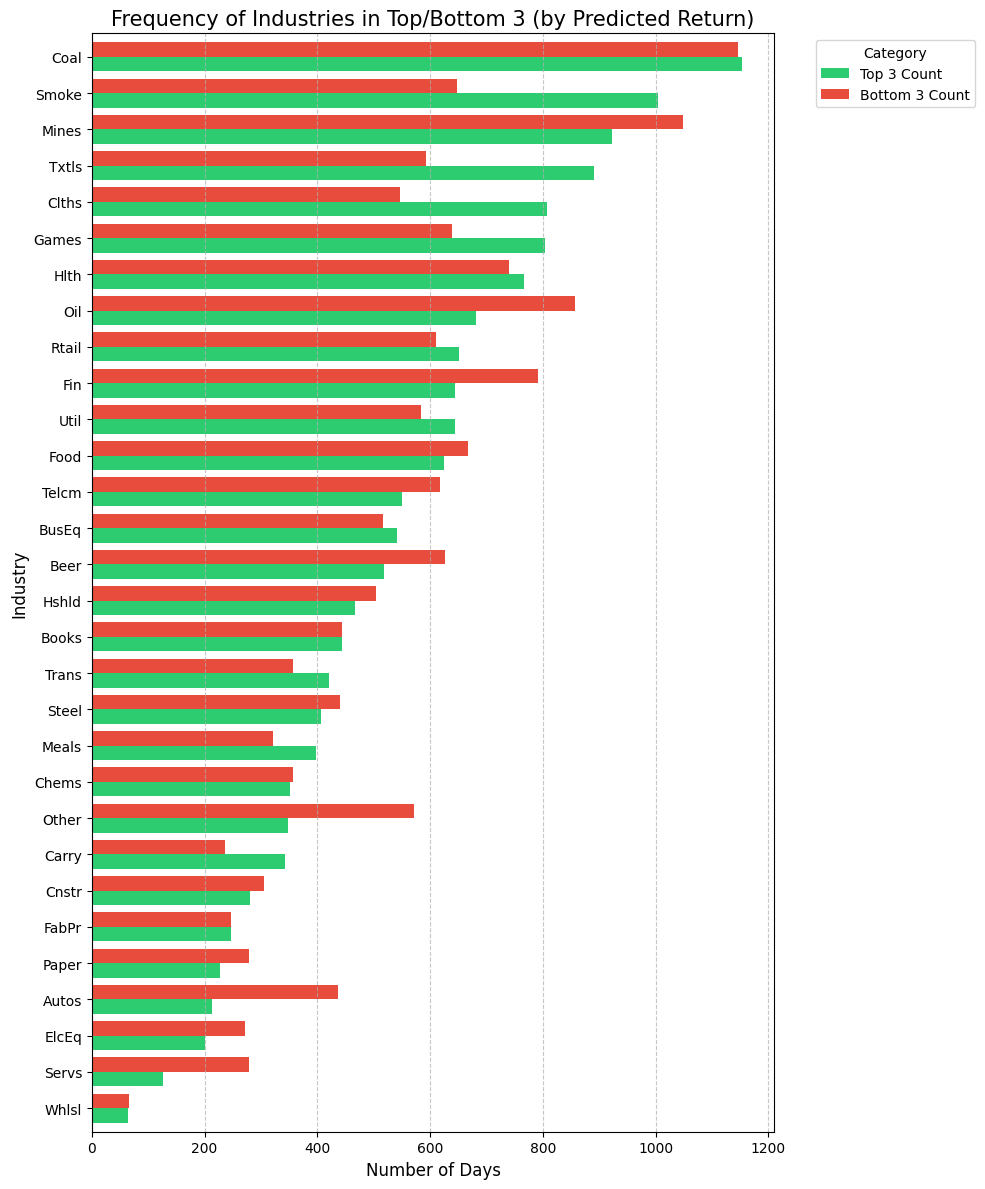

In [43]:
# block that check industry bias

# 1. Calculate the frequencies
results_of_model = df_res_linear # df_res_linear, df_res_lasso,.. df_res_mlp_reg
top_3_indices = results_of_model.groupby('Date')['pred_ret'].nlargest(3).index
bot_3_indices = results_of_model.groupby('Date')['pred_ret'].nsmallest(3).index

# Extract industry names (Level 1 of the index)
top_counts = top_3_indices.get_level_values('Industry').value_counts()
bot_counts = bot_3_indices.get_level_values('Industry').value_counts()
# 2. Combine into a single DataFrame for plotting
stats_df = pd.DataFrame({
    'Top 3 Count': top_counts,
    'Bottom 3 Count': bot_counts
}).fillna(0).astype(int)

# 3. Sort by 'Top 3 Count' so the chart is easy to read
stats_df = stats_df.sort_values('Top 3 Count', ascending=True)

# 4. Create the Plot
ax = stats_df.plot(
    kind='barh', 
    figsize=(10, 12), 
    color=['#2ecc71', '#e74c3c'], # Green for Top, Red for Bottom
    width=0.8
)

# Formatting
ax.set_title('Frequency of Industries in Top/Bottom 3 (by Predicted Return)', fontsize=15)
ax.set_xlabel('Number of Days', fontsize=12)
ax.set_ylabel('Industry', fontsize=12)
ax.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Section Result:
- Classical statistical metrics are not signifcant on financial data, extreme noise/signal ratio
- Trading relevant metrics show that all models are able to predict returns to some extend
- Ensemble model is superior to single models
- evaluating metrics suggest ensamble model
- Ensemble model will exclude MLP (DenseLayer NN)
- Ensemble ex. NN Models not yet tested at all... Correlation Effects might be really positive?

# Backtesting

Use predictions to run top 3 vs bottom 3 long-short strategy

In [44]:
# function to run backtest

def run_clean_backtest(model_results_dict, df_truth, benchmark_series=None, plot=True):
    """
    Runs a secure backtest for Top-3/Bottom-3 strategies.
    
    Args:
        model_results_dict (dict): { 'ModelName': df_preds }
                                   df_preds MUST contain 'pred_ret'.
        df_truth (pd.DataFrame):   The Master-DF with the REAL 'ret_t+1' column.
        benchmark_series (pd.Series): Optional, Daily Returns of the benchmark (e.g. Market).
        plot (bool):               Whether to create a chart.
        
    Returns:
        detailed_strats (dict):    Dictionary with detailed DFs per strategy.
        daily_returns (pd.DataFrame): Table with daily returns of all strategies.
    """
    
    detailed_strats = {}
    daily_returns_list = []
    
    # --- 1. Helper function for weighting (Top 3 / Bottom 3) ---
    def assign_weights(group):
        # Sort descending (Highest prediction at top)
        group = group.sort_values(by='pred_ret', ascending=False)
        
        # Initialize weights
        weights = pd.Series(0.0, index=group.index)
        
        # Ensure enough assets are available
        if len(group) >= 6:
            weights.iloc[:3] = 1/3   # Top 3 Long
            weights.iloc[-3:] = -1/3 # Bottom 3 Short
        return weights

    # --- 2. Loop over all models ---
    for name, df_pred in model_results_dict.items():
        # A. SAFETY FIRST: Only take the prediction!
        # We only copy 'pred_ret', everything else (old returns, binary targets) is deleted.
        if 'pred_ret' not in df_pred.columns:
            print(f"Warnung: 'pred_ret' missing in {name}, skip...")
            continue
            
        df_clean = df_pred[['pred_ret']].copy()
        
        # B. JOIN TRUTH: Append real returns (Left Join preserves prediction index)
        df_strat = df_clean.join(df_truth[['ret_t+1']], how='left').dropna()
        
        # C. WEIGHTS & RETURN
        # group_keys=False is important to keep the index clean
        df_strat['weight'] = df_strat.groupby('Date', group_keys=False).apply(assign_weights)
        
        # Strategy Return = Weight * Realized Return (t+1)
        df_strat['strat_ret'] = df_strat['weight'] * df_strat['ret_t+1']
        
        # Save details
        detailed_strats[name] = df_strat
        
        # Aggregate daily performance (Sum of positions)
        daily_perf = df_strat.groupby('Date')['strat_ret'].sum()
        daily_perf.name = name
        daily_returns_list.append(daily_perf)

    # --- 3. Merge ---
    df_daily_returns = pd.concat(daily_returns_list, axis=1).sort_index()
    
    # Add benchmark, if available
    if benchmark_series is not None:
        # Ensure benchmark covers the same index period
        common_idx = df_daily_returns.index.intersection(benchmark_series.index)
        df_daily_returns['Market_Benchmark'] = benchmark_series.loc[common_idx]

    # --- 4. Plotting ---
    if plot:
        plt.figure(figsize=(12, 6))
        cumulative = df_daily_returns.cumsum() # (1 + df_daily_returns / 100).cumprod() #df_daily_returns.cumsum()
        
        for col in cumulative.columns:
            # Styling
            if 'Benchmark' in col:
                plt.plot(cumulative[col], label=col, color='black', linestyle='--', linewidth=2, alpha=0.7)
            elif 'Ensemble' in col:
                plt.plot(cumulative[col], label=col, linewidth=2.5, color='gold') # Highlight Ensemble
            else:
                plt.plot(cumulative[col], label=col, linewidth=1.5, alpha=0.8)

        #plt.yscale('log')        
        plt.title('Cumulative Performance (Long-Short Top 3)')
        plt.xlabel('Date')
        plt.ylabel('Cumulative Return')
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

    return detailed_strats, df_daily_returns

In [45]:
# function to calculate performance metrics

def calculate_performance_metrics(df_returns, risk_free_rate=0.0):
    """
    Calculates comprehensive performance metrics for strategy returns.
    
    Args:
        df_returns (pd.DataFrame): Daily returns (decimal, e.g., 0.01 for 1%).
        risk_free_rate (float): Risk-free rate p.a. (default: 0.0).
        
    Returns:
        df_metrics (pd.DataFrame): DataFrame with all KPIs (numeric).
        drawdown_dict (dict): Dictionary containing drawdown series for plotting.
    """
    metrics = {}
    drawdown_dict = {}
    
    # Trading days per year
    TRADING_DAYS = 252
    
    print("Calculating performance metrics...")
    
    for col in df_returns.columns:
        series = df_returns[col].dropna()
        if len(series) == 0:
            continue
            
        # 1. Basics
        # Cumulative Return (Compounding)
        cum_ret = (1 + series).cumprod()
        total_return = cum_ret.iloc[-1] - 1
        
        # Duration in years
        years = len(series) / TRADING_DAYS
        
        # 2. Return p.a. (CAGR)
        # Formula: (End_Value / Start_Value)^(1/Years) - 1
        # Handle negative total returns carefully for fractional powers if needed, 
        # but cum_ret is Price(t)/Price(0), so it should be positive unless bust.
        cagr = (cum_ret.iloc[-1])**(1/years) - 1
        
        # Alternative: Arithmetic Mean p.a.
        mean_return_pa = series.mean() * TRADING_DAYS
        
        # 3. Volatility p.a.
        vol_pa = series.std() * np.sqrt(TRADING_DAYS)
        
        # 4. Sharpe Ratio
        # Formula: (Rp - Rf) / sigma
        sharpe = (mean_return_pa - risk_free_rate) / vol_pa if vol_pa != 0 else 0
        
        # 5. Drawdown Analysis
        # Running Maximum
        running_max = cum_ret.cummax()
        drawdown = (cum_ret / running_max) - 1
        drawdown_dict[col] = drawdown
        
        max_drawdown = drawdown.min()
        
        # 6. Recovery Period (Max Duration in Drawdown)
        is_drawdown = drawdown < 0
        # Group consecutive drawdown days
        dd_groups = (is_drawdown != is_drawdown.shift()).cumsum()
        # Sum up days for drawdown groups
        dd_periods = is_drawdown.groupby(dd_groups).sum()
        max_recovery_days = dd_periods.max() if not dd_periods.empty else 0
        
        # 7. Sortino Ratio (Downside Deviation)
        ### WRONG
        # Only considers negative returns as risk
        #negative_returns = series[series < 0] # risk_free_rate / TRADING_DAYS
        #downside_std = negative_returns.std() * np.sqrt(TRADING_DAYS)
        ### RIGHT
        downside_diff = series - 0 #target_return risk_free_rate / TRADING_DAYS
        downside_diff[downside_diff > 0] = 0
        downside_var = (downside_diff**2).mean()
        downside_std = np.sqrt(downside_var) * np.sqrt(TRADING_DAYS)
        sortino = (mean_return_pa - risk_free_rate) / downside_std if downside_std != 0 else 0
        
        # 8. Calmar Ratio (Return / MaxDD)
        calmar = cagr / abs(max_drawdown) if max_drawdown != 0 else 0
        
        # 9. Win Rate
        win_rate = len(series[series > 0]) / len(series)
        
        # Store metrics
        metrics[col] = {
            'Return p.a. (CAGR)': cagr,
            'Return p.a. (Mean)': mean_return_pa,
            'Vol p.a.': vol_pa,
            'Sharpe Ratio': sharpe,
            'Sortino Ratio': sortino,
            'Max Drawdown': max_drawdown,
            'Calmar Ratio': calmar,
            'Recovery Days': max_recovery_days,
            'Win Rate': win_rate
        }
        
    df_metrics = pd.DataFrame(metrics).T
    
    # Sort by Sharpe Ratio
    df_metrics = df_metrics.sort_values(by='Sharpe Ratio', ascending=False)
    
    return df_metrics, drawdown_dict

# def plot_performance_summary(df_returns, drawdowns):
#     """
#     Plots the Equity Curve and Drawdown Chart.
#     """
#     fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    
#     # Define colors for distinct lines
#     colors = plt.cm.tab10.colors
    
#     # 1. Equity Curve (Top Chart)
#     equity_curve = (1 + df_returns).cumprod()
    
#     for i, col in enumerate(equity_curve.columns):
#         # Specific styling for Benchmark and Ensemble
#         if 'Benchmark' in col:
#             color = 'black'; lw = 2; alpha = 0.7; ls = '--'
#         elif 'Ensemble' in col:
#             color = 'gold'; lw = 2.5; alpha = 1.0; ls = '-'
#         else:
#             color = colors[i % 10]; lw = 1.5; alpha = 0.6; ls = '-'
            
#         ax1.plot(equity_curve.index, equity_curve[col], label=col, color=color, linewidth=lw, alpha=alpha, linestyle=ls)
        
#     ax1.set_title('Equity Curve (Wealth Index)')
#     ax1.set_ylabel('Performance (Start=1.0)')
#     ax1.grid(True, linestyle='--', alpha=0.5)
#     ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    
#     # 2. Drawdown Chart (Bottom Chart)
#     for i, (name, dd_series) in enumerate(drawdowns.items()):
#         # Use same colors as above
#         if 'Benchmark' in name:
#             color = 'black'; lw = 1.5
#             ax2.plot(dd_series.index, dd_series, label=name, color=color, linestyle='--', linewidth=lw)
#         elif 'Ensemble' in name:
#             color = 'gold'; lw = 2
#             ax2.fill_between(dd_series.index, dd_series, 0, color=color, alpha=0.3)
#             ax2.plot(dd_series.index, dd_series, label=name, color=color, linewidth=lw)
#         else:
#             # Optional: Hide individual strategies in DD chart to avoid clutter, or make them very thin
#             pass 

#     ax2.set_title('Drawdown (Underwater Chart)')
#     ax2.set_ylabel('Drawdown %')
#     ax2.set_xlabel('Date')
#     ax2.grid(True, linestyle='--', alpha=0.5)
    
#     plt.tight_layout()
#     plt.show()



Show out of sample BT performance on validation set

In [46]:
strategies

{'Linear':                      pred_ret  ret_t+1_out
 Date       Industry                       
 1999-02-25 Autos     0.029498    -0.019795
            Beer      0.104930    -0.063297
            Books     0.038491     0.495625
            BusEq    -0.016025    -2.124947
            Carry     0.005983     0.693659
 ...                       ...          ...
 2020-01-02 Telcm     0.057261    -0.037768
            Trans    -0.072729    -0.104763
            Txtls    -0.008135    -0.855059
            Util     -0.130684     0.591688
            Whlsl     0.015038    -0.103179
 
 [157440 rows x 2 columns],
 'Lasso':                      pred_ret  ret_t+1_out
 Date       Industry                       
 1999-02-25 Autos     0.006556    -0.019795
            Beer      0.070627    -0.063297
            Books     0.025730     0.495625
            BusEq     0.002355    -2.124947
            Carry    -0.002049     0.693659
 ...                       ...          ...
 2020-01-02 Telcm     0.022

In [47]:
df_all_ready_z_valid

Feature                 1dret    21dret     3dret     7dret       rsi  \
Date       Industry                                                     
1994-02-28 Autos     0.644341 -1.255395 -1.045799 -1.611641 -1.731250   
           Beer      1.309355 -0.080974 -0.066325  0.627922  0.948630   
           Books     1.141676 -0.967803  0.129944 -0.319479 -0.500288   
           BusEq     0.647050  0.349209 -0.267814 -0.156553  0.724822   
           Carry    -0.035192  0.469255 -0.458353 -0.797522  0.927005   
...                       ...       ...       ...       ...       ...   
2020-01-02 Telcm     0.495840  0.305349  0.082810  0.041324  1.210996   
           Trans     1.042791  0.285290  0.199114  0.159645  0.932276   
           Txtls    -0.549915 -0.803048  0.134936 -0.490268 -0.931680   
           Util     -1.508005  0.592886 -0.562389 -0.680453  0.471742   
           Whlsl     0.193048  0.330021  0.030231 -0.033135  0.490159   

Feature                   vol  1dret_out  21dret_out  3dret_out  7dret_out  \
Date       Industry                                                          
1994-02-28 Autos     0.617528   0.301268   -0.654689  -0.776987  -1.030829   
           Beer      0.443781   1.094854    0.592872   0.385426   1.473318   
           Books    -0.216700   0.895036   -0.349773   0.618292   0.413786   
           BusEq     0.840029   0.304978    1.049319   0.146152   0.595711   
           Carry     0.079296  -0.508984    1.176375  -0.080055  -0.121224   
...                       ...        ...         ...        ...        ...   
2020-01-02 Telcm    -1.201513   0.182859   -0.215992   0.017780  -0.040969   
           Trans    -0.746166   0.951349   -0.242200   0.175412   0.113673   
           Txtls     0.278499  -1.286509   -1.655471   0.088116  -0.736678   
           Util     -0.930907  -2.630621    0.157003  -0.858063  -0.985637   
           Whlsl    -1.531848  -0.242748   -0.184482  -0.054308  -0.138996   

Feature              ...  Feature_19  Feature_20  Feature_21  Feature_22  \
Date       Industry  ...                                                   
1994-02-28 Autos     ...    1.006226   -0.177355   -0.734335    0.062617   
           Beer      ...    1.005797   -0.177163   -0.734207    0.062697   
           Books     ...    1.005368   -0.176971   -0.734080    0.062777   
           BusEq     ...    1.004939   -0.176780   -0.733953    0.062857   
           Carry     ...    1.004511   -0.176588   -0.733826    0.062937   
...                  ...         ...         ...         ...         ...   
2020-01-02 Telcm     ...   -0.022484    2.440259   -0.624978   -0.257466   
           Trans     ...   -0.022145    2.437680   -0.625223   -0.257062   
           Txtls     ...   -0.021805    2.435108   -0.625468   -0.256657   
           Util      ...   -0.021466    2.432542   -0.625713   -0.256252   
           Whlsl     ...   -0.021126    2.429983   -0.625959   -0.255847   

Feature              Feature_23  Feature_24  Feature_25  Feature_26   ret_t+1  \
Date       Industry                                                             
1994-02-28 Autos      -0.216219   -0.890468   -1.252020   -1.582469 -0.258200   
           Beer       -0.216370   -0.889991   -1.251356   -1.581678 -0.297527   
           Books      -0.216521   -0.889514   -1.250692   -1.580887 -0.310321   
           BusEq      -0.216672   -0.889038   -1.250029   -1.580097 -0.177474   
           Carry      -0.216823   -0.888562   -1.249367   -1.579308 -0.477530   
...                         ...         ...         ...         ...       ...   
2020-01-02 Telcm      -0.729356   -0.354099   -0.139625    1.072801 -0.464258   
           Trans      -0.728971   -0.353669   -0.139497    1.072231 -0.531252   
           Txtls      -0.728586   -0.353238   -0.139368    1.071661 -1.281549   
           Util       -0.728202   -0.352807   -0.139240    1.071092  0.165198   
           Whlsl      -0.727817   -0.352375   -0.139112    1.070523 -0.529

In [48]:
df_performance

NameError: name 'df_performance' is not defined

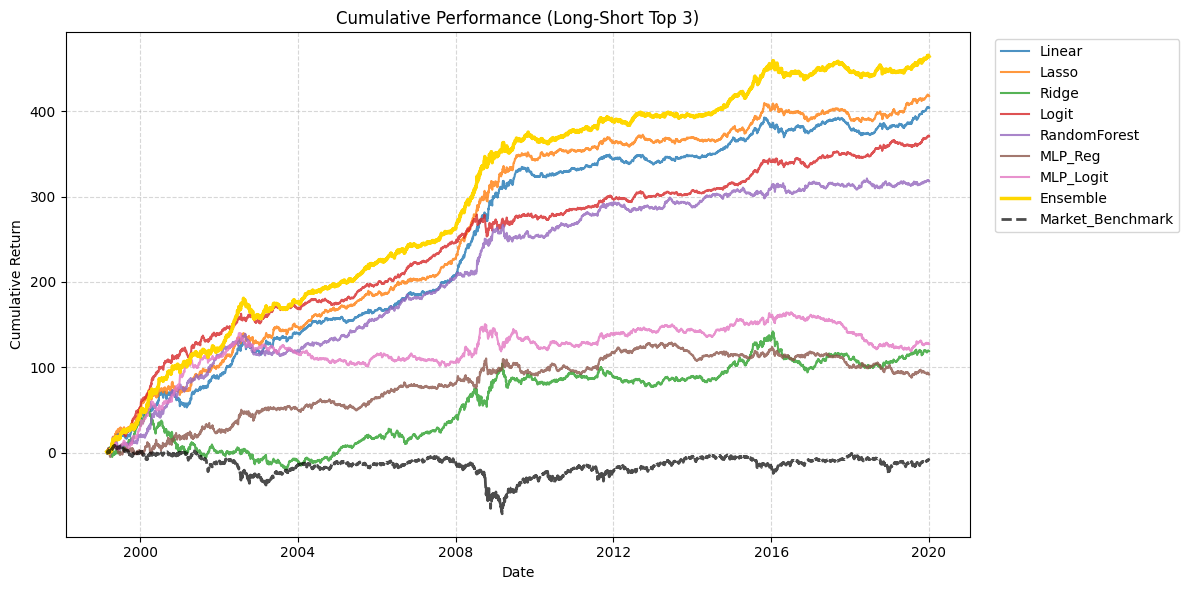

In [62]:
strategy_dates = data_input.index.get_level_values('Date').unique()

results_dict, df_performance = run_clean_backtest(
    model_results_dict=strategies,
    df_truth=df_all_ready_z_valid,       # Hier holen wir uns die echten Returns
    benchmark_series=df_market.loc[strategy_dates, 'ret_t+1'], # Deine Benchmark Series
    plot=True
)


Becnhmark Analysis

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

def run_random_benchmark(df_performance, df_universe, n_simulations=500, plot=True):
    """
    Vergleicht die Strategie-Performance mit einer zufälligen Auswahl (Monkey Test).
    
    Args:
        df_performance (pd.DataFrame): Deine Strategie-Returns (Spalten = Strategien).
        df_universe (pd.DataFrame): Der Master-DF (Muss 'ret_t+1' und MultiIndex Date/Industry haben).
        n_simulations (int): Wie viele Zufalls-Pfade simuliert werden sollen.
        plot (bool): Ob geplottet werden soll.
        
    Returns:
        df_quantiles (pd.DataFrame): Die Quantile (5%, 50%, 95%) der Zufallsverteilung.
        final_ranks (pd.Series): Perzentil-Ranking deiner Strategien am Ende (0.90 = Top 10%).
    """
    print(f"Starte Monkey-Test mit {n_simulations} Simulationen...")
    
    # 1. Daten Vorbereiten: Pivot zu (Date x Industry) Matrix
    # Wir brauchen schnellen Zugriff auf alle Returns eines Tages
    if 'ret_t+1' in df_universe.columns:
        target_col = 'ret_t+1'
    else:
        raise ValueError("Spalte 'ret_t+1' nicht in df_universe gefunden!")

    # Pivot: Index=Date, Columns=Industry
    df_pivot = df_universe.reset_index().pivot(index='Date', columns='Industry', values=target_col)
    
    # Schnittmenge der Daten finden
    common_dates = df_performance.index.intersection(df_pivot.index)
    df_perf_clean = df_performance.loc[common_dates]
    df_pivot_clean = df_pivot.loc[common_dates]
    
    # Array für Ergebnisse: (Tage, Simulationen)
    n_days = len(common_dates)
    random_matrix = np.zeros((n_days, n_simulations))
    
    # 2. Monte Carlo Loop (Tag für Tag)
    # Da die verfügbaren Industrien pro Tag wechseln, loopen wir über die Tage.
    # Innerhalb des Tages nutzen wir numpy für Speed.
    
    for t, date in enumerate(common_dates):
        # Alle validen Returns für diesen Tag holen
        daily_rets = df_pivot_clean.loc[date].dropna().values
        
        n_assets = len(daily_rets)
        if n_assets < 6:
            # Zu wenige Assets für 3L/3S -> Return 0 (Cash)
            continue
            
        # Vektorisiertes Sampling ist in numpy tricky ohne "replace=False" pro Zeile.
        # Wir nutzen hier einen schnellen List-Comprehension Ansatz mit np.random.choice
        # Strategie: 3 Long (+), 3 Short (-)
        
        # Performance-Tipp: Wir ziehen 6 Indizes
        # Um Speed zu gewinnen, machen wir das Sampling 'dirty' in einer Loop, 
        # da Python Loops über 500 Iterationen (n_sims) schnell genug sind.
        
        sim_rets = []
        for _ in range(n_simulations):
            # Wähle 6 zufällige Returns aus dem Topf dieses Tages
            picked = np.random.choice(daily_rets, size=6, replace=False)
            
            # 3 Long (Gewicht 1/3), 3 Short (Gewicht -1/3)
            # return = sum(longs)/3 - sum(shorts)/3
            ret = (np.sum(picked[:3]) - np.sum(picked[3:])) / 3.0
            sim_rets.append(ret)
            
        random_matrix[t, :] = sim_rets

    # 3. Kumulieren (Wir nutzen hier cumsum wie in deinem Backtest)
    # Monkey Paths
    random_df = pd.DataFrame(random_matrix, index=common_dates)
    random_cumulative = random_df.cumsum()
    
    # User Strategies
    user_cumulative = df_perf_clean.cumsum()

    # 4. Quantile berechnen (Der "Trichter")
    # Wir wollen wissen: Wo liegen 90% aller Zufalls-Strategien?
    quantiles = random_cumulative.quantile([0.05, 0.25, 0.5, 0.75, 0.95], axis=1).T
    
    # 5. Plotting
    if plot:
        plt.figure(figsize=(12, 7))
        
        # A. Der Zufalls-Bereich (Graue Zone)
        # 5% bis 95% (Extreme Outlier Range)
        plt.fill_between(quantiles.index, quantiles[0.05], quantiles[0.95], 
                         color='gray', alpha=0.15, label='Random 90% Range')
        
        # 25% bis 75% (Kern-Bereich)
        plt.fill_between(quantiles.index, quantiles[0.25], quantiles[0.75], 
                         color='gray', alpha=0.3, label='Random 50% Range (IQR)')
        
        # Median (Durchschnittlicher Zufall)
        plt.plot(quantiles.index, quantiles[0.5], color='black', linestyle=':', alpha=0.6, label='Random Median')
        
        # B. Deine Strategien
        colors = plt.cm.tab10.colors
        for i, col in enumerate(user_cumulative.columns):
            lw = 2.5 if 'Ensemble' in col else 1.5
            alpha = 1.0 if 'Ensemble' in col else 0.8
            # Z-Order hoch setzen, damit sie ÜBER der grauen Fläche liegen
            plt.plot(user_cumulative.index, user_cumulative[col], label=col, 
                     color=colors[i % 10], linewidth=lw, alpha=alpha)
            
        plt.title('Skill vs. Luck: Strategies against Random Sampling (3L/3S)')
        plt.xlabel('Date')
        plt.ylabel('Cumulative Return')
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()
        
    # 6. Ranking berechnen (Wo landest du am Ende?)
    # Wir vergleichen dein Endergebnis mit der Verteilung der Endergebnisse der Simulationen
    final_sim_values = random_cumulative.iloc[-1]
    final_user_values = user_cumulative.iloc[-1]
    
    ranks = {}
    for strat in final_user_values.index:
        # Prozent der Zufalls-Simulationen, die SCHLECHTER waren als du
        percentile = (final_sim_values < final_user_values[strat]).mean()
        ranks[strat] = percentile

    rank_series = pd.Series(ranks).sort_values(ascending=False)
    
    print("\n--- Final Skill Score (Percentile vs. Random) ---")
    print("1.00 = Besser als 100% aller Zufalls-Strategien (Gott-Modus)")
    print("0.50 = Genau Durchschnitt (Münzwurf)")
    print("0.00 = Schlechter als jeder Zufall (Systematisch falsch)")
    print("-" * 40)
    print(rank_series)
    
    return quantiles, rank_series

Starte Monkey-Test mit 500 Simulationen...


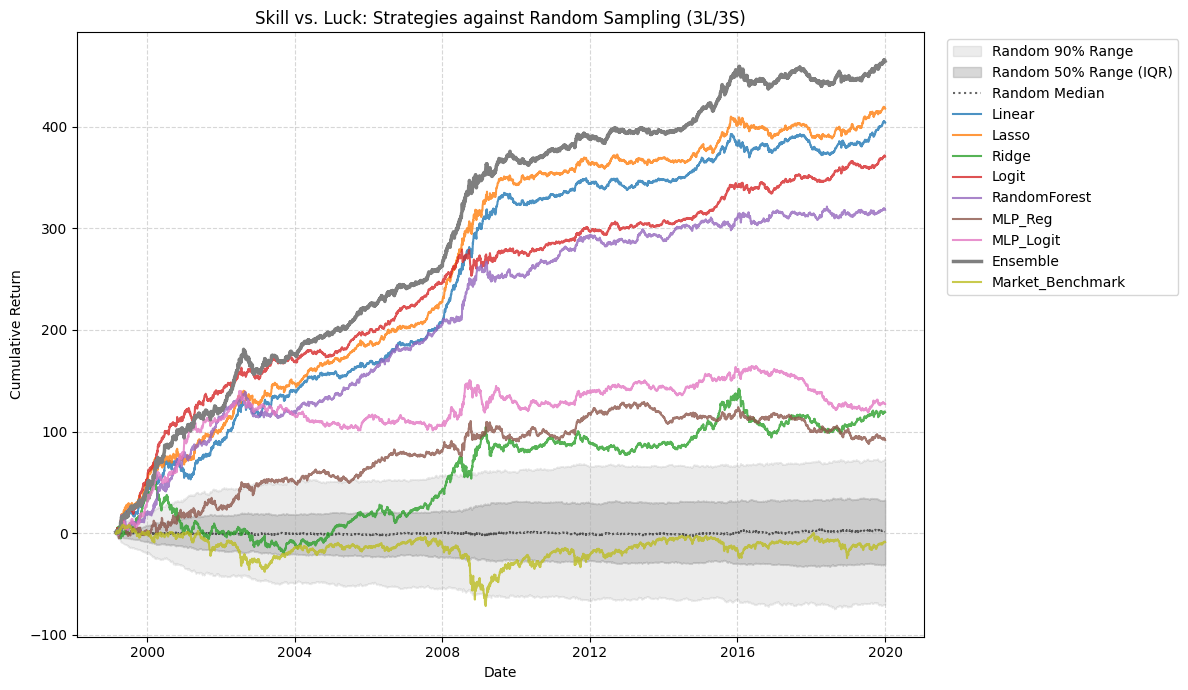


--- Final Skill Score (Percentile vs. Random) ---
1.00 = Besser als 100% aller Zufalls-Strategien (Gott-Modus)
0.50 = Genau Durchschnitt (Münzwurf)
0.00 = Schlechter als jeder Zufall (Systematisch falsch)
----------------------------------------
Linear              1.000
Lasso               1.000
Logit               1.000
RandomForest        1.000
Ensemble            1.000
Ridge               0.996
MLP_Logit           0.996
MLP_Reg             0.980
Market_Benchmark    0.422
dtype: float64


(                 0.05       0.25      0.50       0.75       0.95
 Date                                                            
 1999-02-25  -1.028478  -0.450488 -0.006884   0.390469   0.916363
 1999-02-26  -1.261683  -0.515450 -0.004262   0.461364   1.257957
 1999-03-01  -1.689759  -0.782527 -0.040508   0.631230   1.539590
 1999-03-02  -2.164763  -0.914525 -0.049182   0.830695   1.914157
 1999-03-03  -2.260862  -0.947652 -0.080115   0.912242   2.165816
 ...               ...        ...       ...        ...        ...
 2019-12-26 -69.995185 -30.809291  2.134893  32.586593  72.603160
 2019-12-27 -70.075421 -31.070834  2.131825  32.636415  72.648651
 2019-12-30 -70.020217 -31.151257  2.252292  32.609743  72.745018
 2019-12-31 -69.728624 -30.922493  1.727073  32.664812  72.674305
 2020-01-02 -70.150034 -30.669804  1.700732  32.518157  72.335347
 
 [5248 rows x 5 columns],
 Linear              1.000
 Lasso               1.000
 Logit               1.000
 RandomForest        1.000
 Ensem

In [64]:
run_random_benchmark(df_performance, df_all_ready_z_valid)

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm  # <--- HIER IST DAS NEUE IMPORT

def plot_empirical_distribution(df_performance, df_universe, n_simulations=5000):
    """
    Berechnet die finale Performance von zufälligen 3L/3S Strategien und 
    vergleicht sie mit deinen Modellen auf Basis der empirischen Verteilung.
    """
    print(f"Starte {n_simulations} Simulationen (Monkey Test)...")
    
    # 1. Deine finale Performance (Summe der täglichen diskreten Returns)
    user_final_returns = df_performance.sum()
    
    # 2. Datenvorbereitung für das Sampling
    df_pivot = df_universe.reset_index().pivot(index='Date', columns='Industry', values='ret_t+1')
    common_dates = df_performance.index.intersection(df_pivot.index)
    daily_matrix = df_pivot.loc[common_dates].values
    
    n_days = len(common_dates)
    random_final_returns = np.zeros(n_simulations)
    
    # 3. Monte Carlo: Wir nutzen tqdm für die äußere Schleife
    # "desc" gibt dem Ladebalken einen schönen Namen
    for t in tqdm(range(n_days), desc="Simuliere Tage"):
        row = daily_matrix[t]
        valid_returns = row[~np.isnan(row)]
        
        if len(valid_returns) < 6:
            continue
            
        # Schneller Loop für die Simulationen dieses Tages
        daily_sim_rets = np.zeros(n_simulations)
        for i in range(n_simulations):
            picked = np.random.choice(valid_returns, size=6, replace=False)
            # 3 Long (+), 3 Short (-)
            daily_sim_rets[i] = (np.sum(picked[:3]) - np.sum(picked[3:])) / 3.0
            
        random_final_returns += daily_sim_rets

    # 4. Quantile (Percentiles) für deine Strategien berechnen
    ranks = {}
    for strat in user_final_returns.index:
        # Welcher Anteil der Zufallsstrategien war schlechter als deine?
        percentile = np.mean(random_final_returns < user_final_returns[strat])
        ranks[strat] = percentile
        
    rank_series = pd.Series(ranks).sort_values(ascending=False)

    # 5. Plotting (Histogramm + CDF)
    plt.figure(figsize=(14, 8))
    
    # A. Histogramm der Zufalls-Strategien (Empirische Verteilung)
    ax = sns.histplot(random_final_returns, bins=25, kde=True, color='lightgray', 
                      stat='density', label='Random Portfolios (Distribution)')
    
    # B. Deine Strategien als vertikale Linien eintragen
    colors = plt.cm.tab10.colors
    y_max = ax.get_ylim()[1]
    
    for i, (strat, value) in enumerate(user_final_returns.items()):
        perc = ranks[strat]
        
        # Style für Benchmark und Ensemble hervorheben
        if 'Benchmark' in strat:
            color = 'black'; lw = 2; ls = '--'; zorder=5
        elif 'Ensemble' in strat:
            color = 'gold'; lw = 3; ls = '-'; zorder=10
        else:
            color = colors[i % 10]; lw = 1.5; ls = '-'; zorder=5
            
        plt.axvline(x=value, color=color, linestyle=ls, linewidth=lw, zorder=zorder,
                    label=f"{strat} ({value:.2f} | P: {perc:.2f})")

    plt.title(f'Empirical Distribution of Final Cumulative Returns ({n_simulations} Random 3L/3S Strategies)', fontsize=14)
    plt.xlabel('Final Cumulative Return (Arithmetic)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Strategies (Value | Percentile)')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # 6. Übersichtliche Ausgabe in der Konsole
    print("\n" + "="*50)
    print("📈 PERCENTILE RANKING (0.00 = Worst, 1.00 = Best)")
    print("="*50)
    for strat, perc in rank_series.items():
        print(f"{strat:<20}: {perc:.2%} (Value: {user_final_returns[strat]:.2f})")
    print("="*50)
    
    return random_final_returns, rank_series

c:\Users\nilss\anaconda3\envs\CursorEnvIBKRData\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Starte 1000 Simulationen (Monkey Test)...


Simuliere Tage: 100%|██████████| 5248/5248 [01:28<00:00, 59.28it/s]


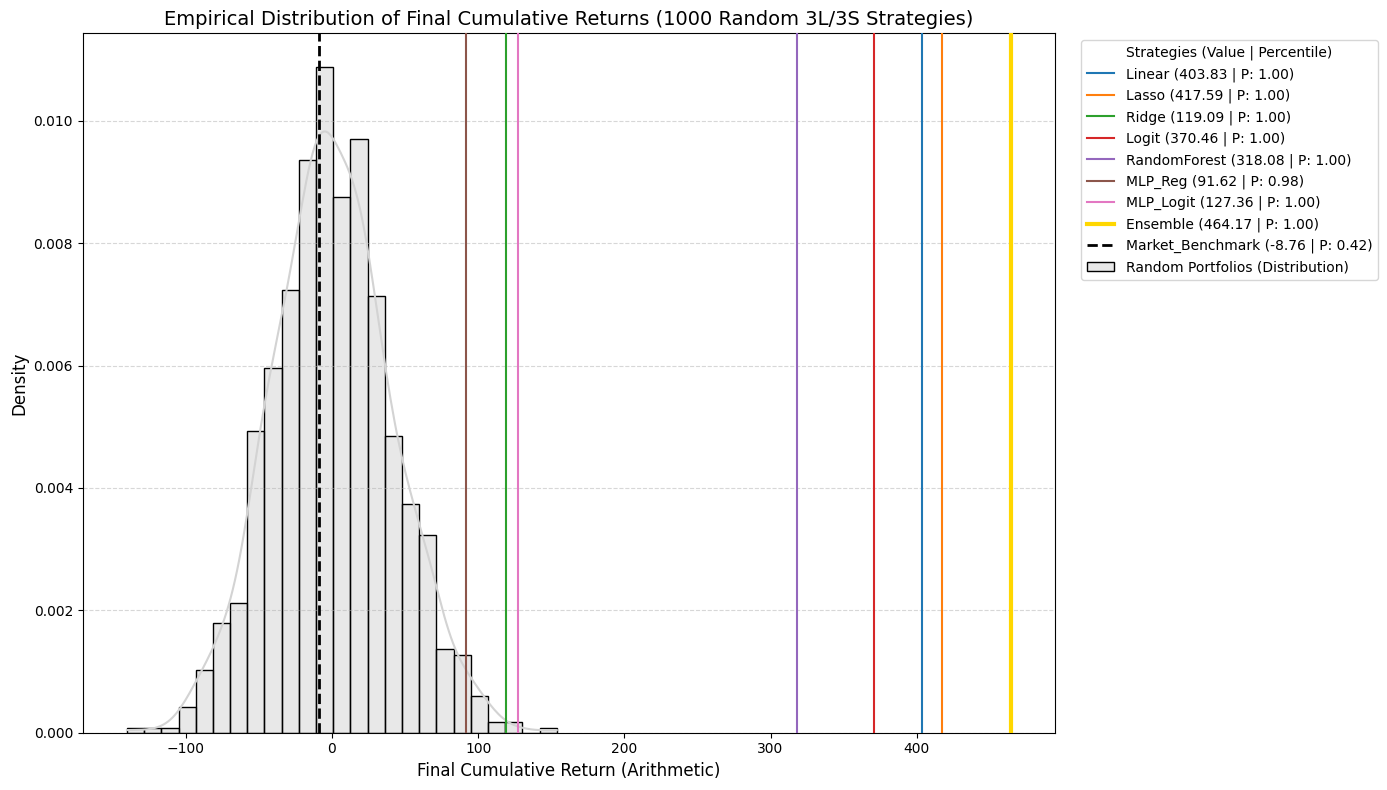


📈 PERCENTILE RANKING (0.00 = Worst, 1.00 = Best)
Linear              : 100.00% (Value: 403.83)
Lasso               : 100.00% (Value: 417.59)
Logit               : 100.00% (Value: 370.46)
RandomForest        : 100.00% (Value: 318.08)
Ensemble            : 100.00% (Value: 464.17)
Ridge               : 99.80% (Value: 119.09)
MLP_Logit           : 99.80% (Value: 127.36)
MLP_Reg             : 98.30% (Value: 91.62)
Market_Benchmark    : 41.60% (Value: -8.76)


(array([-2.46261545e+01, -3.94045745e+01, -3.16565472e+01,  3.42751569e+01,
         4.89511474e+01, -2.81260151e+00,  3.53852429e+01,  8.81572661e+00,
        -1.38657577e+00,  4.00434630e+00, -3.14283922e+01,  2.94747184e+01,
         4.50909008e+01,  1.10550652e+01,  2.61163030e+01,  3.23108315e+01,
        -4.16238854e+01, -4.24515531e+01, -3.09670795e+01,  5.91834559e+01,
        -8.33254012e+00,  6.95173123e+01, -3.87921783e+01,  4.42327413e+01,
        -2.12035564e+01, -5.65961806e+01,  1.54648805e+01, -3.13300371e+01,
        -7.07828793e+01,  9.04194383e+01, -2.12045725e+01, -2.74958909e+01,
         7.71481435e+01,  2.69934704e+01,  2.15854589e+01,  5.27199029e+00,
        -6.54100886e+01, -5.38334073e+01, -3.32333755e+01, -5.38644083e+01,
         4.28798604e+01,  2.43238251e+01,  4.78628619e+01,  4.01410866e+01,
         2.35859979e+01,  2.43623404e+01, -3.66485679e+01, -5.59425830e+01,
         2.76088974e+01,  2.02045122e+01,  1.66157414e+01,  2.54557035e+01,
        -6.9

In [66]:
plot_empirical_distribution(df_performance, df_all_ready_z_valid, n_simulations=1000)

Correlation analysis of strategies

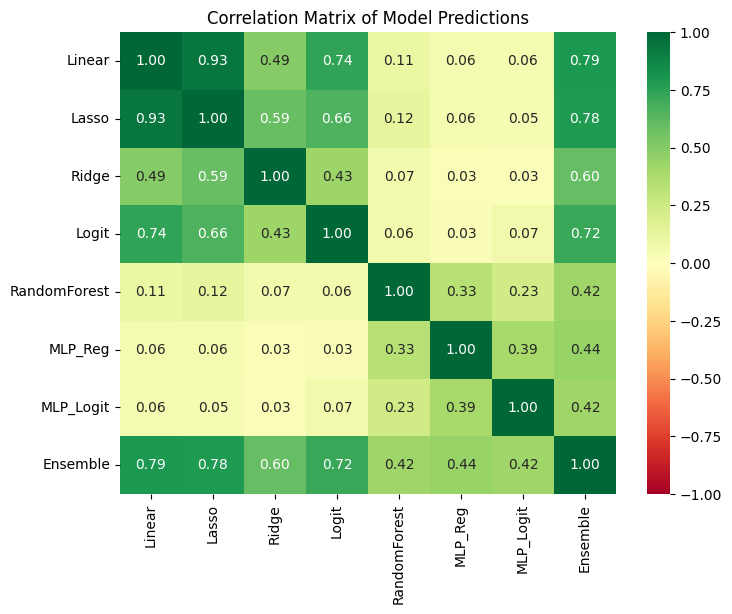

In [67]:
# 1. Alle Vorhersagen in einen einzigen DataFrame packen
# Wir matchen automatisch über den MultiIndex (Date, Industry)
all_preds = {}

for name, df in results_dict.items():
    if 'pred_ret' in df.columns:
        all_preds[name] = df['pred_ret']

df_corr_input = pd.DataFrame(all_preds)

# 2. Korrelation berechnen
corr_matrix = df_corr_input.corr()

# 3. Als Heatmap plotten (Beste Übersicht)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix of Model Predictions')
plt.show()

# # 4. Tabelle anzeigen
# display(corr_matrix)

Interpretation: alpha decay reported by many papers seems significant 

Show trading performance metrics on out of sample validation set
- Sharpe Ratio: mean return p.a. / vol p.a.
- Sortino Ratio: mean return p.a. / downside deviation
- Max Drawdown: max drawdown
- Calmar Ratio: mean return p.a. / max drawdown
- Recovery Days: max duration of drawdown
- Win Rate: number of positive returns / number of total returns (essentially hit ratio of strategy)

In [68]:
# 1. Check Data Scaling (Percentage vs Decimal)
df_perf_clean = df_performance.copy()
# If average return is > 0.1 (10% daily), data is likely in integers (1.0) instead of decimals (0.01)
if df_perf_clean.abs().mean().mean() > 0.1: 
    print("Info: Data is in percent (e.g. 1.0 = 1%). Dividing by 100 for correct metrics.")
    df_perf_clean = df_perf_clean / 100

# 2. Calculate Metrics
df_metrics, drawdown_series = calculate_performance_metrics(df_perf_clean)

# 3. Create a Formatted Display DataFrame (No Jinja2)
# We convert numbers to strings just for displaying purposes
df_display = df_metrics.copy()

# Format Percentages
pct_cols = ['Return p.a. (CAGR)', 'Return p.a. (Mean)', 'Vol p.a.', 'Max Drawdown', 'Win Rate']
for col in pct_cols:
    if col in df_display.columns:
        df_display[col] = df_display[col].apply(lambda x: f"{x:.2%}")

# Format Ratios (2 decimals)
ratio_cols = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio']
for col in ratio_cols:
    if col in df_display.columns:
        df_display[col] = df_display[col].apply(lambda x: f"{x:.2f}")

# Format Integers
if 'Recovery Days' in df_display.columns:
    df_display['Recovery Days'] = df_display['Recovery Days'].apply(lambda x: f"{x:.0f}")

print("\n--- Strategy Performance Metrics ---")
display(df_display)

Info: Data is in percent (e.g. 1.0 = 1%). Dividing by 100 for correct metrics.
Calculating performance metrics...

--- Strategy Performance Metrics ---


,Return p.a. (CAGR),Return p.a. (Mean),Vol p.a.,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Recovery Days,Win Rate
Ensemble,23.81%,22.29%,13.59%,1.64,2.52,-21.96%,1.08,964,54.84%
Logit,18.71%,17.79%,11.21%,1.59,2.45,-23.26%,0.80,568,54.74%
Lasso,21.11%,20.05%,13.35%,1.50,2.31,-21.26%,0.99,946,54.42%
Linear,20.38%,19.39%,12.92%,1.50,2.30,-21.17%,0.96,984,54.29%
RandomForest,15.48%,15.27%,13.29%,1.15,1.76,-23.61%,0.66,669,52.71%
MLP_Logit,5.43%,6.12%,12.88%,0.47,0.70,-37.48%,0.14,1605,50.71%
Ridge,4.74%,5.72%,14.74%,0.39,0.55,-53.57%,0.09,2034,52.13%
MLP_Reg,3.65%,4.40%,12.78%,0.34,0.50,-35.75%,0.10,1644,50.76%
Market_Benchmark,-1.36%,-0.42%,13.74%,-0.03,-0.04,-59.89%,-0.02,5194,52.08%


Train and build ensemble Model based on test set

In [69]:
# --- Usage Example ---

# Configuration
data_input_testset = df_all_ready_z.loc['2015':] # df_all_ready
features_selected = regression_selection_final # feature_select_ret_z_merge #feature_select_ret_out_merge 
features_all = df_all_ready_z.columns[:-2]
target_col = 'ret_t+1_out' # 'ret_t+1' # 'ret_t+1_out'
train_window = 252 * 5
retrain_period = 21 * 3

#1. Linear (OLS)
df_res_linear_testset, df_stats_linear_testset = run_rolling_model(
    data_input_testset, 
    features_selected, 
    target_col, 
    model_type='linear',
    train_window=train_window,
    retrain_period=retrain_period
)

#2. Lasso (with alpha, careful with convergence on unscaled data)
df_res_lasso_testset, df_stats_lasso_testset = run_rolling_model(
    data_input_testset, 
    features_selected, 
    target_col, 
    model_type='lasso', 
    alpha=0.01,
    train_window=train_window,
    retrain_period=retrain_period
)

# 3. Ridge (with alpha)
df_res_ridge_testset, df_stats_ridge_testset = run_rolling_model(
    data_input_testset, 
    features_selected, 
    target_col, 
    model_type='ridge', 
    alpha=0.5 * train_window * numb_industry,
    train_window=train_window,
    retrain_period=retrain_period
)

# 4. Logistic Regression (Logit)
df_res_logit_testset, df_stats_logit_testset = run_rolling_model(
    df=data_input_testset, 
    features=features_selected, 
    target=target_col, 
    model_type='logit',
    train_window=train_window,
    retrain_period=retrain_period
)
###### Random Forest case
# 5. Random Forest (RF)
df_res_rf_testset, df_stats_rf_testset = run_rolling_model(
    df=data_input_testset, 
    features=features_all, 
    target=target_col, 
    model_type='rf',           # Wählt den RandomForestRegressor
    train_window=train_window,
    retrain_period=retrain_period * 4,
    
    # --- Hier kommen die Config-Parameter direkt rein ---
    n_estimators=100,
    max_depth=4,               # WICHTIG: Flache Bäume gegen Overfitting
    min_samples_leaf=50,       # Rauschen ignorieren (min 50 Tage pro Blatt)
    max_features='sqrt',       # Diversifikation
    random_state=42,
    n_jobs=-1                  # Nutzt alle CPU Kerne (schneller!)
)

# nn_params = {
#     'hidden_layer_sizes': (16, 16, 8), 
#     'solver': 'adam',
#     'activation': 'relu',
#     'alpha': 0.0001,       # Leichte Regularisierung
#     'learning_rate_init': 0.001,
#     'max_iter': 200,       # Epochen
#     'early_stopping': True, # WICHTIG: Stoppt, wenn es nicht besser wird (spart Zeit!)
#     'random_state': 42
# }

# ####### NN Case regression and logit
# # 6. MLP Regression (Vorhersage der Renditehöhe)
# df_res_mlp_reg_testset, _testset = run_rolling_model(
#     df=data_input_testset, 
#     features=features_selected, 
#     target='ret_t+1_out', 
#     model_type='mlp_reg',
#     train_window=train_window, 
#     retrain_period=retrain_period * 4,
#     **nn_params
# )

# # 7. MLP Logit (Vorhersage der Wahrscheinlichkeit > 0)
# df_res_mlp_logit_testset, _testset = run_rolling_model(
#     df=data_input_testset, 
#     features=features_selected, 
#     target='ret_t+1_out', 
#     model_type='mlp_logit',
#     train_window=train_window, 
#     retrain_period=retrain_period * 4,
#     **nn_params
# )



Starte Rolling LinearRegression (Retrain alle 63 Tage)...


100%|██████████| 20/20 [00:00<00:00, 33.72it/s]


Starte Rolling Lasso (Retrain alle 63 Tage)...


100%|██████████| 20/20 [00:00<00:00, 24.40it/s]


Starte Rolling Ridge (Retrain alle 63 Tage)...


100%|██████████| 20/20 [00:00<00:00, 35.49it/s]


Starte Rolling LogisticRegression (Retrain alle 63 Tage)...


100%|██████████| 20/20 [00:00<00:00, 25.53it/s]


Starte Rolling RandomForestRegressor (Retrain alle 252 Tage)...


100%|██████████| 5/5 [00:09<00:00,  1.83s/it]


Bulid ensemble model

In [70]:
# All relevant strats into one dict
strategies_testset = {
    'Linear': df_res_linear_testset,
    'Lasso': df_res_lasso_testset,
    'Ridge': df_res_ridge_testset,
    'Logit': df_res_logit_testset,
    'RandomForest': df_res_rf_testset,
    #'MLP_Reg': df_res_mlp_reg_testset,
    #'MLP_Logit': df_res_mlp_logit_testset,
}
# std of predictions to make fair ensembling
rolling_window_ens = numb_industry * 21 * 6

# Create a list to hold all prediction series
pred_list = []
for name, df in strategies_testset.items():
    # rolling standadization
    df = df['pred_ret'].to_frame()
    fill_numb = df.iloc[:rolling_window_ens]
    fill_mean =  df.iloc[:rolling_window_ens].mean()
    fill_std =  df.iloc[:rolling_window_ens].std()
    df = (df - df.rolling(rolling_window_ens).mean()) / (df.rolling(rolling_window_ens).std() + 0.01)
    df.iloc[:rolling_window_ens] = ((fill_numb - fill_mean) / fill_std)#.to_frame()
    # Rename series to model name to avoid collision during concat
    pred_list.append(df['pred_ret'].rename(name))
df_res_ensemble_testset = pd.concat(pred_list, axis=1).mean(axis=1).to_frame('pred_ret')
df_res_ensemble_testset['ret_t+1_out'] = data_input_testset['ret_t+1_out']

# Concat, calculate mean, and assign as a DataFrame with 'pred_ret' column
strategies_testset['Ensemble'] = df_res_ensemble_testset
print('Ensemble model buil and contains of the following models:')
for model in list(strategies_testset.keys())[:-1]:
    print(model)

Ensemble model buil and contains of the following models:
Linear
Lasso
Ridge
Logit
RandomForest


Check Modle Metrics on test set

In [71]:
df_metrics_testset = get_metrics_df(strategies_testset)
display(df_metrics_testset)

,IC,Rank_IC,Hit_Rate,Type
Ridge,0.009127,0.001417,0.499097,Reg
Linear,0.008475,0.001099,0.496707,Reg
RandomForest,0.008012,-0.000094,0.496361,Reg
Ensemble,0.015571,-0.000365,0.495724,Reg
Lasso,0.010882,-0.000582,0.4983,Reg
Logit,-0.0021,-0.004505,0.496786,Proba


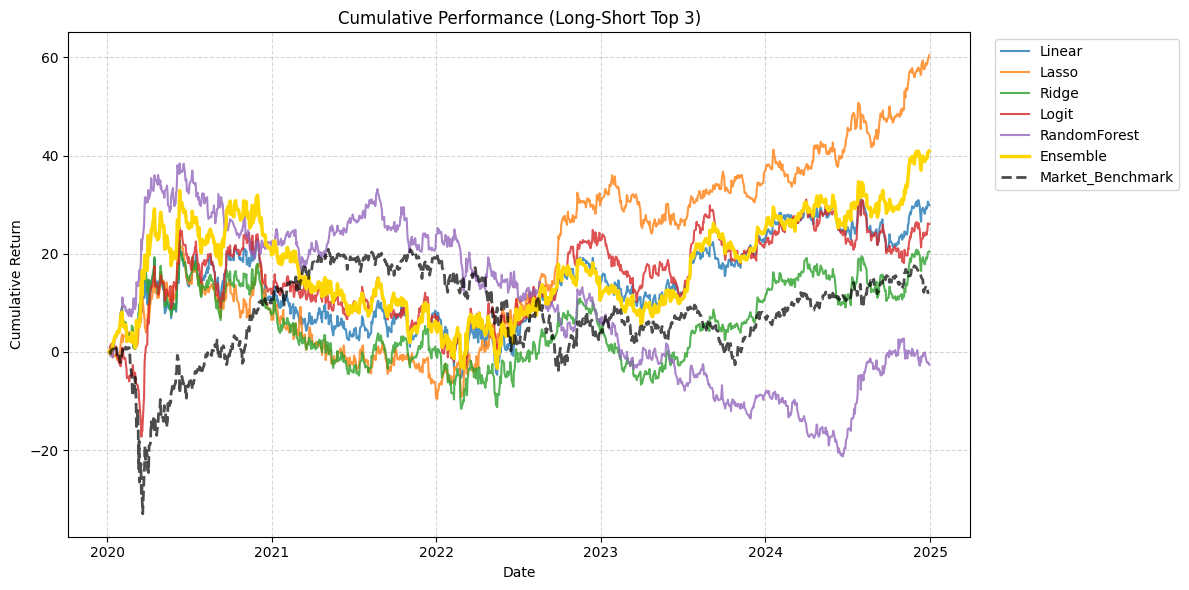

Info: Data appears to be in percent (e.g. 1.0 = 1%). Dividing by 100 for correct metrics.
Calculating performance metrics...

--- Strategy Performance Metrics ---


,Return p.a. (CAGR),Return p.a. (Mean),Vol p.a.,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Recovery Days,Win Rate
Lasso,11.34%,12.13%,16.66%,0.73,1.09,-30.35%,0.37,595,50.04%
Ensemble,6.95%,8.21%,17.31%,0.47,0.72,-32.57%,0.21,1117,48.61%
Linear,4.62%,6.00%,17.24%,0.35,0.51,-25.83%,0.18,787,49.72%
Logit,3.83%,5.23%,17.15%,0.30,0.46,-26.63%,0.14,956,49.80%
Ridge,2.65%,4.11%,17.29%,0.24,0.35,-31.08%,0.09,1146,48.76%
Market_Benchmark,1.10%,2.42%,16.29%,0.15,0.20,-30.27%,0.04,918,51.47%
RandomForest,-1.67%,-0.52%,15.31%,-0.03,-0.05,-47.12%,-0.04,1146,49.40%


In [72]:
# BT of strategies in test set
strategy_dates = data_input_testset.index.get_level_values('Date').unique()

# 3. Funktion ausführen
# df_all_ready_z muss als 'df_truth' übergeben werden (enthält das echte ret_t+1)
# df_market['ret'] ist deine Benchmark (musst du ggf. anpassen auf deinen Spaltennamen)

results_dict_testset, df_performance_testset = run_clean_backtest(
    model_results_dict=strategies_testset,
    df_truth=df_all_ready_z,       # Hier holen wir uns die echten Returns
    benchmark_series=df_market.loc[strategy_dates, 'ret_t+1'], # Deine Benchmark Series
    plot=True
)
# --- EXECUTION ---

# 1. Check Data Scaling (Percentage vs Decimal)
df_perf_clean = df_performance_testset.copy()
# If average return is > 0.1 (10% daily), data is likely in integers (1.0) instead of decimals (0.01)
if df_perf_clean.abs().mean().mean() > 0.1: 
    print("Info: Data appears to be in percent (e.g. 1.0 = 1%). Dividing by 100 for correct metrics.")
    df_perf_clean = df_perf_clean / 100

# 2. Calculate Metrics
df_metrics, drawdown_series = calculate_performance_metrics(df_perf_clean)

# 3. Create a Formatted Display DataFrame (No Jinja2)
# We convert numbers to strings just for displaying purposes
df_display = df_metrics.copy()

# Format Percentages
pct_cols = ['Return p.a. (CAGR)', 'Return p.a. (Mean)', 'Vol p.a.', 'Max Drawdown', 'Win Rate']
for col in pct_cols:
    if col in df_display.columns:
        df_display[col] = df_display[col].apply(lambda x: f"{x:.2%}")

# Format Ratios (2 decimals)
ratio_cols = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio']
for col in ratio_cols:
    if col in df_display.columns:
        df_display[col] = df_display[col].apply(lambda x: f"{x:.2f}")

# Format Integers
if 'Recovery Days' in df_display.columns:
    df_display['Recovery Days'] = df_display['Recovery Days'].apply(lambda x: f"{x:.0f}")

print("\n--- Strategy Performance Metrics ---")
display(df_display)

Benchmark test  

Starte 1500 Simulationen (Monkey Test)...


Simuliere Tage: 100%|██████████| 1255/1255 [00:34<00:00, 36.74it/s]


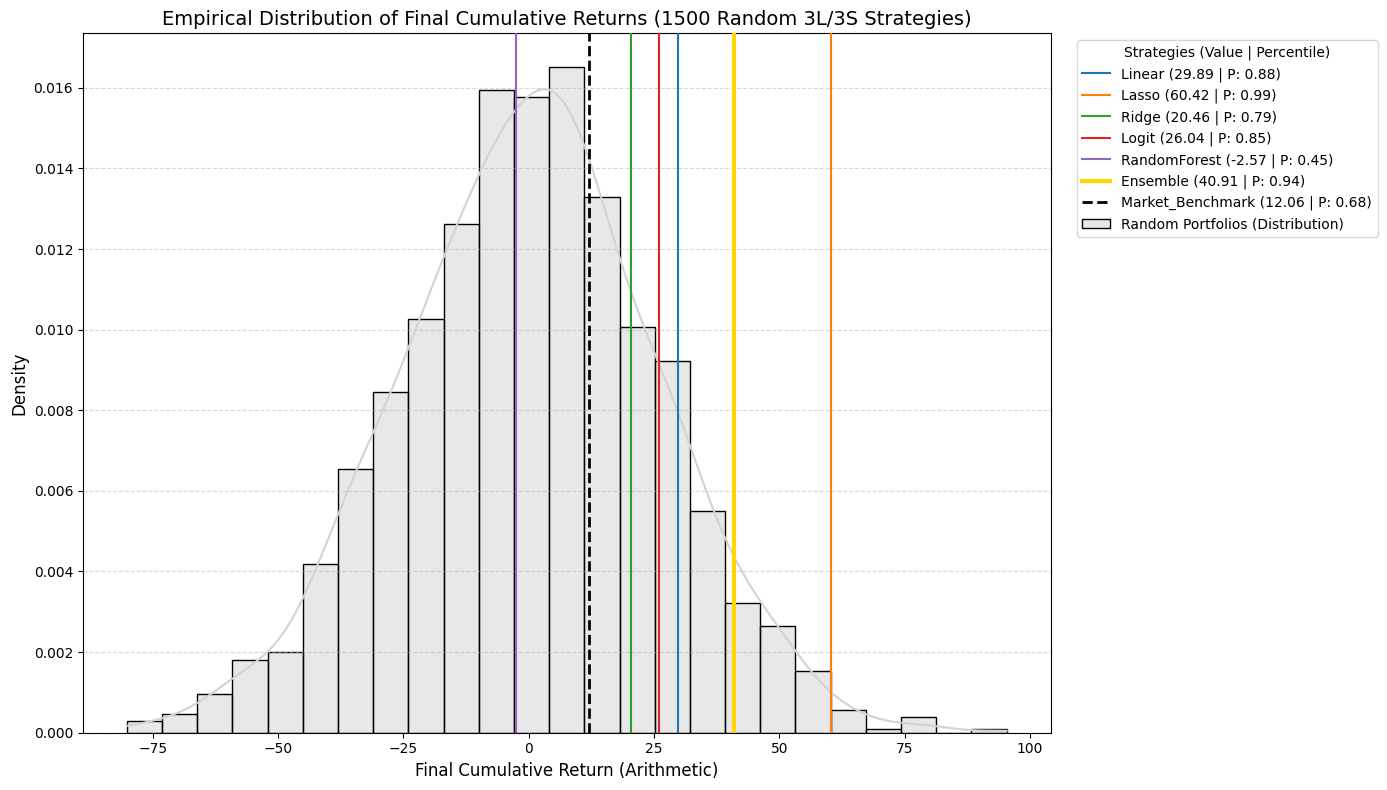


📈 PERCENTILE RANKING (0.00 = Worst, 1.00 = Best)
Lasso               : 99.20% (Value: 60.42)
Ensemble            : 94.33% (Value: 40.91)
Linear              : 88.20% (Value: 29.89)
Logit               : 84.60% (Value: 26.04)
Ridge               : 78.93% (Value: 20.46)
Market_Benchmark    : 68.33% (Value: 12.06)
RandomForest        : 45.07% (Value: -2.57)


(array([  6.93197699,   6.3201557 ,  11.43503441, ..., -28.01199447,
        -14.34407666,   2.25988164]),
 Lasso               0.992000
 Ensemble            0.943333
 Linear              0.882000
 Logit               0.846000
 Ridge               0.789333
 Market_Benchmark    0.683333
 RandomForest        0.450667
 dtype: float64)

In [73]:
plot_empirical_distribution(df_performance_testset, df_all_ready_z_test, n_simulations=1500)

Final Remark on Backtest Result:
- Selected ensemble model performs 2nd best in 5-year test period
- All metrics are way worse than in the validation set (even though validation set was not used for fine-tuning)
- 1/n BM however, beaten by large margin // 1/n long only PF needs about 2% avg financing costs in test period
- Interestingly models perform well in market drawdowns and bad in the bounce back after the Corona Dip
- Alpha decay is on real financial data well documented


# Ideas

- Data Exploration:
    - Filling NaN gaps in Index Time series with regression against all other industries or industry clusters based on corr matrix.
    - Maybe even backward extension for synthetic data generation would be possible.
    - Are Macro Data Point in Time? - i.e. Macrosynergy biggest PIT Data Provider (low cost until usage)

- Data Preparation
    - index outperformance variables are currently calculated with index - market average
        - one could use CAPM like regressions to estimate abnormal performances after "market" or "sector" adjustments
        - these residuals could be used instead of the outperformance variables above
    - why using outperformance instead of raw returns? --> bc l/s strategy requires relative perf differences not market performance    
    - standardization of input data (z-scoring) is based on 6m rolling panel data --> this could be a crucial choice --> sensitivity study


- Model Building
    - Feature Selection
        - Select feature set for each industry --> relevant for non Panel regressions i.e. lin, lasso, ridge, logit
        - Use also raw return for feature importance and mix with feature selected on out_perf target analysis
        - Run Random Forest and Neural Net on full available data - or at least more data than regressions...
        - think about transfer learning, i.e. market model that is finetuned with industry data
    - Model evaluation
        - Tune hyperparameters in validation set allowed!
        - Ensemble model composition also based on bt performance in validation set
        - train/valid/test set is not really used here
        - No elaborate random forest or DeepLearning Models (LSTM, Multi-head Attention ...)
        - also test models on expanding not rolling training window
    - Model Selection
        - Selection was done on fast track - correlations of different predictions or strategies could be very valuable to diversify strategy risk

- Backtesting
    - Benchmark appraoch based on bootstrapping from all possible l/s strategies
    - then calculate quantile of your strategy in the empirical distribution of random strategies
    - introduce limits for executing trades i.e. only if  |ensemble pred| > trading_limit (not in line with 3/3 full invest strategy) 